(mmm_case_study2)=
# MMM Case Study, Second Iteration: Funnel Effects, ROAS Calibration, and Budget Planning

This notebook is the second iteration of the {ref}`mmm_case_study` notebook. The first iteration gave us a working model and a first set of decisions: the baseline drives about 60% of sales, Online Display and Insert show the highest return on ad spend (ROAS) but with wide uncertainty bands, and Direct Mail takes the largest budget while showing the lowest ROAS. A counterfactual re-allocation suggested a meaningful uplift in media-driven sales.

When we presented these results, stakeholders came back with two questions:

1. **Why is search engine marketing (SEM) not in the model?** SEM is the second largest line in the media budget.
2. **How stable are these ROAS numbers over time, and can we tighten the wide ones?**

This iteration answers both. Concretely, we improve on the first iteration in four ways:

1. **Funnel structure**: we bring SEM into the model, but not as a flat channel. SEM harvests demand that upper funnel media (TV, Radio, Newspaper) create, so we model it through an explicit funnel with a custom effect, following {ref}`mmm_funnel_mueffect` and {ref}`mmm_funnel_mueffect_advanced`.
2. **Calibration**: we use ROAS ranges from two experiments to calibrate the model, following {ref}`mmm_roas_calibration`.
3. **Validation**: we replace the single train and test split with time-slice cross-validation, following {ref}`mmm_time_slice_cross_validation`, and fit the final model on all the data.
4. **Budget planning**: we optimize the budget for the next quarter with the new funnel-aware objective, co-optimizing the SEM budget with the media channels, and we quantify the expected uplift of the optimal mix on the training data.

:::{note}
This notebook focuses on the business application. For the model building blocks see {ref}`mmm_example`, and for the funnel machinery in depth see {ref}`mmm_funnel_mueffect` and {ref}`mmm_funnel_mueffect_advanced`.
:::

## Why SEM Needs Funnel Treatment

The first iteration deliberately excluded the SEM spend column. That was the right call for a flat model: paid search spend reacts to search demand, and search demand reacts to upper funnel advertising. If we add SEM as an eighth flat channel, the model conditions on a variable that sits in the middle of the causal path. It blocks the indirect path and credits SEM with sales that TV, Radio, and Newspaper created. This is the first failure mode analyzed in {ref}`mmm_funnel_mueffect`.

**Business Context:** SEM is 26.9% of the modeled media spend, the second largest line after Direct Mail. The funnel question decides whether cutting upper funnel budget is safe. A mediator-blind model undervalues TV, Radio, and Newspaper exactly where they earn part of their return, and the resulting budget shift can destroy the demand SEM lives on.

The dataset carries two SEM columns. `sem_spend` is money the search team spends, an exogenous budget lever. `sem_impressions` is how often the ads showed, which scales with search volume, so it is a noisy measurement of harvested demand. We use both: the spend as a decision variable, the impressions as evidence.

The model adds one latent demand pool and one mediator on top of the first iteration structure:

$$D_t = \text{baseline} + \sum_{c \in \text{upper}} \text{sat}^{uf}\left(\text{adstock}^{uf}(U_{t,c})\right)$$

$$M^{*}_t = D_t + \lambda \, \frac{\text{sem\_spend}_t}{s_{\text{sem}}}$$

$$\text{sem\_impressions}_t \sim \text{TruncatedNormal}\left(s_{\text{imp}} \, M^{*}_t, \sigma^{S}, \text{lower}=0\right)$$

and the sales mean gains the term $\text{sat}^{lf}\left(\text{adstock}^{lf}(M^{*}_t)\right)$, where $s_{\text{sem}}$ and $s_{\text{imp}}$ are fixed scaling constants (the maxima of the two series). The measurement coefficient on $M^{*}$ is fixed at one. This anchors the scale of the latent mediator: with a free coefficient, the model could rescale demand and the coefficient in opposite directions without changing the likelihood, and the sampler would wander along that ridge.

All seven channels from the first iteration keep their direct paths. Only TV, Radio, and Newspaper feed the demand pool; Direct Mail, Insert, Online Display, and Social Media stay direct-only. This matters later: the ROAS calibration constrains the direct path, so we calibrate direct-only channels where the experiment measures exactly what the model constrains.

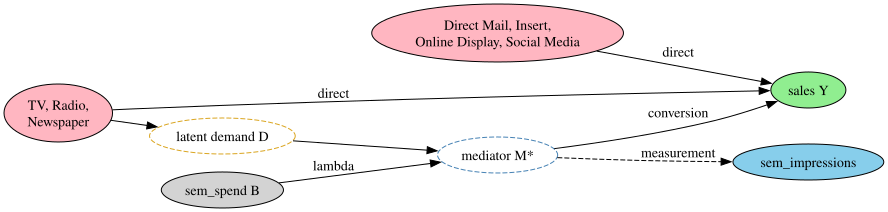

In [1]:
import graphviz as gr

dag = gr.Digraph()
dag.attr(rankdir="LR")
dag.node("upper", "TV, Radio,\nNewspaper", style="filled", fillcolor="lightpink")
dag.node(
    "direct",
    "Direct Mail, Insert,\nOnline Display, Social Media",
    style="filled",
    fillcolor="lightpink",
)
dag.node("demand", "latent demand D", style="dashed", color="goldenrod")
dag.node("sem_spend", "sem_spend B", style="filled", fillcolor="lightgray")
dag.node("mediator", "mediator M*", style="dashed", color="steelblue")
dag.node("impressions", "sem_impressions", style="filled", fillcolor="skyblue")
dag.node("sales", "sales Y", style="filled", fillcolor="lightgreen")
dag.edge("upper", "sales", label="direct")
dag.edge("direct", "sales", label="direct")
dag.edge("upper", "demand")
dag.edge("demand", "mediator")
dag.edge("sem_spend", "mediator", label="lambda")
dag.edge("mediator", "impressions", label="measurement", style="dashed")
dag.edge("mediator", "sales", label="conversion")
dag

:::{tip}
Filled nodes are observed, dashed nodes are latent. The dashed edge into `sem_impressions` is a measurement: impressions do not cause anything in this graph, they tell us where the mediator is.
:::

## Prepare Notebook

In [2]:
import warnings

import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import pytensor
import seaborn as sns
import xarray as xr
from pydantic import InstanceOf
from pymc_extras.prior import Prior
from pytensor.compile.mode import Mode
from pytensor.graph.traversal import ancestors

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.additive_effect import DataVarMuEffect, IncrementalitySpec
from pymc_marketing.mmm.constraints import Constraint, build_default_sum_constraint
from pymc_marketing.mmm.data_conversion import to_mmm_dataset
from pymc_marketing.mmm.media_transformation import MediaTransformation
from pymc_marketing.mmm.mmm import MMM
from pymc_marketing.mmm.time_slice_cross_validation import TimeSliceCrossValidator
from pymc_marketing.paths import data_dir

warnings.filterwarnings("ignore", category=FutureWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [3]:
seed: int = sum(map(ord, "mmm_case_study2"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

## Load Data

We use the same public dataset as the first iteration, with the same cleaning and channel names, plus two changes: we keep the two SEM columns, renamed to `sem_spend` and `sem_impressions`, and we rename the date column to `date` (the name the cross-validation plotting utilities expect). As before, `mdsp_viddig` and `mdsp_auddig` stay excluded.

There is no train and test split this time. Time-slice cross-validation replaces it, and the final model uses all 209 weeks.

In [4]:
data_path = data_dir / "case_study_data.csv"
raw_df = pd.read_csv(data_path)

date_column = "date"
target_column = "sales"

channel_mapping = {
    "mdsp_dm": "Direct Mail",
    "mdsp_inst": "Insert",
    "mdsp_nsp": "Newspaper",
    "mdsp_audtr": "Radio",
    "mdsp_vidtr": "TV",
    "mdsp_so": "Social Media",
    "mdsp_on": "Online Display",
}
channel_columns = sorted(channel_mapping.values())
funnel_mapping = {"mdsp_sem": "sem_spend", "mdip_sem": "sem_impressions"}
funnel_vars = list(funnel_mapping.values())
upper_channels = ["Newspaper", "Radio", "TV"]
control_columns = [col for col in raw_df.columns if "hldy_" in col]

data_df = raw_df[
    ["wk_strt_dt", target_column, *channel_mapping, *funnel_mapping, *control_columns]
].rename(columns=channel_mapping | funnel_mapping | {"wk_strt_dt": date_column})
data_df[date_column] = pd.to_datetime(data_df[date_column])

X = data_df.drop(columns=target_column)
y = data_df[target_column]

print(
    f"{X[date_column].nunique()} weeks, {X[date_column].min():%Y-%m-%d} to {X[date_column].max():%Y-%m-%d}"
)
data_df.head()

209 weeks, 2014-08-03 to 2018-07-29


,date,sales,Direct Mail,Insert,Newspaper,Radio,TV,Social Media,Online Display,sem_spend,...,hldy_Memorial Day,hldy_Mother's Day,hldy_NYE,hldy_New Year's Day,hldy_Pre Thanksgiving,hldy_Presidents Day,hldy_Prime Day,hldy_Thanksgiving,hldy_Valentine's Day,hldy_Veterans Day
0,2014-08-03,72051457.64,678410.26,129759.66,507635.16,254134.14,216725.59,0.0,61364.75,355954.51,...,0,0,0,0,0,0,0,0,0,0
1,2014-08-10,78794770.54,661097.71,70355.33,625719.37,106602.98,108919.26,0.0,132643.90,336306.72,...,0,0,0,0,0,0,0,0,0,0
2,2014-08-17,70071185.56,1874338.43,107720.37,277532.61,59011.42,74032.19,0.0,76741.27,344787.96,...,0,0,0,0,0,0,0,0,0,0
3,2014-08-24,68642464.59,306583.37,141708.61,186028.61,178010.46,110995.66,0.0,193043.55,365495.11,...,0,0,0,0,0,0,0,0,0,0
4,2014-08-31,86190784.65,2366274.16,160691.30,706694.09,144097.56,225140.84,0.0,249612.89,401789.35,...,0,0,0,0,0,0,0,0,0,0


## Exploratory Data Analysis

The first iteration covers the full exploratory analysis of channels, controls, and sales. Here we look only at what is new: the SEM pair and what it implies for the funnel.

**Business Context:** whatever the model says about SEM moves more money than any conclusion about a single media channel except Direct Mail.

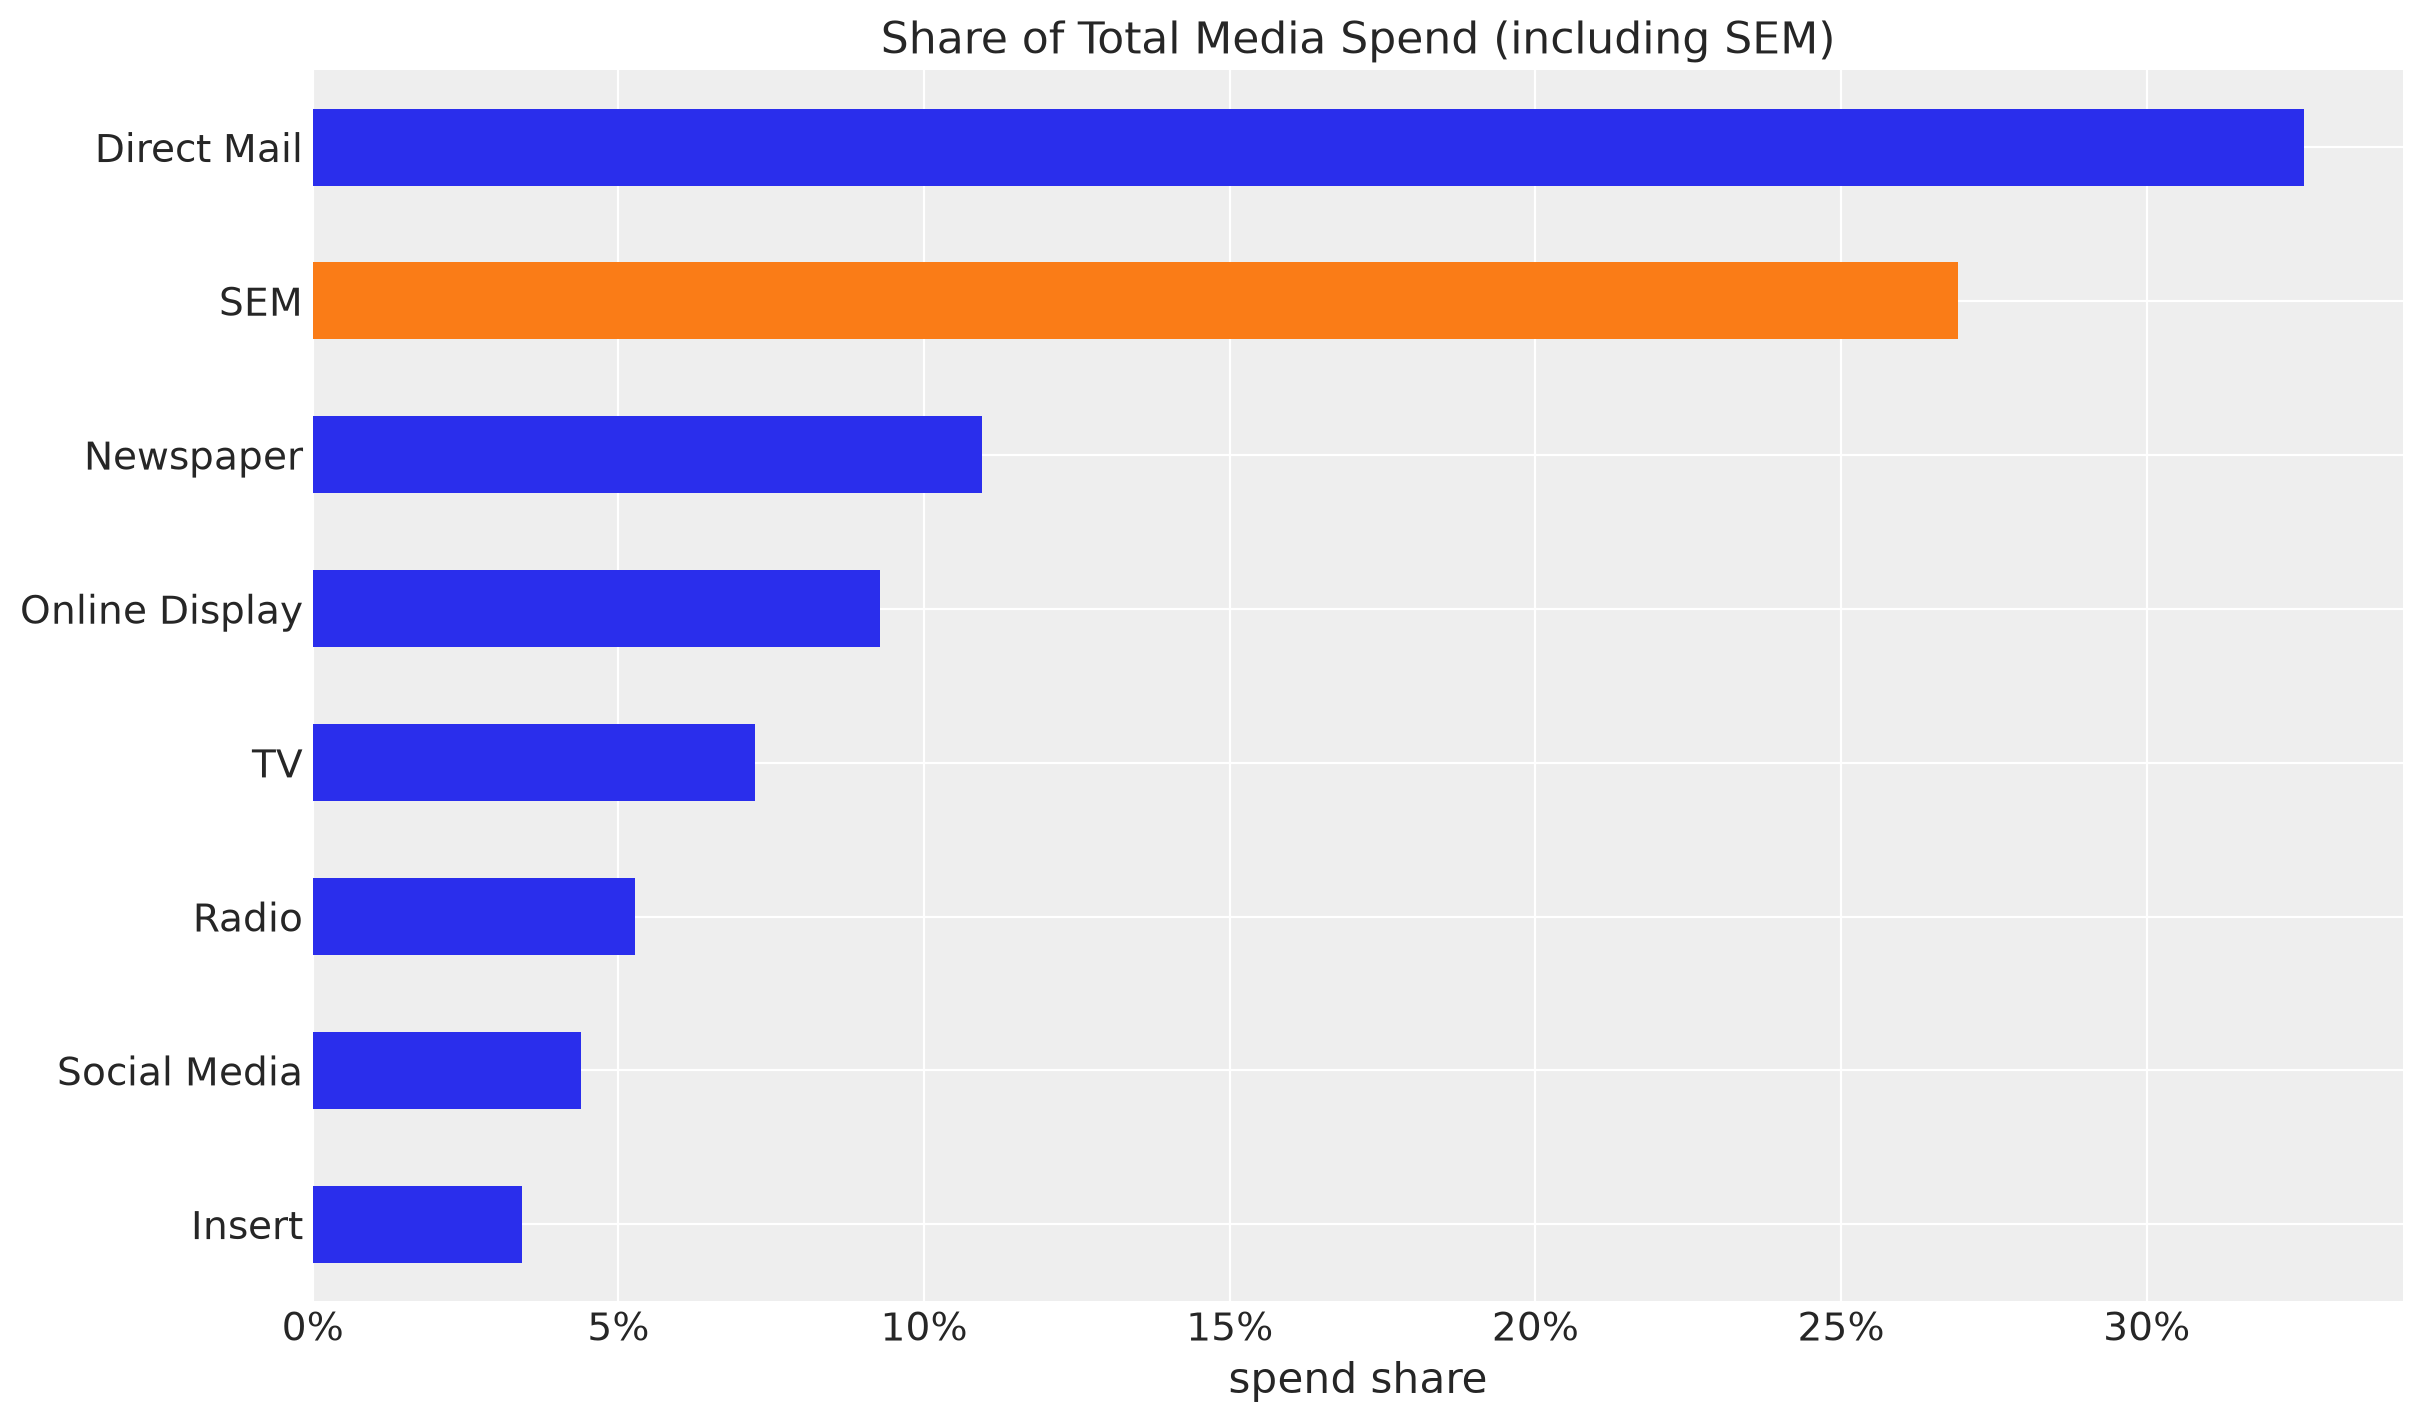

In [5]:
spend_share = (
    pd.concat(
        [X[channel_columns], X[["sem_spend"]].rename(columns={"sem_spend": "SEM"})],
        axis=1,
    )
    .sum()
    .sort_values()
)
spend_share = spend_share / spend_share.sum()

fig, ax = plt.subplots()
colors = ["C1" if name == "SEM" else "C0" for name in spend_share.index]
spend_share.plot.barh(color=colors, ax=ax)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set(title="Share of Total Media Spend (including SEM)", xlabel="spend share");

SEM (orange) is 26.9% of the modeled media spend, second only to Direct Mail. The first iteration left this line item outside the model.

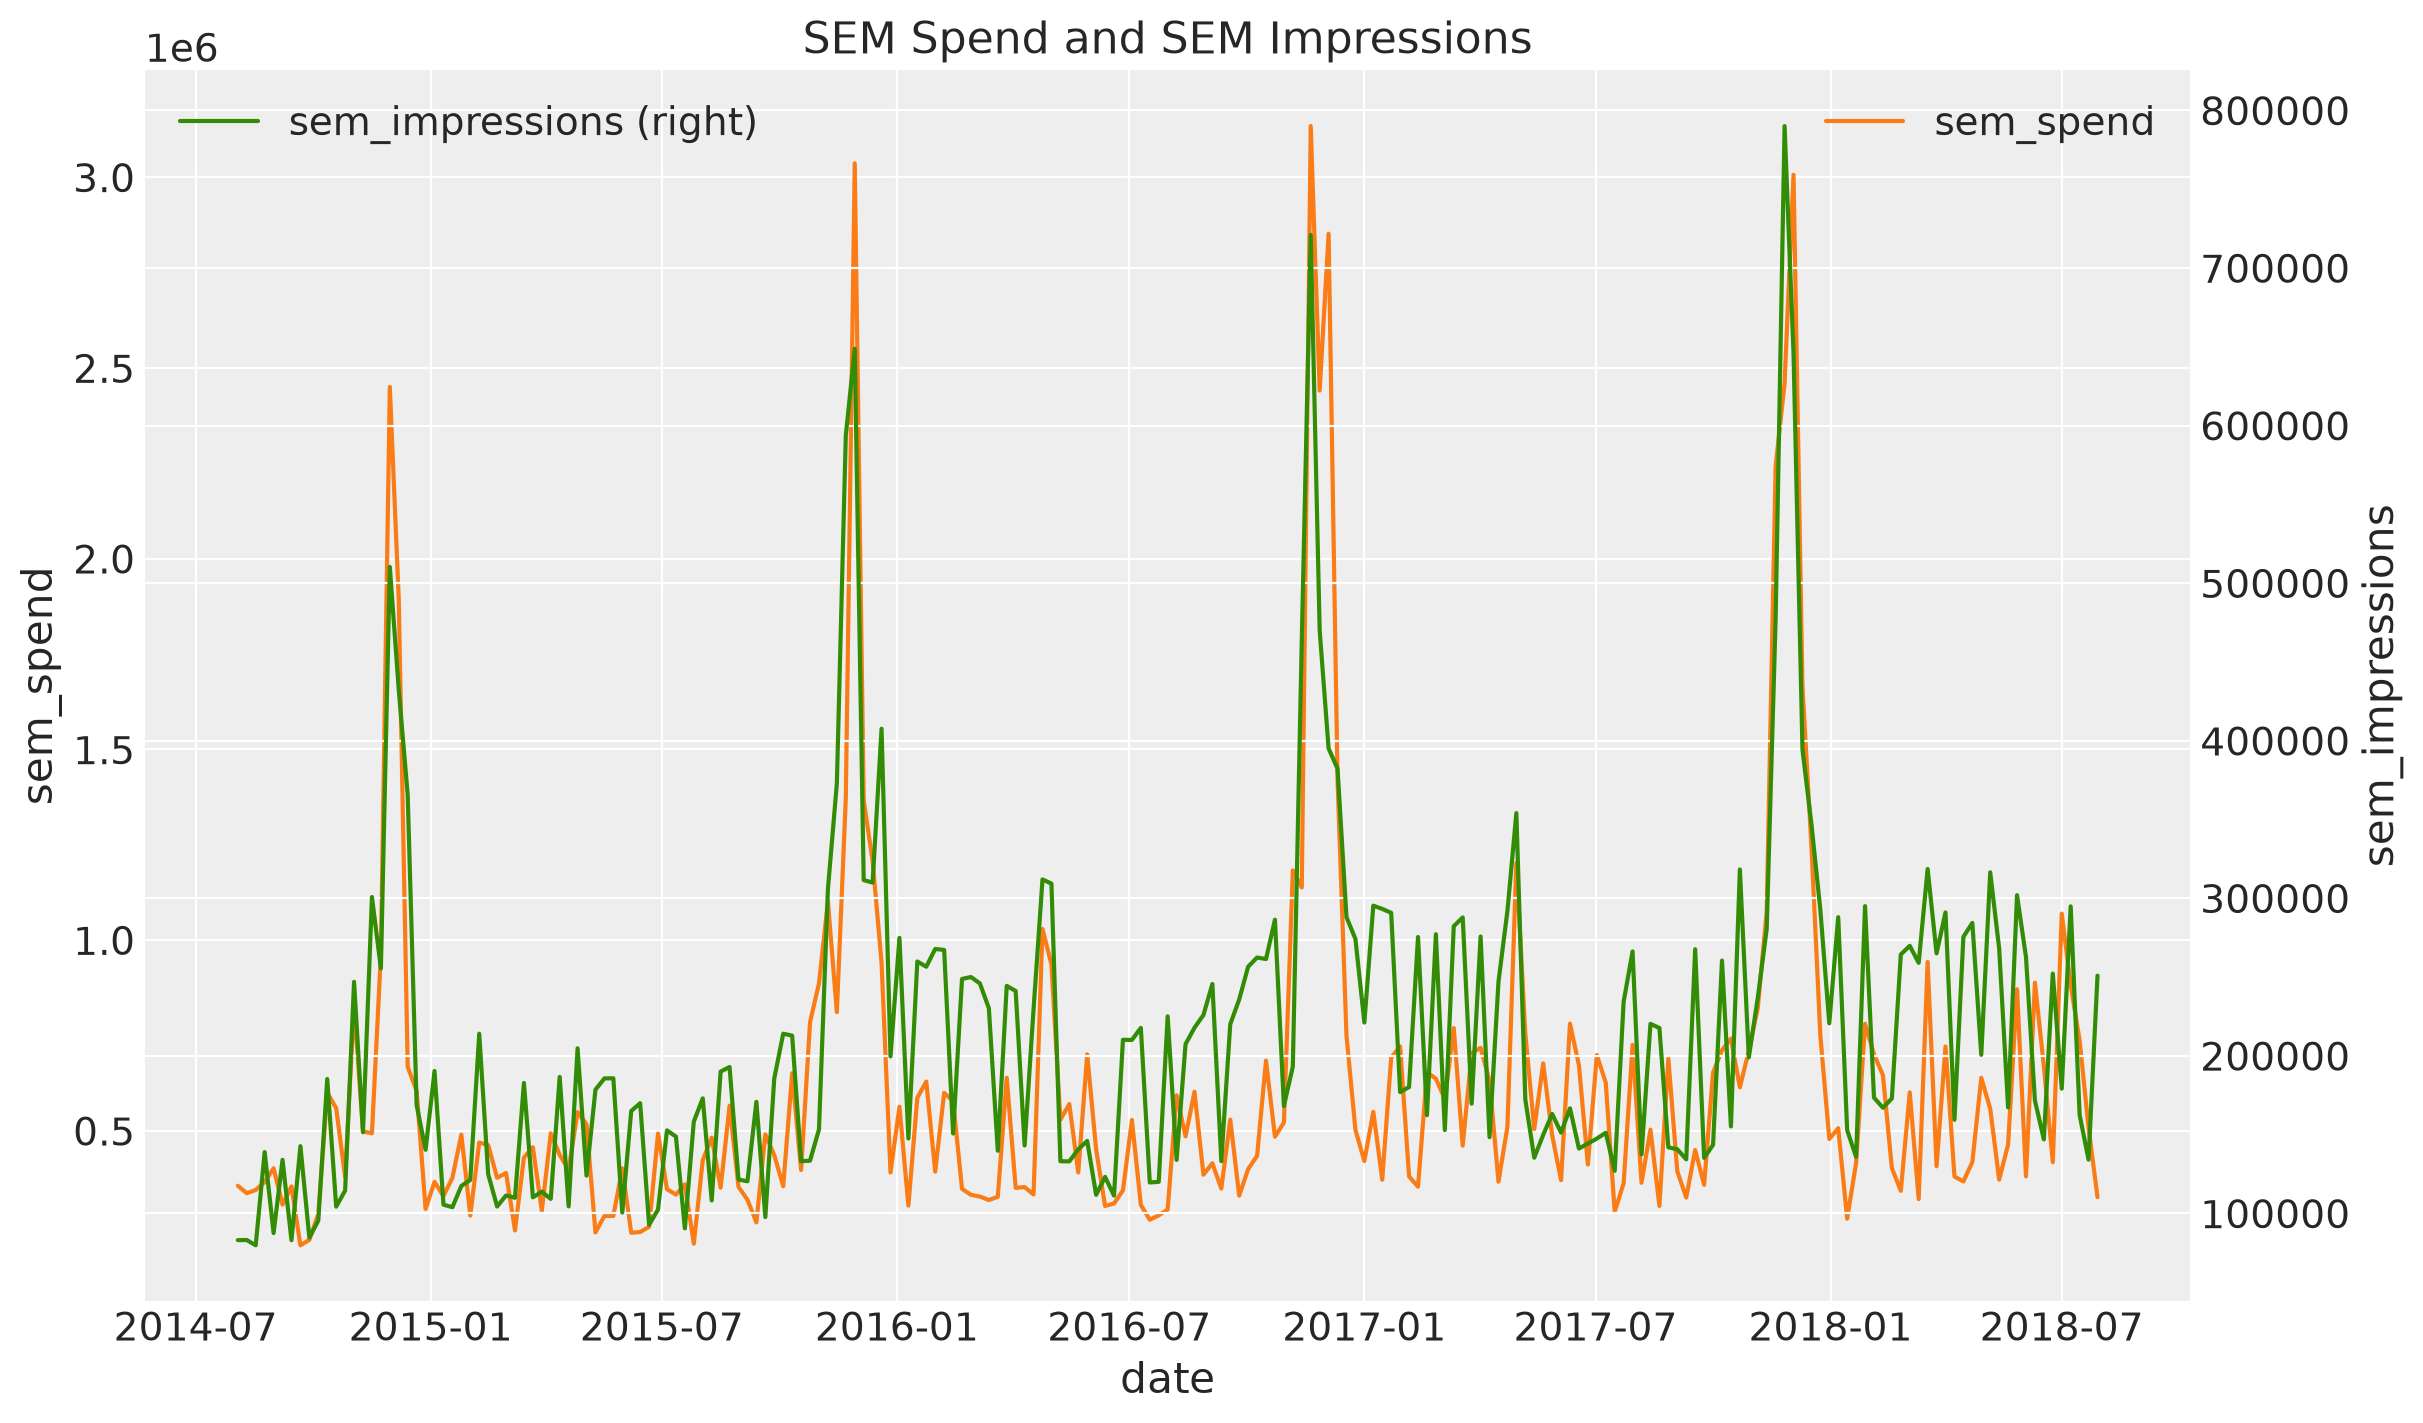

In [6]:
fig, ax = plt.subplots()
sns.lineplot(
    data=data_df, x=date_column, y="sem_spend", color="C1", label="sem_spend", ax=ax
)
sns.lineplot(
    data=data_df,
    x=date_column,
    y="sem_impressions",
    color="C2",
    label="sem_impressions (right)",
    ax=ax.twinx(),
)
ax.set(title="SEM Spend and SEM Impressions", ylabel="sem_spend");

In [7]:
corr_sales = data_df[["sem_spend", "sem_impressions", target_column]].corr()[
    target_column
]
corr_pair = data_df["sem_spend"].corr(data_df["sem_impressions"])
print(f"corr(sem_spend, sales) = {corr_sales['sem_spend']:.2f}")
print(f"corr(sem_impressions, sales) = {corr_sales['sem_impressions']:.2f}")
print(f"corr(sem_spend, sem_impressions) = {corr_pair:.2f}")

corr(sem_spend, sales) = 0.59
corr(sem_impressions, sales) = 0.59
corr(sem_spend, sem_impressions) = 0.79


SEM spend and impressions move together (correlation 0.79) and both track sales (correlations 0.59). That pattern is compatible with two very different stories: SEM drives sales, or SEM follows demand that something else created and sales follow the same demand.

:::{warning}
**Critical Assessment:** correlation cannot separate "SEM causes sales" from "SEM harvests demand". The practical question is causal: if we doubled SEM spend next quarter, would sales move? Only structure plus experiments can answer it, which is why this iteration adds both.
:::

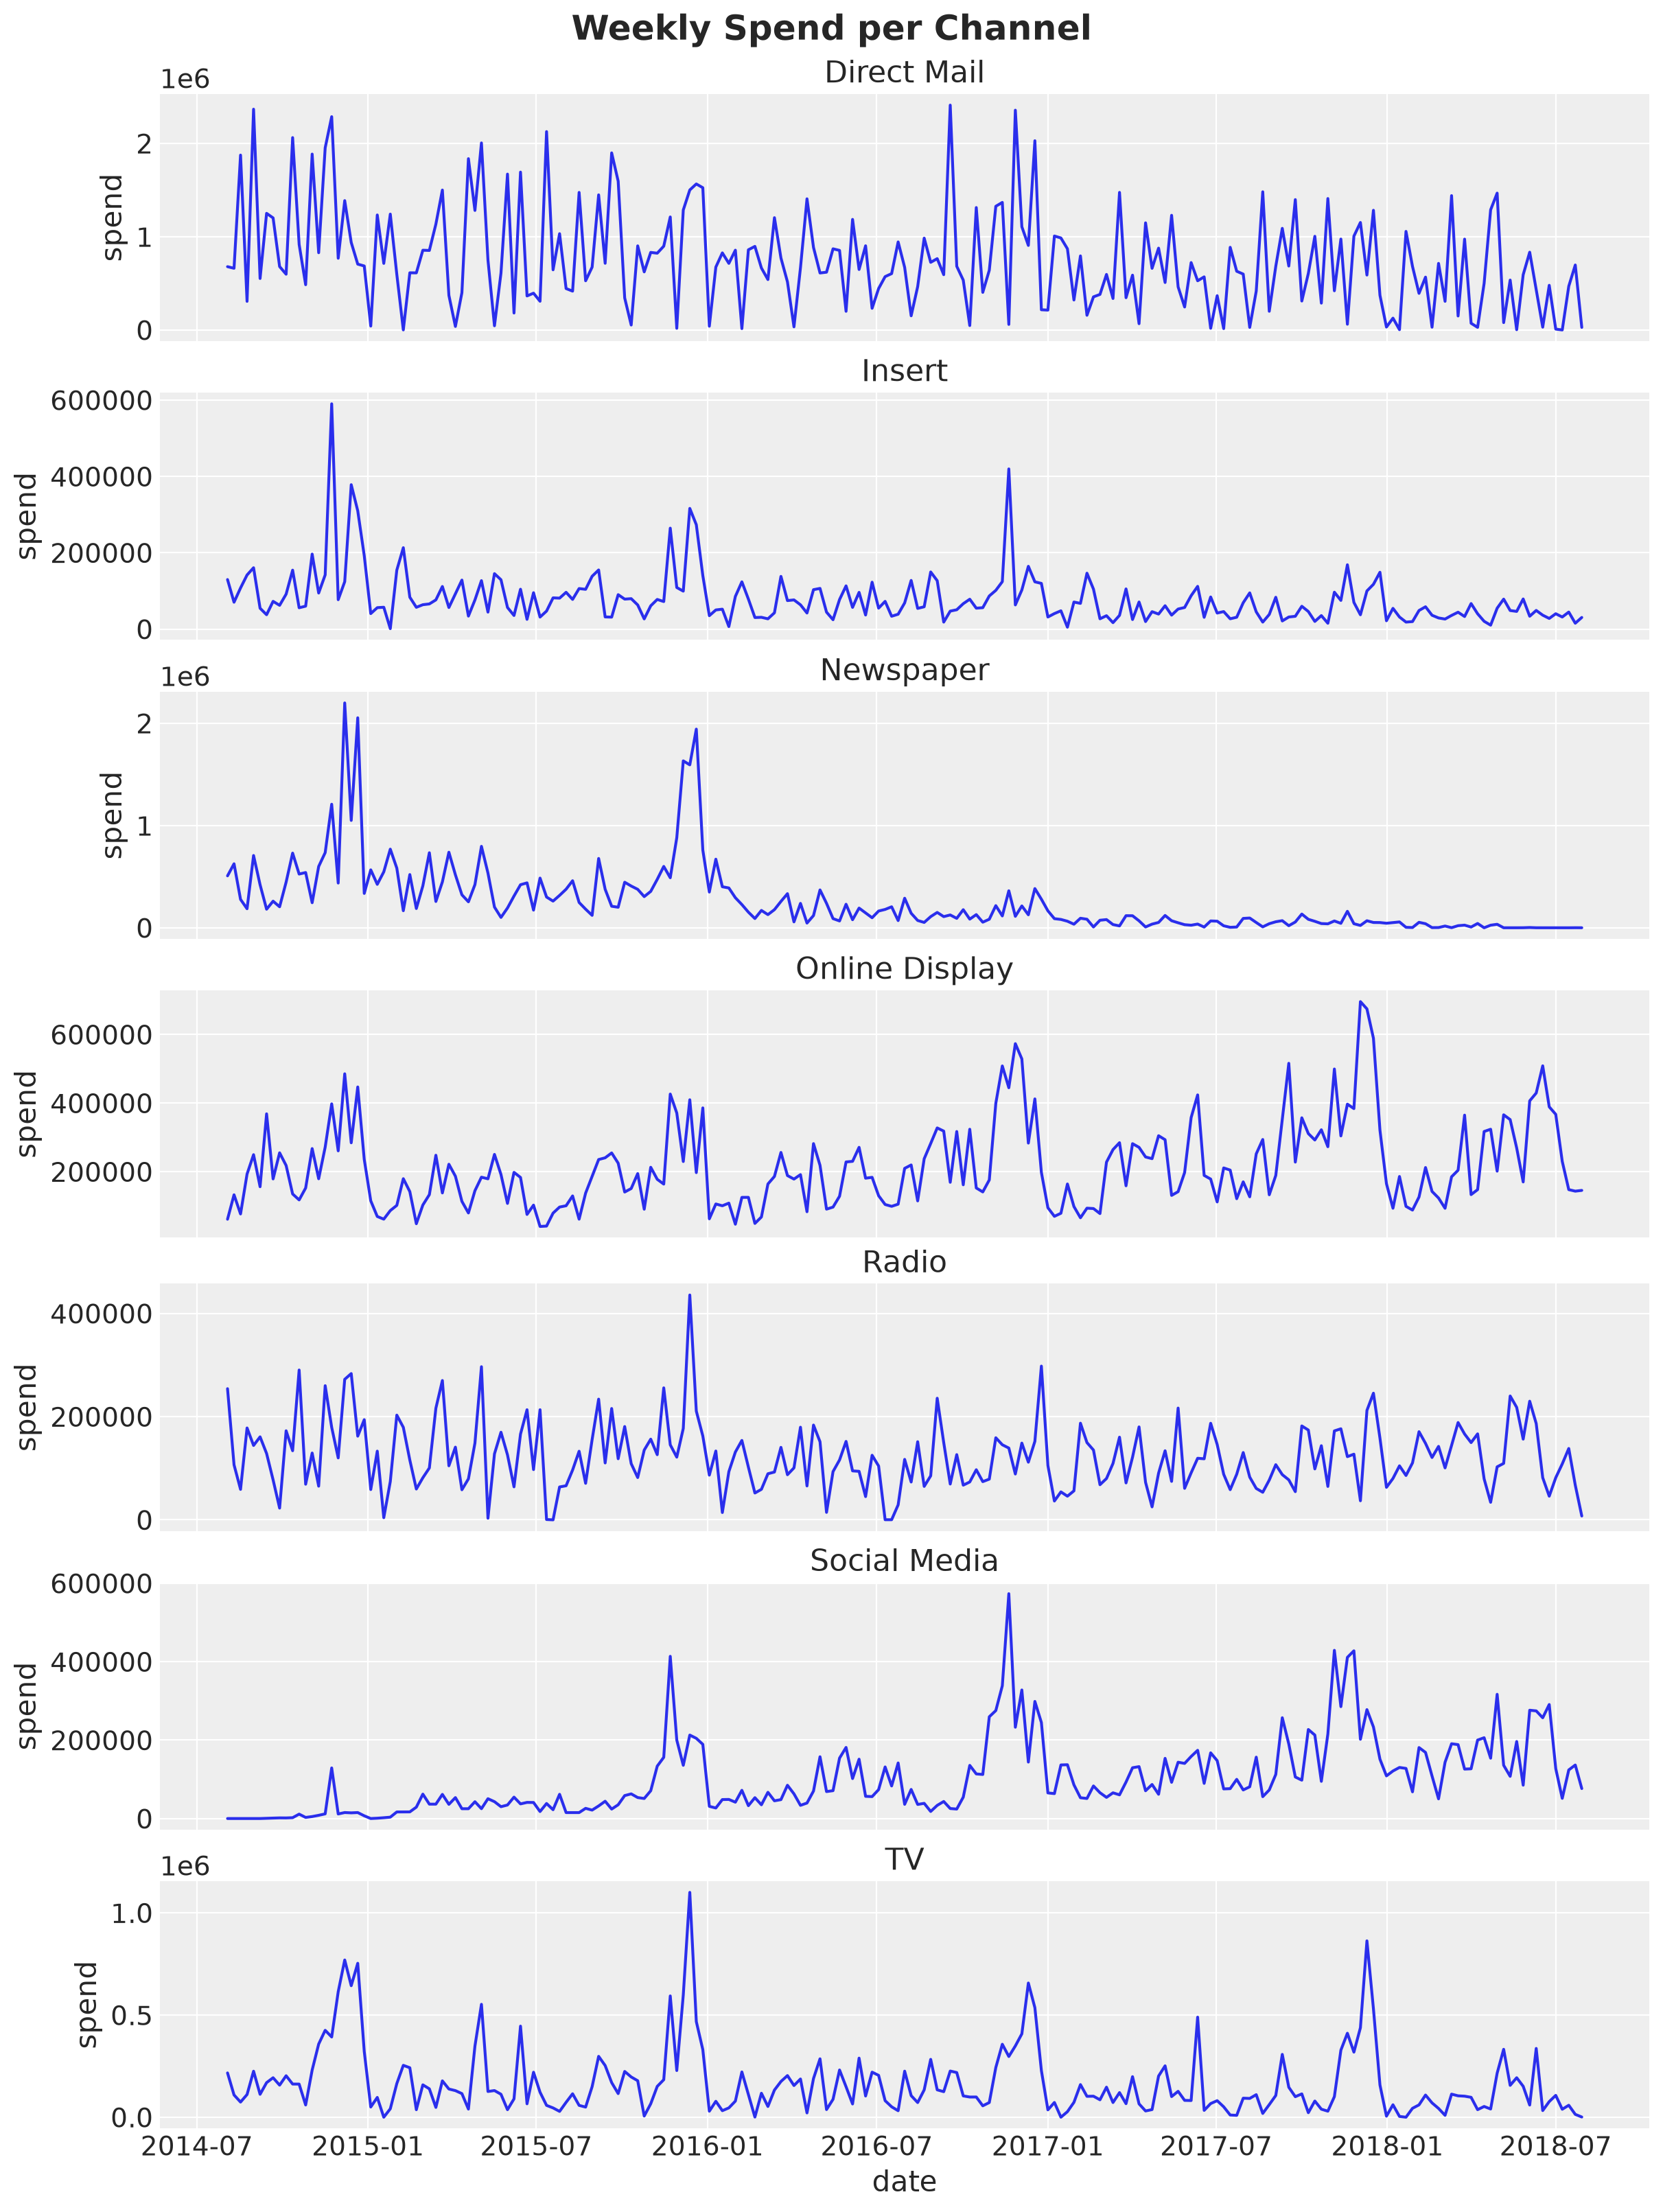

In [8]:
fig, axes = plt.subplots(
    nrows=len(channel_columns),
    ncols=1,
    figsize=(12, 16),
    sharex=True,
    layout="constrained",
)
for ax, channel in zip(axes, channel_columns, strict=True):
    sns.lineplot(data=data_df, x=date_column, y=channel, color="C0", ax=ax)
    ax.set(title=channel, ylabel="spend")
fig.suptitle("Weekly Spend per Channel", fontsize=18, fontweight="bold");

One finding worth naming before any modeling: Newspaper spend collapses to almost nothing in the recent period. Its weekly average over the full four years is around 255K, over the last year it is around 33K, and over the last quarter it is under 400. This is why the budget planning section later anchors on the last 52 weeks: last-quarter averages would freeze Newspaper at a level that no longer represents a real decision.

## Model Specification

The direct part of the model is the first iteration model unchanged: geometric adstock, logistic saturation, holiday controls, yearly seasonality, and spend-share priors on the saturation betas. See {ref}`mmm_case_study` for the reasoning behind these priors. The one difference is that we compute the spend shares on all 209 weeks, since there is no held-out test set.

In [9]:
spend_shares = (
    X[channel_columns].sum().reindex(channel_columns) / X[channel_columns].sum().sum()
).to_numpy()

model_config = {
    "intercept": Prior("Normal", mu=0.2, sigma=0.05),
    "saturation_beta": Prior("HalfNormal", sigma=spend_shares, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=1, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
    "likelihood": Prior("TruncatedNormal", lower=0, sigma=Prior("HalfNormal", sigma=1)),
}

### The Funnel Effect

The funnel enters the model as a custom {class}`~pymc_marketing.mmm.additive_effect.MuEffect`: a component that adds a term to the sales mean and can declare its own likelihoods. We subclass {class}`~pymc_marketing.mmm.additive_effect.DataVarMuEffect`, which handles the data registration for `sem_spend` and `sem_impressions`.

Three design points, each of which prevents a silent failure:

1. The effect reads the model's own channel data (`mmm.channel_data_scaled`) and selects the upper channels by name. This is what makes budget optimization work later: an intervention on the channel budgets flows through the demand pool automatically. An effect that reads its own copy of the spend would be invisible to the optimizer.
2. The upper channel subset gets its own named dimension (`channel_upper`), so its adstock and saturation priors cannot collide with the seven-channel `channel` dimension.
3. `incrementality_spec` declares the extra carryover the second adstock adds. This is how the ROAS machinery and the optimizer window arithmetic learn that the mediated path reaches further into the future than the direct one.

In [10]:
upper_dim = "channel_upper"


class FunnelEffect(DataVarMuEffect):
    """Upper funnel spend -> latent demand -> SEM-harvested mediator -> sales.

    The measurement coefficient on the mediator is fixed at one (times the
    impressions scale). This anchors the mediator scale and removes the
    likelihood-invariant ridge a free coefficient would create.
    """

    upper_channels: list[str]
    sem_scale: float
    impressions_scale: float
    upper_transform: InstanceOf[MediaTransformation]
    demand_transform: InstanceOf[MediaTransformation]

    model_config = {"arbitrary_types_allowed": True}

    def to_dict(self) -> dict:
        """Serialize the effect."""
        return {
            "data_vars": self.data_vars,
            "prefix": self.prefix,
            "upper_channels": self.upper_channels,
            "sem_scale": self.sem_scale,
            "impressions_scale": self.impressions_scale,
            "upper_transform": self.upper_transform.to_dict(),
            "demand_transform": self.demand_transform.to_dict(),
        }

    def incrementality_spec(self) -> IncrementalitySpec:
        """Opt in to incrementality, declaring the second adstock's reach."""
        return IncrementalitySpec(
            additional_carryover_lags=self.demand_transform.adstock.l_max
        )

    def create_data(self, mmm) -> None:
        """Register the funnel data variables and the upper channel coordinate."""
        mmm.model.add_coord(upper_dim, self.upper_channels)
        super().create_data(mmm)

    def create_effect(self, mmm):
        """Build the mediator equation and the term it adds to the sales mean."""
        model = mmm.model
        channel_index = [mmm.channel_columns.index(c) for c in self.upper_channels]
        upper = mmm.channel_data_scaled.isel(channel=channel_index).rename(
            {"channel": upper_dim}
        )
        upper_on_demand = self.upper_transform(upper, dim="date").sum(dim=upper_dim)
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0)
        demand = pmd.Deterministic(f"{self.prefix}_demand", baseline + upper_on_demand)
        lam = pmd.HalfNormal(f"{self.prefix}_lambda", sigma=0.5)
        mediator = pmd.Deterministic(
            f"{self.prefix}_mediator",
            demand + lam * model["sem_spend"] / self.sem_scale,
        )
        pmd.TruncatedNormal(
            f"{self.prefix}_sem_impressions_likelihood",
            mu=self.impressions_scale * mediator,
            sigma=pmd.HalfNormal(
                f"{self.prefix}_sigma_s", sigma=0.2 * self.impressions_scale
            ),
            lower=0.0,
            observed=model["sem_impressions"],
        )
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.demand_transform(mediator, dim="date"),
        )

In [11]:
l_max = 6  # direct path adstock, as in the first iteration
l_max_lf = 6  # mediator adstock: demand takes time to convert


def make_funnel_effect(sem_scale: float, impressions_scale: float) -> FunnelEffect:
    """Build the funnel effect with its two media transformations."""
    return FunnelEffect(
        data_vars=funnel_vars,
        prefix="funnel",
        upper_channels=upper_channels,
        sem_scale=sem_scale,
        impressions_scale=impressions_scale,
        upper_transform=MediaTransformation(
            adstock=GeometricAdstock(
                l_max=l_max,
                prefix="adstock_uf",
                priors={"alpha": Prior("Beta", alpha=2, beta=3, dims=upper_dim)},
            ),
            saturation=LogisticSaturation(
                prefix="sat_uf",
                priors={
                    "lam": Prior("Gamma", mu=2.0, sigma=1.0, dims=upper_dim),
                    "beta": Prior("HalfNormal", sigma=1.0, dims=upper_dim),
                },
            ),
            adstock_first=True,
            dims=(upper_dim,),
        ),
        demand_transform=MediaTransformation(
            adstock=GeometricAdstock(
                l_max=l_max_lf,
                prefix="adstock_lf",
                priors={"alpha": Prior("Beta", alpha=2, beta=3)},
            ),
            saturation=LogisticSaturation(
                prefix="sat_lf",
                priors={
                    "lam": Prior("Gamma", mu=1.5, sigma=0.5),
                    "beta": Prior("HalfNormal", sigma=1.0),
                },
            ),
            adstock_first=True,
            dims=(),
        ),
    )

### Data Plumbing

Two mechanics need care with a funnel model. They are boring, and getting them wrong fails silently, so we spell them out.

First, the model must be **built from an `xr.Dataset`**, because the funnel columns (`sem_spend`, `sem_impressions`) only survive the data conversion as extra variables of a Dataset. Fitting still uses the flat DataFrame. One consequence: the stored `fit_data` carries no funnel columns, so `save` and load round-trips do not reconstruct this model.

Second, every **prediction call converts DataFrames without the extra variables** by default, which would silently freeze the funnel data at its training values. We subclass the model once to add them back. With this override, all posterior predictive workflows in this notebook (cross-validation, counterfactuals, uplift) can work with plain DataFrames.

In [12]:
class FunnelMMM(MMM):
    """MMM that carries the funnel data variables through DataFrame conversion."""

    def _posterior_predictive_data_transformation(
        self, X, y=None, include_last_observations: bool = False
    ):
        if isinstance(X, pd.DataFrame):
            present = [var for var in funnel_vars if var in X.columns]
            X = to_mmm_dataset(
                X,
                y,
                date_column=self.date_column,
                dims=self.dims,
                channel_columns=self.channel_columns,
                control_columns=self.control_columns,
                target_column=self.target_column,
                extra_vars=present,
            )
            y = None
        return super()._posterior_predictive_data_transformation(
            X, y=y, include_last_observations=include_last_observations
        )

In [13]:
def make_funnel_dataset(X: pd.DataFrame, y: pd.Series | None = None) -> xr.Dataset:
    """Convert the flat frame to the Dataset the funnel model builds from."""
    return to_mmm_dataset(
        X,
        y,
        date_column=date_column,
        channel_columns=channel_columns,
        control_columns=[col for col in X.columns if "hldy_" in col],
        target_column=target_column,
        extra_vars=funnel_vars,
    )


def make_mmm(X: pd.DataFrame) -> FunnelMMM:
    """Build the funnel MMM with scales and prior widths computed from X."""
    spend_shares = (
        X[channel_columns].sum().reindex(channel_columns)
        / X[channel_columns].sum().sum()
    ).to_numpy()
    mmm = FunnelMMM(
        model_config=model_config
        | {"saturation_beta": Prior("HalfNormal", sigma=spend_shares, dims="channel")},
        target_column=target_column,
        date_column=date_column,
        adstock=GeometricAdstock(l_max=l_max),
        saturation=LogisticSaturation(),
        channel_columns=channel_columns,
        control_columns=[col for col in X.columns if "hldy_" in col],
        yearly_seasonality=5,
    )
    mmm.add_mu_effect(
        make_funnel_effect(
            sem_scale=float(X["sem_spend"].max()),
            impressions_scale=float(X["sem_impressions"].max()),
        )
    )
    return mmm

## ROAS Calibration from Experiments

The first iteration flagged its widest uncertainty exactly where budget decisions were largest, and recommended experiments as the next step. For this iteration, imagine the measurement team ran two experiments in the first half of 2017:

- A conversion lift study on **Online Display**, the channel with the highest estimated ROAS and the widest uncertainty band. The study reported a ROAS between 20 and 36.
- A regional holdout test on **Direct Mail**, the largest and most contested budget line. The test reported a ROAS between 2 and 8, confirming the low estimate from the model.

On a real engagement these numbers come from geo holdouts or conversion lift studies; see {ref}`mmm_lift_test` for how to design them. A quick plausibility check on the scale: total sales are about 22.6B against 355M of direct channel spend, so if media drive roughly a third of sales, the blended direct ROAS is in the low tens. Both ranges sit comfortably on that scale.

We treat each reported range as a 95% interval and convert it to the value and standard deviation the calibration API expects.

In [14]:
def roas_range_to_calibration(lower: float, upper: float) -> dict[str, float]:
    """Convert a reported 95% ROAS interval to a Normal(value, sigma) target."""
    return {"roas": (lower + upper) / 2, "sigma": (upper - lower) / (2 * 1.96)}


roas_experiments = {
    "Online Display": roas_range_to_calibration(20.0, 36.0),
    "Direct Mail": roas_range_to_calibration(2.0, 8.0),
}

roas_calibration_df = pd.DataFrame(
    [{"channel": channel, **target} for channel, target in roas_experiments.items()]
)
roas_calibration_df

,channel,roas,sigma
0,Online Display,28.0,4.081633
1,Direct Mail,5.0,1.530612


:::{warning}
The calibration constrains the model's **direct** channel contribution ({meth}`~pymc_marketing.mmm.mmm.MMM.add_cost_per_target_calibration` targets `channel_contribution_original_scale`). That is exactly right here because both calibrated channels are direct-only in our graph. Calibrating an upper funnel channel this way would pin its direct path while the experiment measured its total effect, direct plus mediated. Match the calibration target to the estimand of the experiment.
:::

## Model Stability: Time-Slice Cross-Validation

The first iteration validated on a single 26-week holdout and flagged the limits of that design: one split, one verdict, and a test window that happened to be easier to predict than the training data. This iteration uses {class}`~pymc_marketing.mmm.time_slice_cross_validation.TimeSliceCrossValidator` as promised in the first iteration's next steps.

The fold design: the first training window is 157 weeks (about three years), each fold forecasts the next 13 weeks (one quarter), and the window grows by 13 weeks per fold. With 209 weeks of data that gives $\lfloor (209 - 157 - 13) / 13 \rfloor + 1 = 4$ folds, so the model is tested on the last four quarters of the data.

The validator rebuilds and refits the model on each fold. Because our model needs a Dataset at build time and a per-fold ROAS calibration, we hand the validator a small builder object instead of a model instance. Anything with a `build_model(X, y)` method works; the validator deep-copies it per fold and uses what it returns.

:::{note}
Leakage control: everything data-derived is computed inside the builder from the fold's own training window, including the spend-share prior widths, the SEM scaling constants, and the calibration spend table. The experiment ROAS values themselves date from the first half of 2017, before the first fold's training window ends, so every fold is allowed to see them.
:::

In [15]:
class CalibratedFunnelMMMBuilder:
    """Fold-level factory for the time-slice cross-validator."""

    def __init__(self, calibration_data: pd.DataFrame):
        self.calibration_data = calibration_data.copy()

    def build_model(self, X: pd.DataFrame, y: pd.Series) -> FunnelMMM:
        """Build a fresh, ROAS-calibrated funnel model from a training fold."""
        mmm = make_mmm(X)
        mmm.build_model(X=make_funnel_dataset(X, y))
        mmm.add_original_scale_contribution_variable(
            var=["channel_contribution", "funnel_effect_contribution", "y"]
        )
        mmm.add_cost_per_target_calibration(
            data=X,
            calibration_data=self.calibration_data,
            name_prefix="roas_calibration",
            target_column="roas",
            target_per_cost=True,
        )
        return mmm

In [16]:
cv = TimeSliceCrossValidator(
    n_init=157,
    forecast_horizon=13,
    date_column=date_column,
    step_size=13,
)
cv.plot_suite = "new"

n_splits = cv.get_n_splits(X, y)
print(f"Number of folds: {n_splits}")
if n_splits != 4:
    raise RuntimeError(f"expected 4 folds, got {n_splits}")

Number of folds: 4


In [17]:
cv_results = cv.run(
    X,
    y,
    mmm=CalibratedFunnelMMMBuilder(calibration_data=roas_calibration_df),
    sampler_config={
        "tune": 1_000,
        "draws": 500,
        "chains": 4,
        "nuts_sampler": "nutpie",
        "target_accept": 0.9,
        "random_seed": seed,
        "progressbar": False,
    },
    model_names=[f"Fold {i}" for i in range(n_splits)],
)

0it [00:00, ?it/s]

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pymc_extras/prior.py:851: UserWarning: Implicit conversion of array-like parameter sigma to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning
  return _param_value_with_dims(param, value, dims=self.dims)


NUTS[nutpie]: [y_sigma, adstock_lf_alpha, funnel_lambda, adstock_uf_alpha, sat_uf_lam, sat_uf_beta, funnel_baseline, sat_lf_lam, sat_lf_beta, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, funnel_sigma_s]


Output()

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


...

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pymc_extras/prior.py:851: UserWarning: Implicit conversion of array-like parameter sigma to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning
  return _param_value_with_dims(param, value, dims=self.dims)


NUTS[nutpie]: [y_sigma, adstock_lf_alpha, funnel_lambda, adstock_uf_alpha, sat_uf_lam, sat_uf_beta, funnel_baseline, sat_lf_lam, sat_lf_beta, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, funnel_sigma_s]


Output()

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [funnel_sem_impressions_likelihood, roas_calibration, y]


In [18]:
n_divergences_cv = int(
    cv_results["sample_stats"].to_dataset()["diverging"].sum().item()
)
print(f"Total divergences across the {n_splits} folds: {n_divergences_cv}")

Total divergences across the 4 folds: 0


### Out-of-Sample Predictions per Fold

Each panel shows one fold: the posterior predictive band over the training window, the forecast band over the held-out quarter, and the observed sales line.

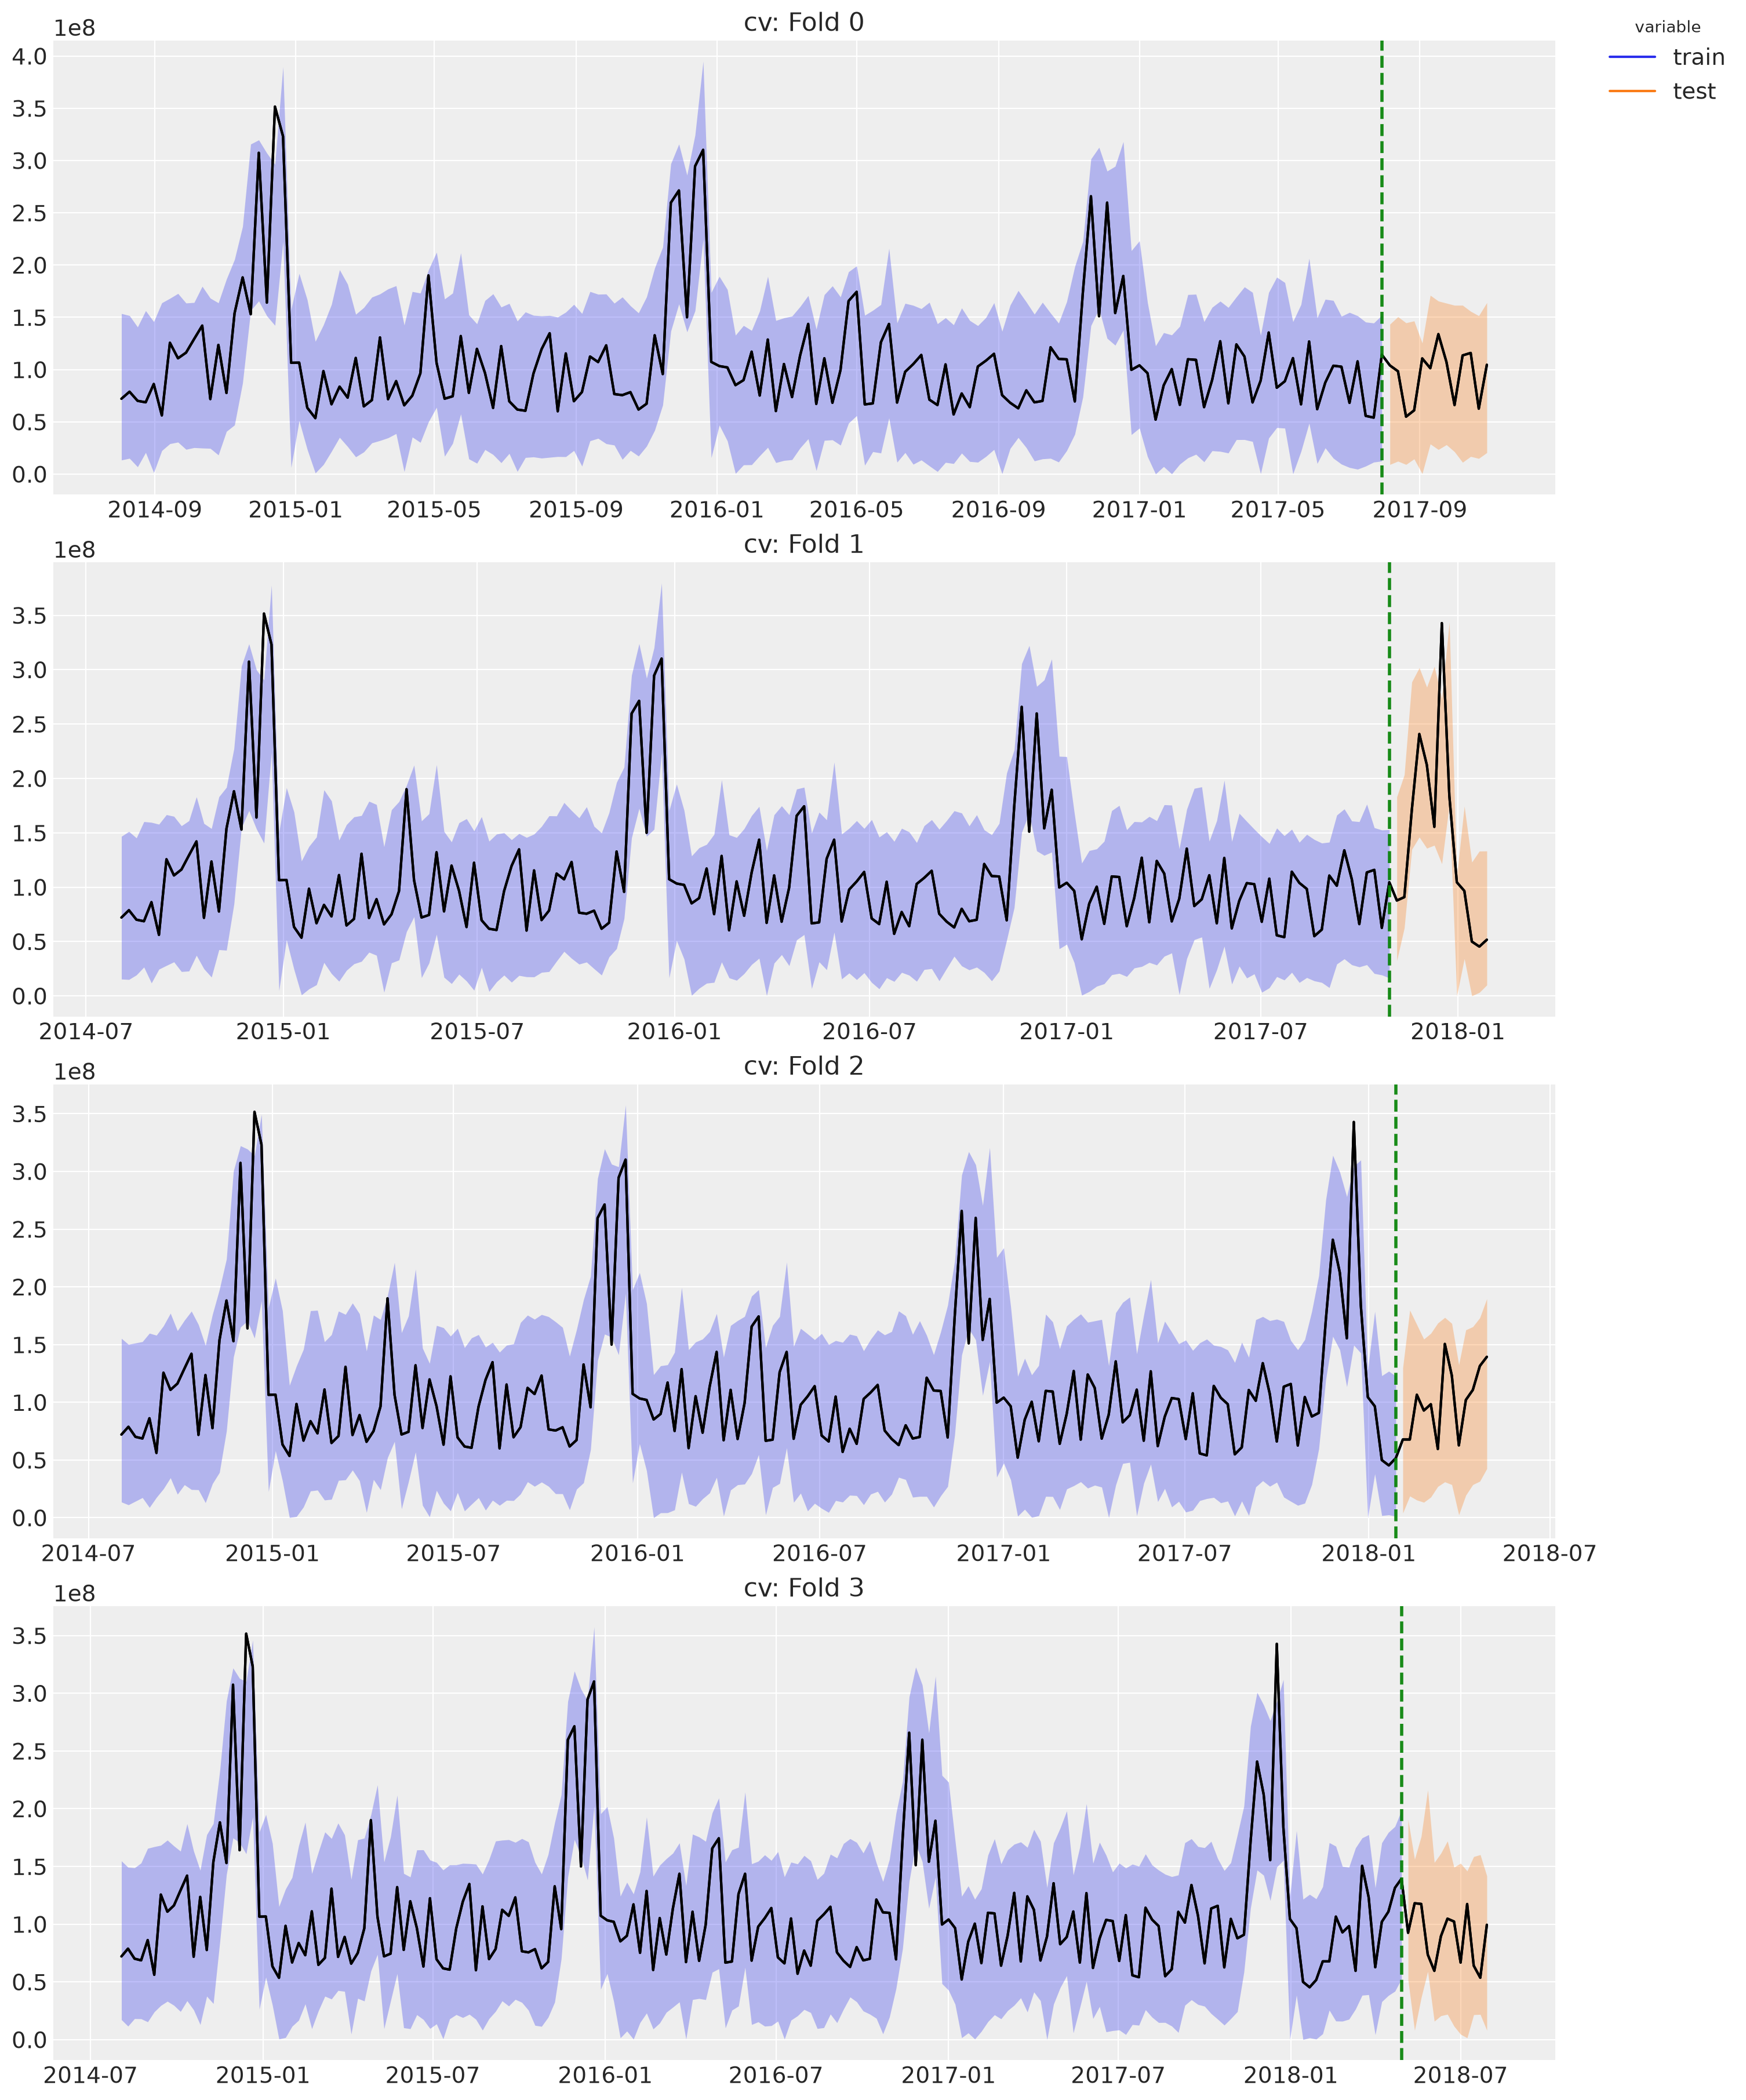

In [19]:
cv.plot.predictions(figsize=(15, 18));

The forecast bands cover the observed sales in all four held-out quarters. The hardest one is Fold 1, whose test window contains the 2017 holiday peak: the model covers the spike, but with visibly wider uncertainty, and this is the fold with the highest test score in the CRPS table below.

### Parameter Stability

The decision-relevant question: do the channel effects and the funnel strength depend on which window we fit? Stable medians across folds mean the conclusions are not an artifact of one period.

For the two calibrated channels, part of the stability is by construction: every fold sees the same two experiments, so their saturation betas are anchored. The interesting rows are the uncalibrated ones.

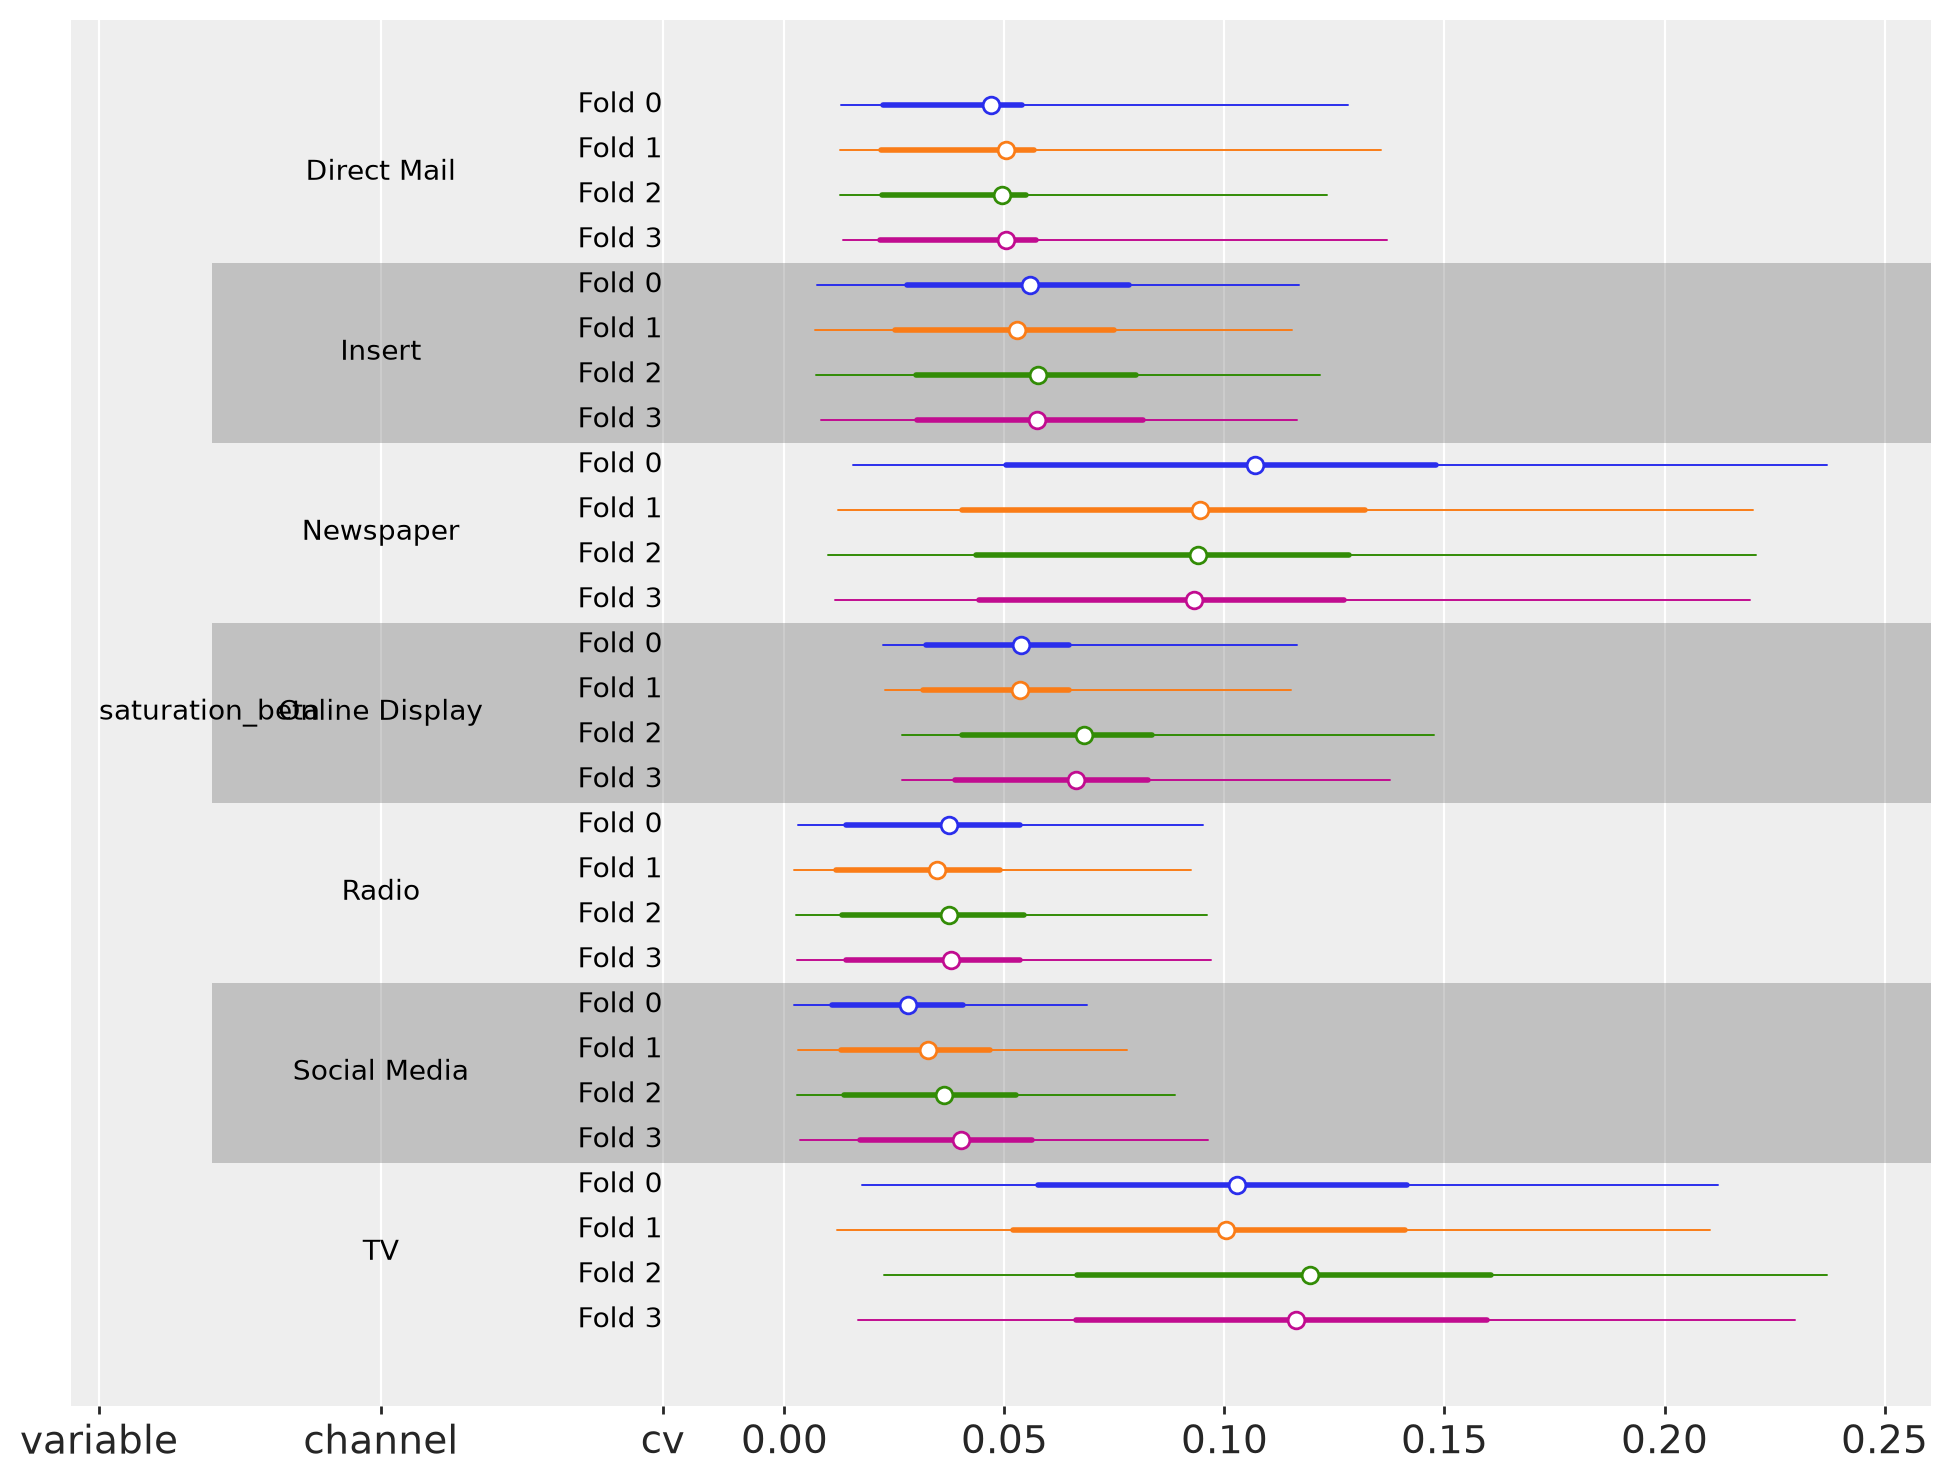

In [20]:
cv.plot.param_stability(var_names=["saturation_beta"], figsize=(12, 9));

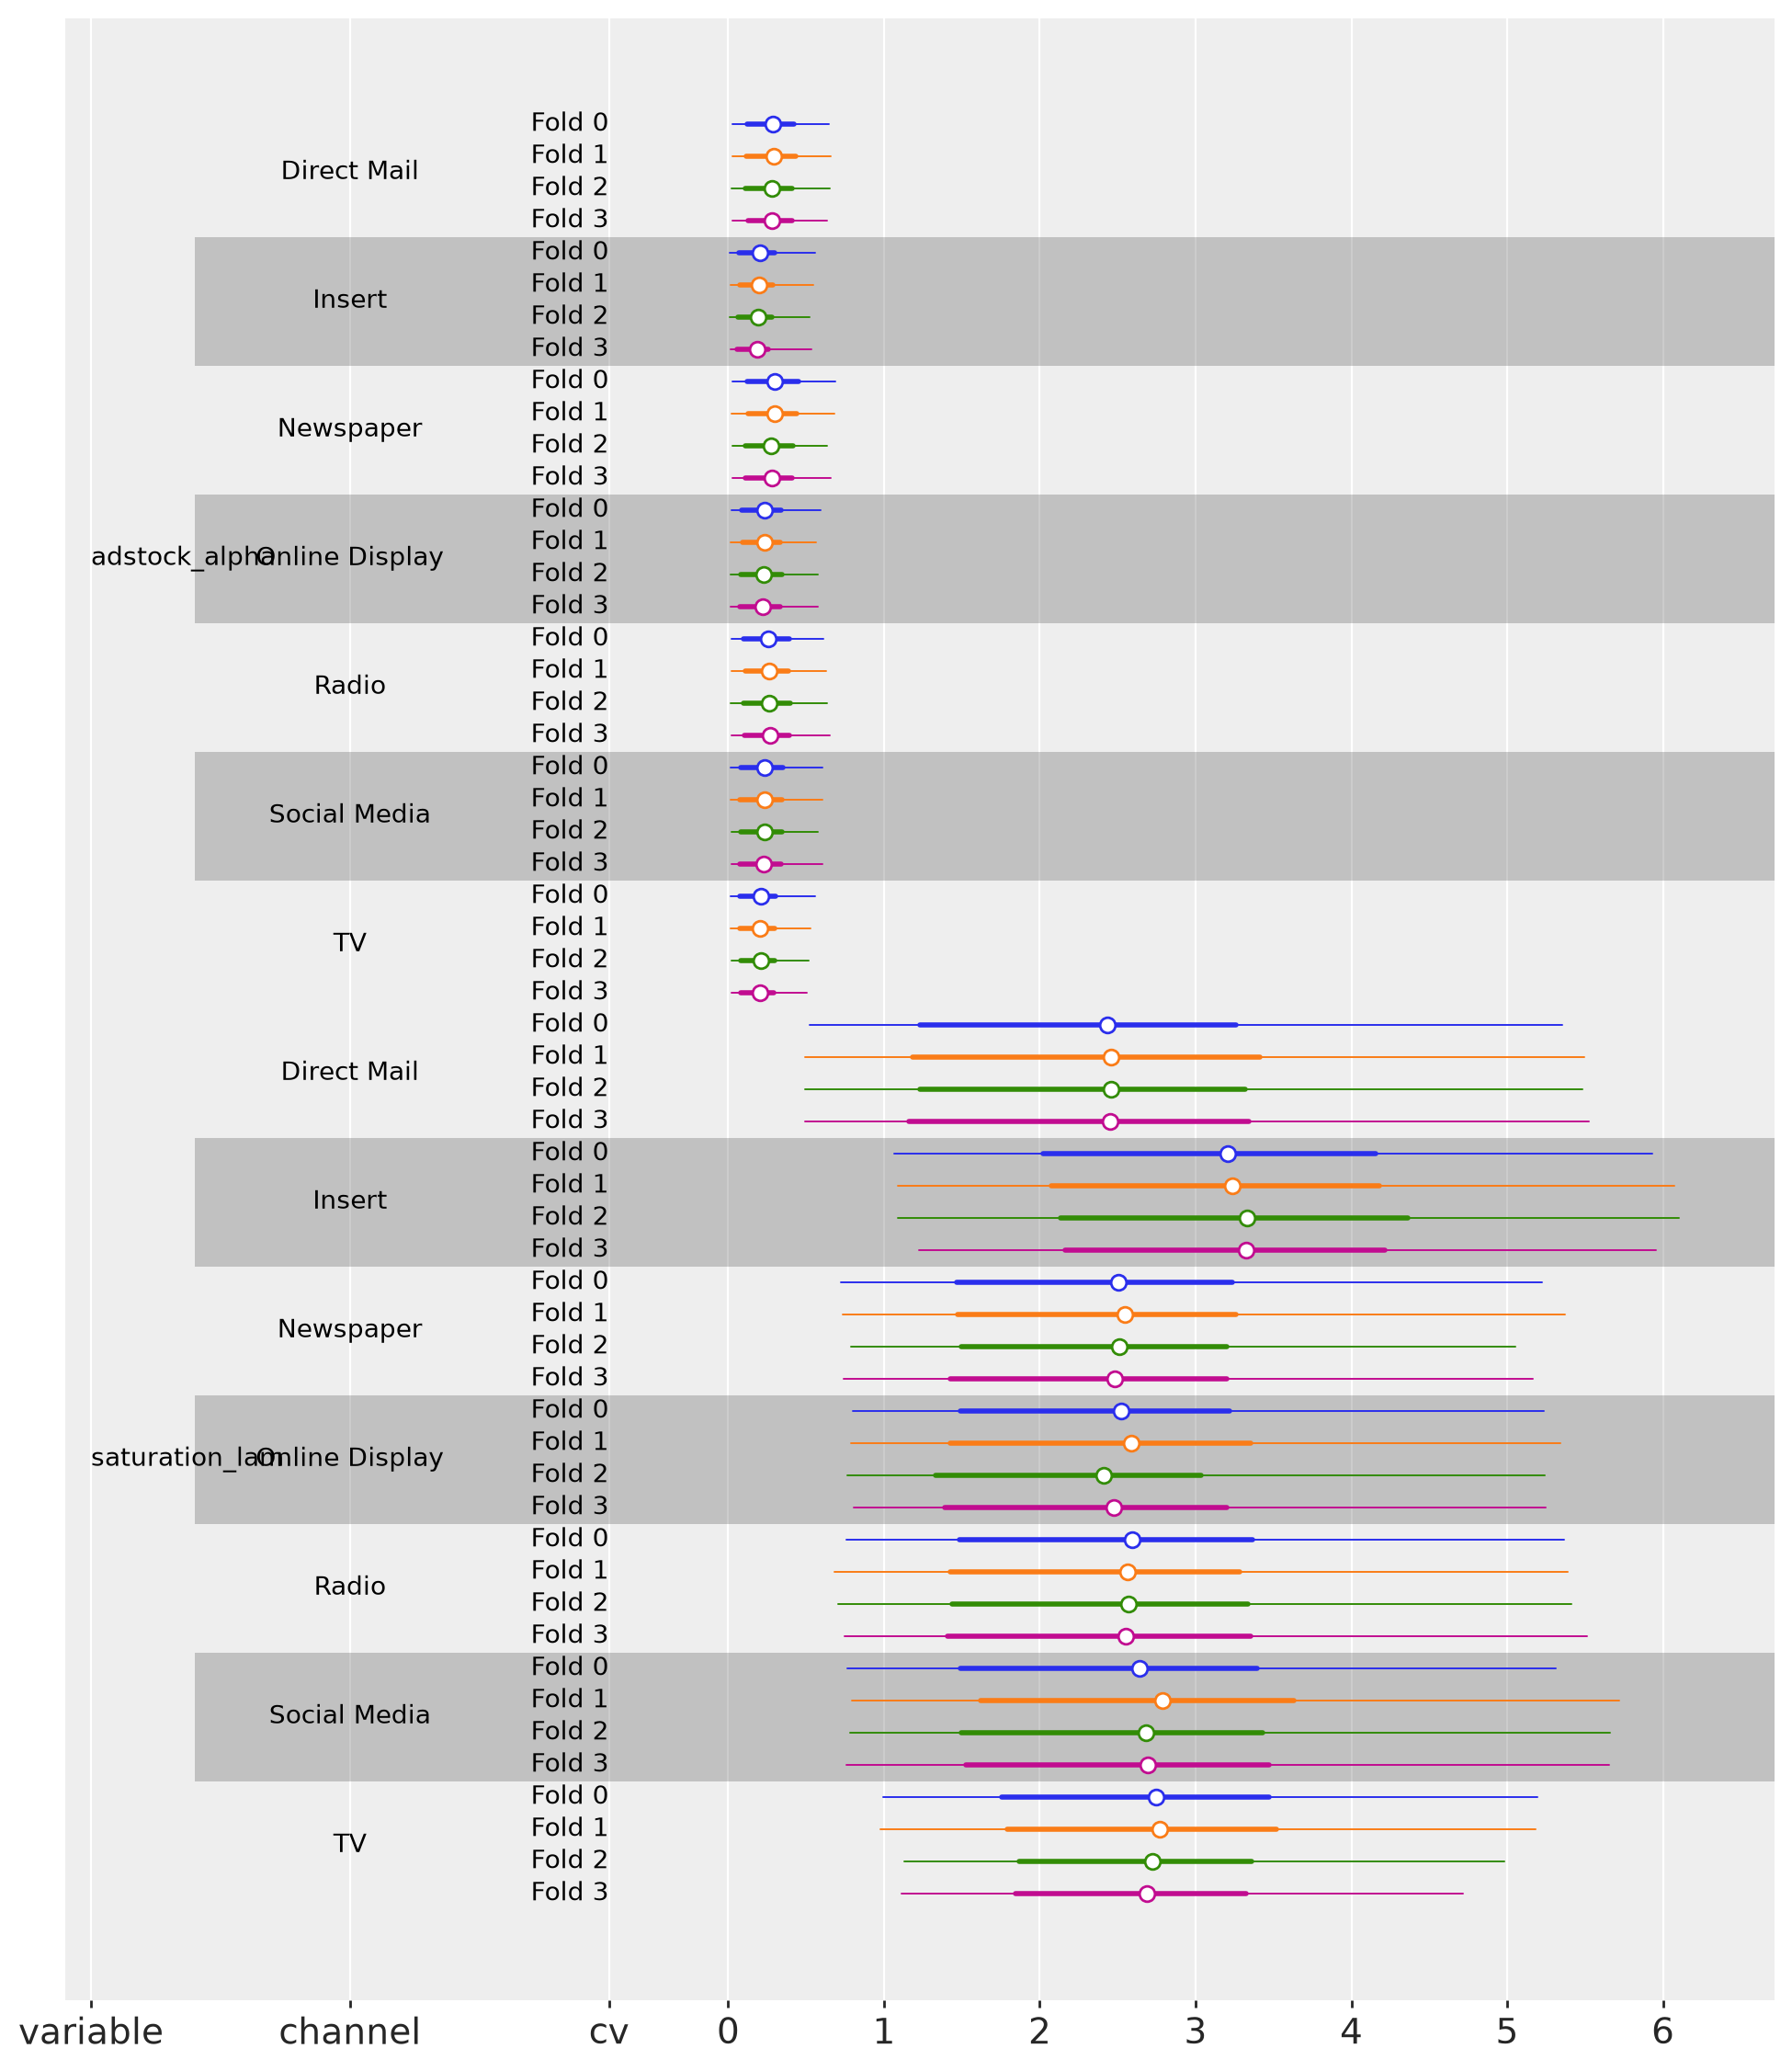

In [21]:
cv.plot.param_stability(
    var_names=["adstock_alpha", "saturation_lam"], figsize=(12, 14)
);

The funnel strength `funnel_lambda` is the parameter the whole SEM story hangs on: it measures how strongly an extra unit of SEM budget lifts the mediator. It is a scalar, so the channel-oriented stability plot does not apply; a plain forest over the folds shows the same thing.

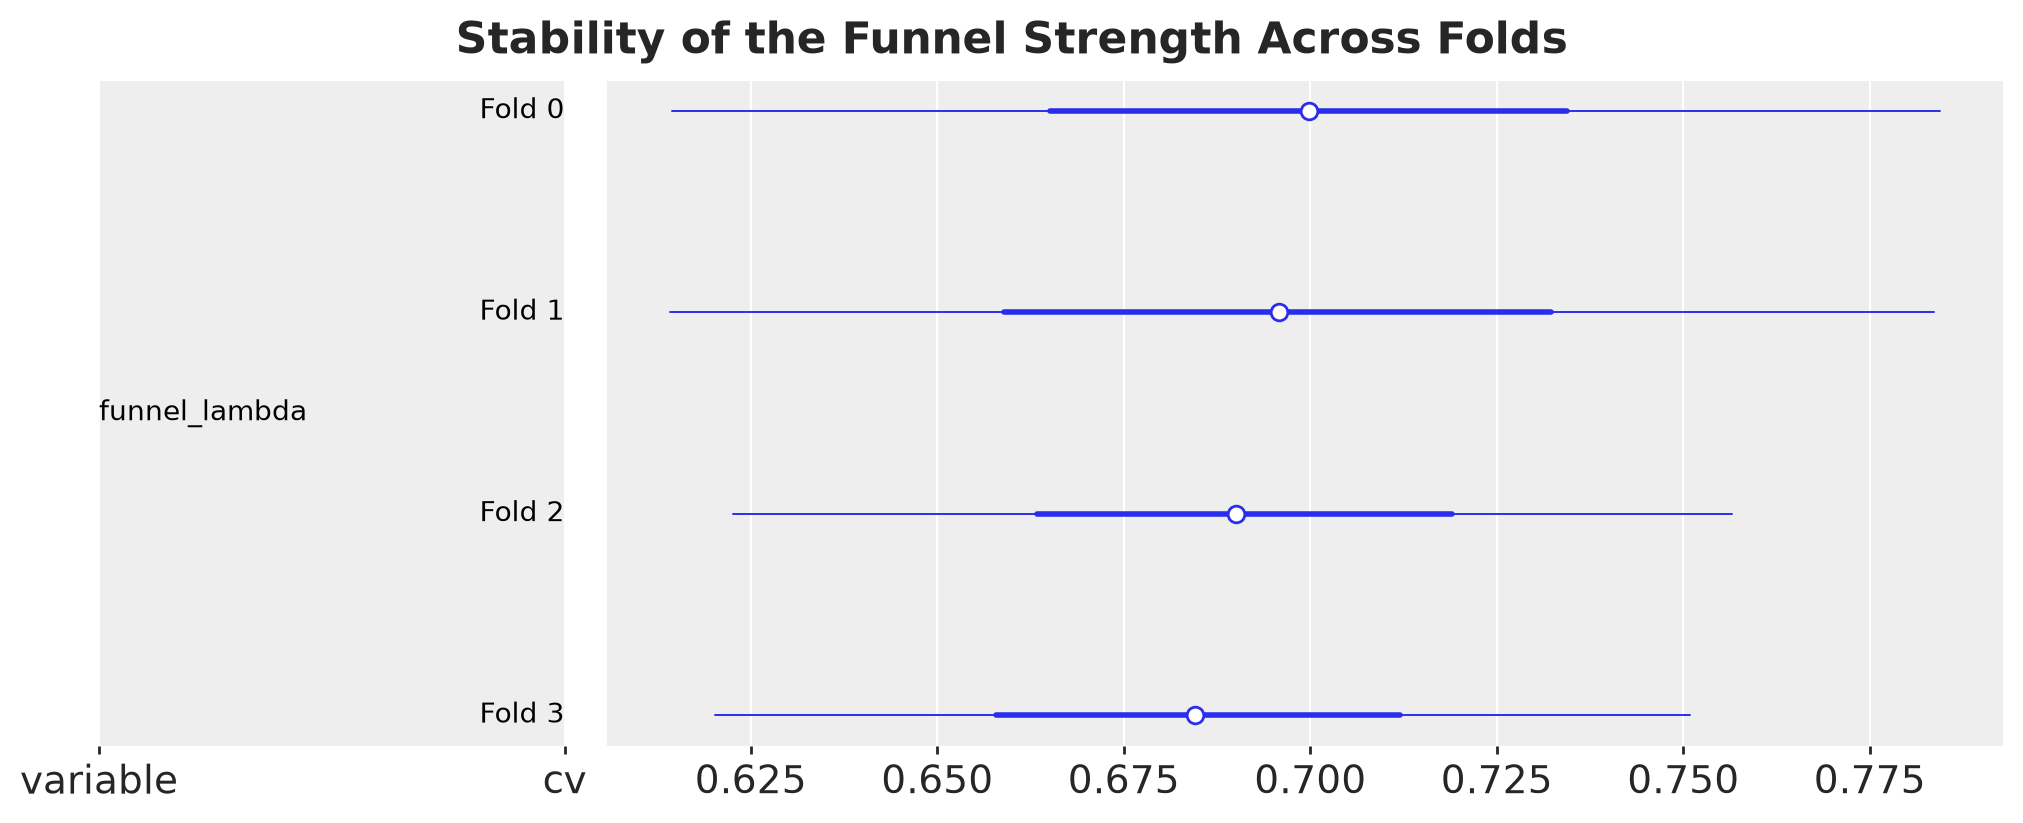

In [22]:
pc = azp.plot_forest(
    cv_results["posterior"].to_dataset()[["funnel_lambda"]],
    combined=True,
    figure_kwargs={"figsize": (10, 4)},
)
fig = pc.viz["/"]["figure"].values.item()
fig.suptitle(
    "Stability of the Funnel Strength Across Folds", fontsize=16, fontweight="bold"
);

The media parameters are stable: the per-fold posteriors overlap heavily for every channel, with no jumps as the training window grows quarter by quarter. The two calibrated channels show the tightest saturation posteriors, which is partly by construction, as noted above. The funnel strength is stable too: all four folds put `funnel_lambda` near 0.69 with almost identical intervals, so each additional quarter of data tells the same story about how strongly SEM budget moves the mediator.

### Forecast Quality: CRPS

The continuous ranked probability score (CRPS) scores the whole forecast distribution against the observed value; lower is better. We compare training and test scores per fold. A test score drifting up while the training score drifts down is the overfitting signature the single split in the first iteration could not show.

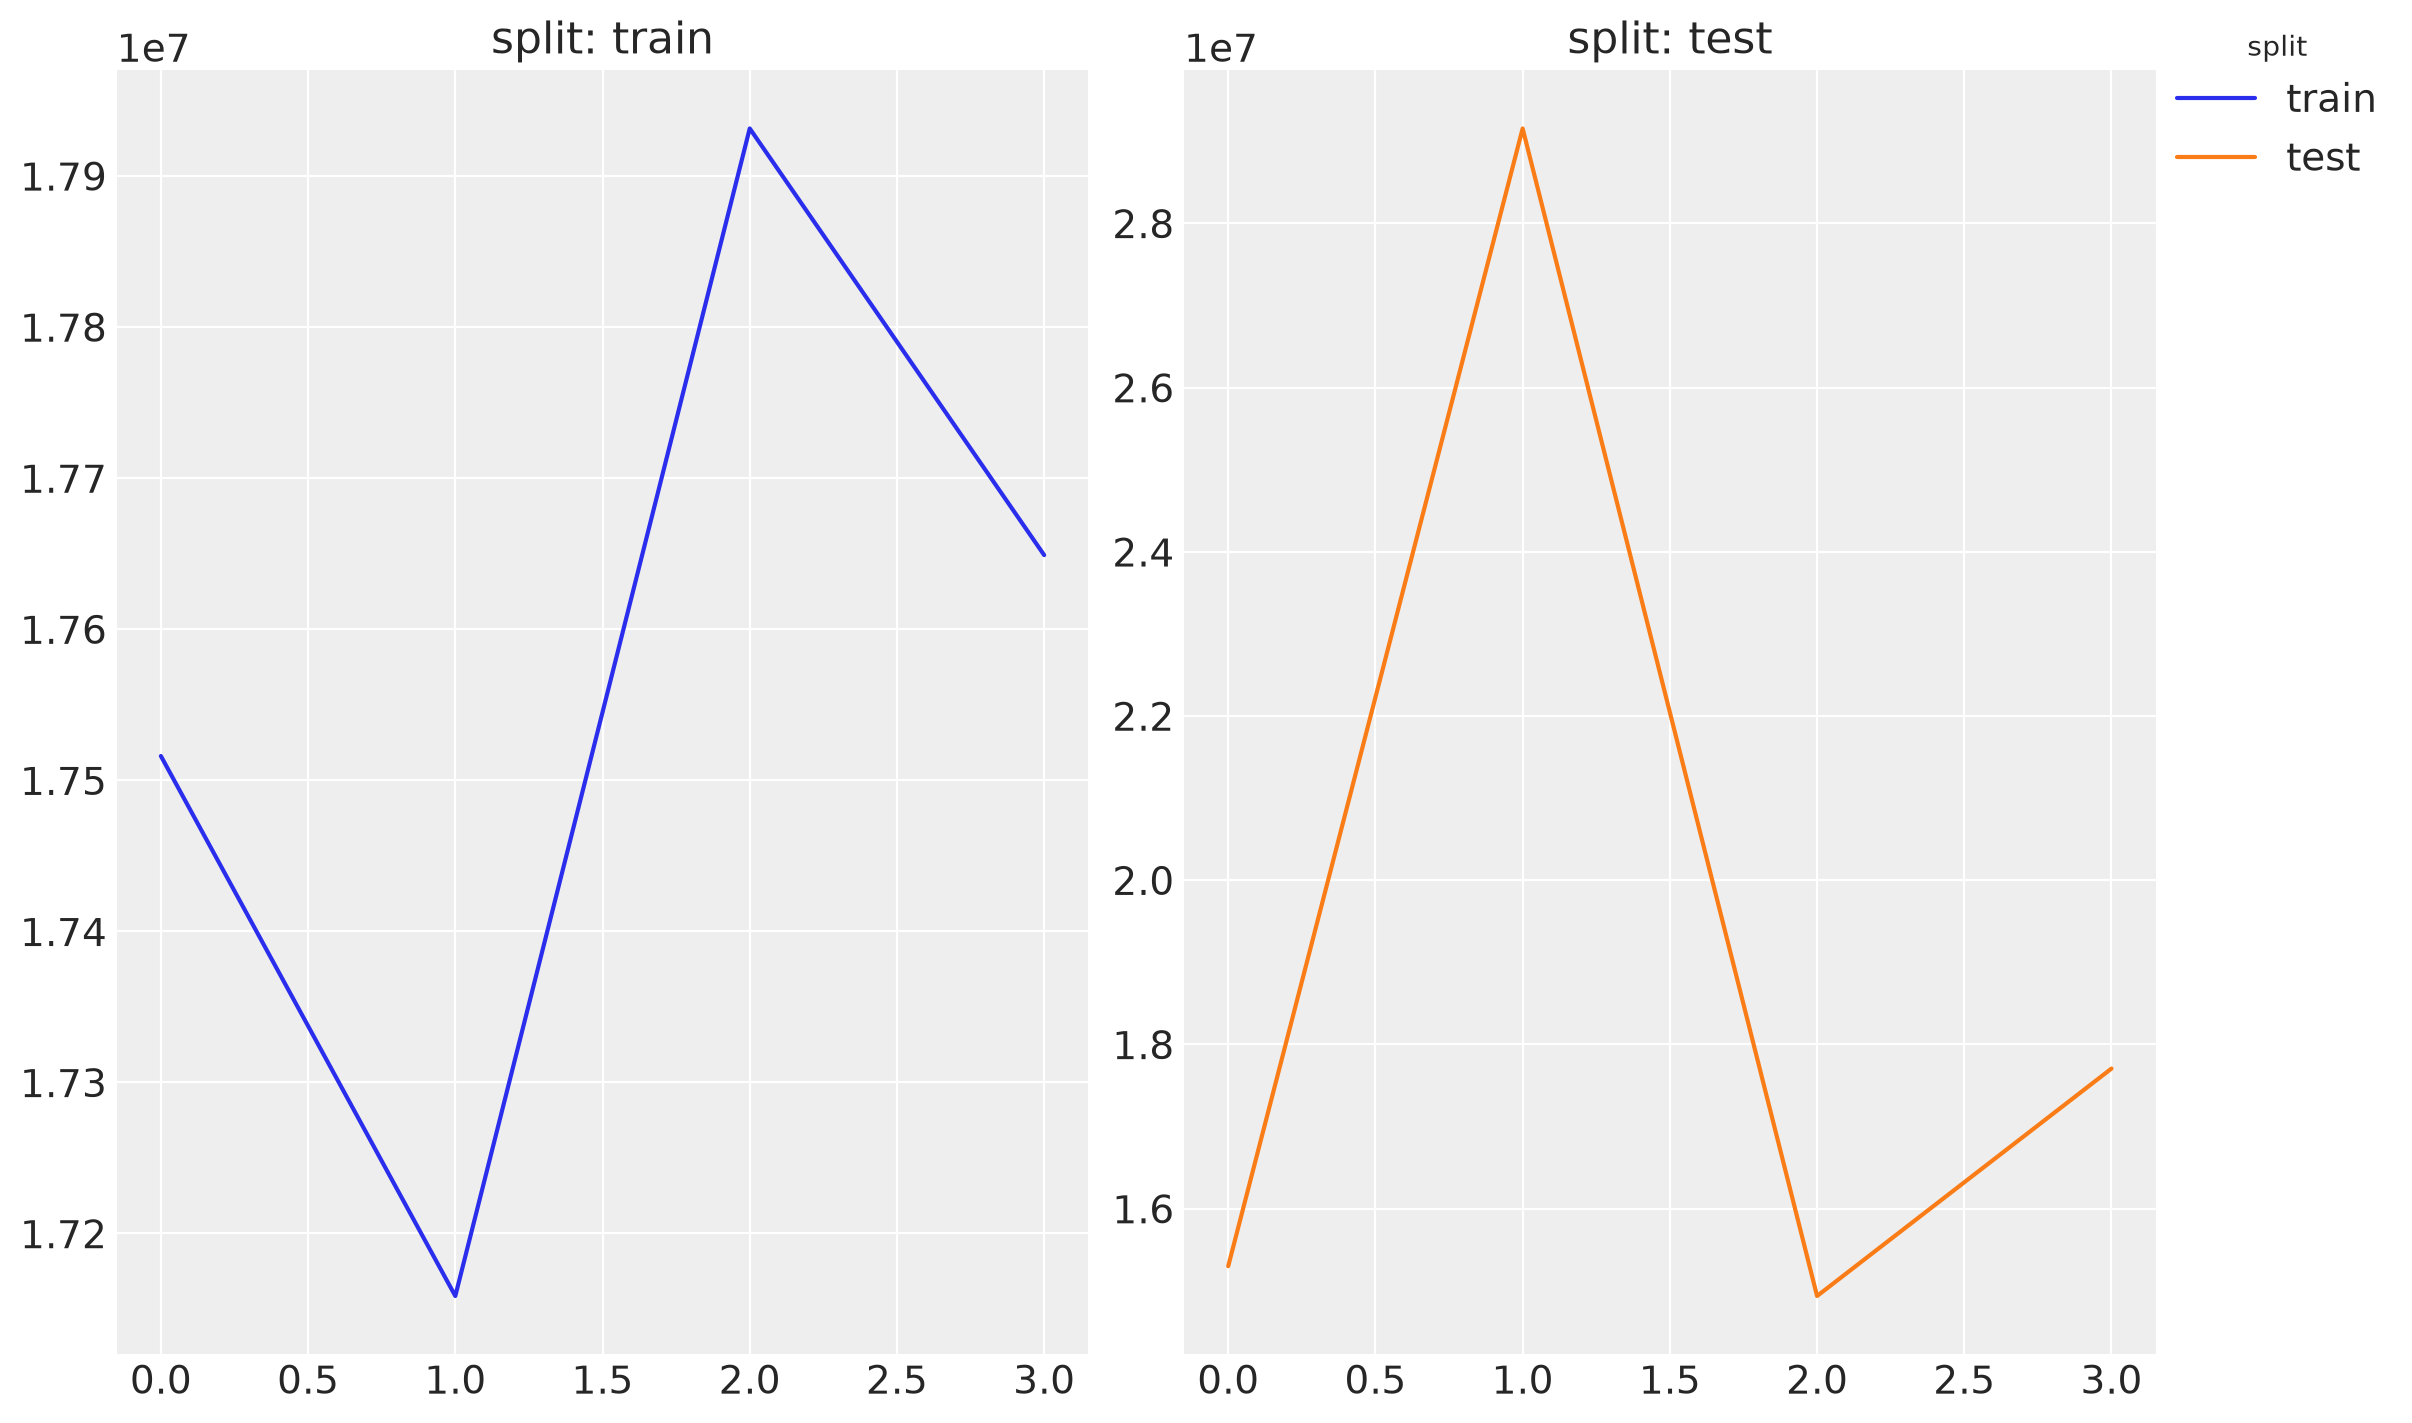

In [23]:
cv.plot.crps();

In [24]:
cv.summary.crps()

,split,cv,mean_crps
0,train,Fold 0,1.751600e+07
1,train,Fold 1,1.715858e+07
2,train,Fold 2,1.793134e+07
3,train,Fold 3,1.764897e+07
4,test,Fold 0,1.529823e+07
5,test,Fold 1,2.915588e+07
6,test,Fold 2,1.493483e+07
7,test,Fold 3,1.770525e+07


Training CRPS is flat across folds at 17 to 18 million. Three of the four test scores sit at the same level or better (15 to 18 million); Fold 1 is the exception at 29 million, and its test window is the 2017 holiday quarter, the hardest 13 weeks of the year to forecast. There is no widening gap between train and test as the window grows, which is the overfitting signature this check exists to catch.

:::{tip}
With stability established, we are entitled to what we actually want: a final model fit on **all** the data. The cross-validation models are discarded; their job was to certify the specification, not to make predictions.
:::

## Final Model: Build, Calibrate, and Fit on All Data

The final model uses the same builder logic on the full 209 weeks. The required order is fixed by the API: build the model, register the original-scale contribution variables, add the ROAS calibration, then fit.

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pymc_extras/prior.py:851: UserWarning: Implicit conversion of array-like parameter sigma to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning
  return _param_value_with_dims(param, value, dims=self.dims)


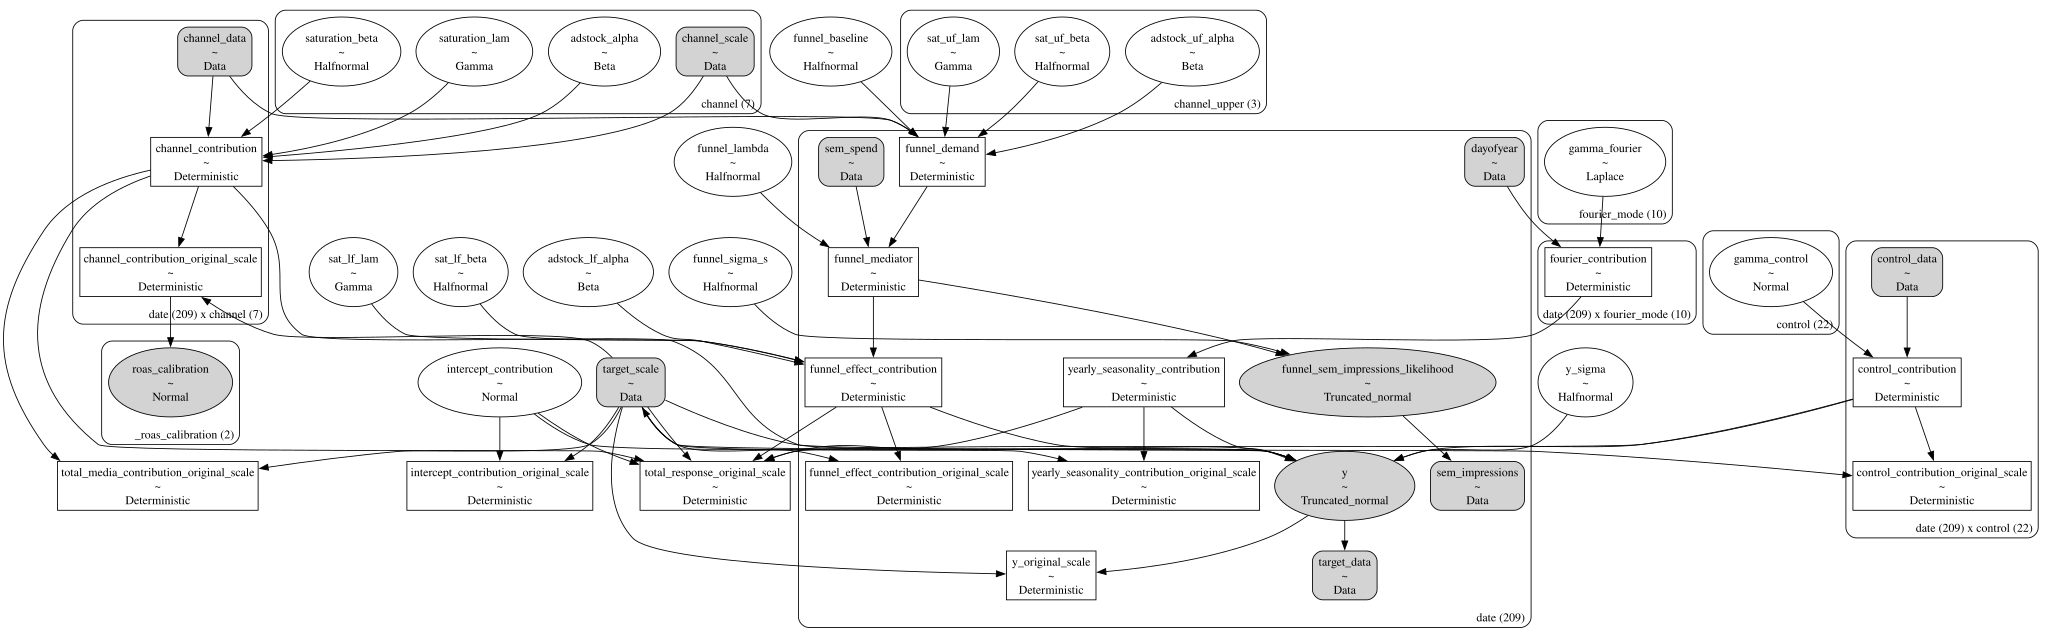

In [25]:
mmm = make_mmm(X)
mmm.build_model(X=make_funnel_dataset(X, y))

mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "control_contribution",
        "intercept_contribution",
        "yearly_seasonality_contribution",
        "funnel_effect_contribution",
        "y",
    ]
)

mmm.add_cost_per_target_calibration(
    data=X,
    calibration_data=roas_calibration_df,
    name_prefix="roas_calibration",
    target_column="roas",
    target_per_cost=True,
)

pm.model_to_graphviz(mmm.model)

The graph shows what this iteration actually fits: three data sources at once. The sales likelihood, the SEM impressions likelihood inside the funnel effect, and the two experiment observations under `roas_calibration`.

### Prior Predictive Check

Before fitting, we confirm the priors put sales in a plausible range: weakly informative, roughly the right order of magnitude, no strong commitments.

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [adstock_alpha, adstock_lf_alpha, adstock_uf_alpha, funnel_baseline, funnel_lambda, funnel_sem_impressions_likelihood, funnel_sigma_s, gamma_control, gamma_fourier, intercept_contribution, roas_calibration, sat_lf_beta, sat_lf_lam, sat_uf_beta, sat_uf_lam, saturation_beta, saturation_lam, y, y_sigma]


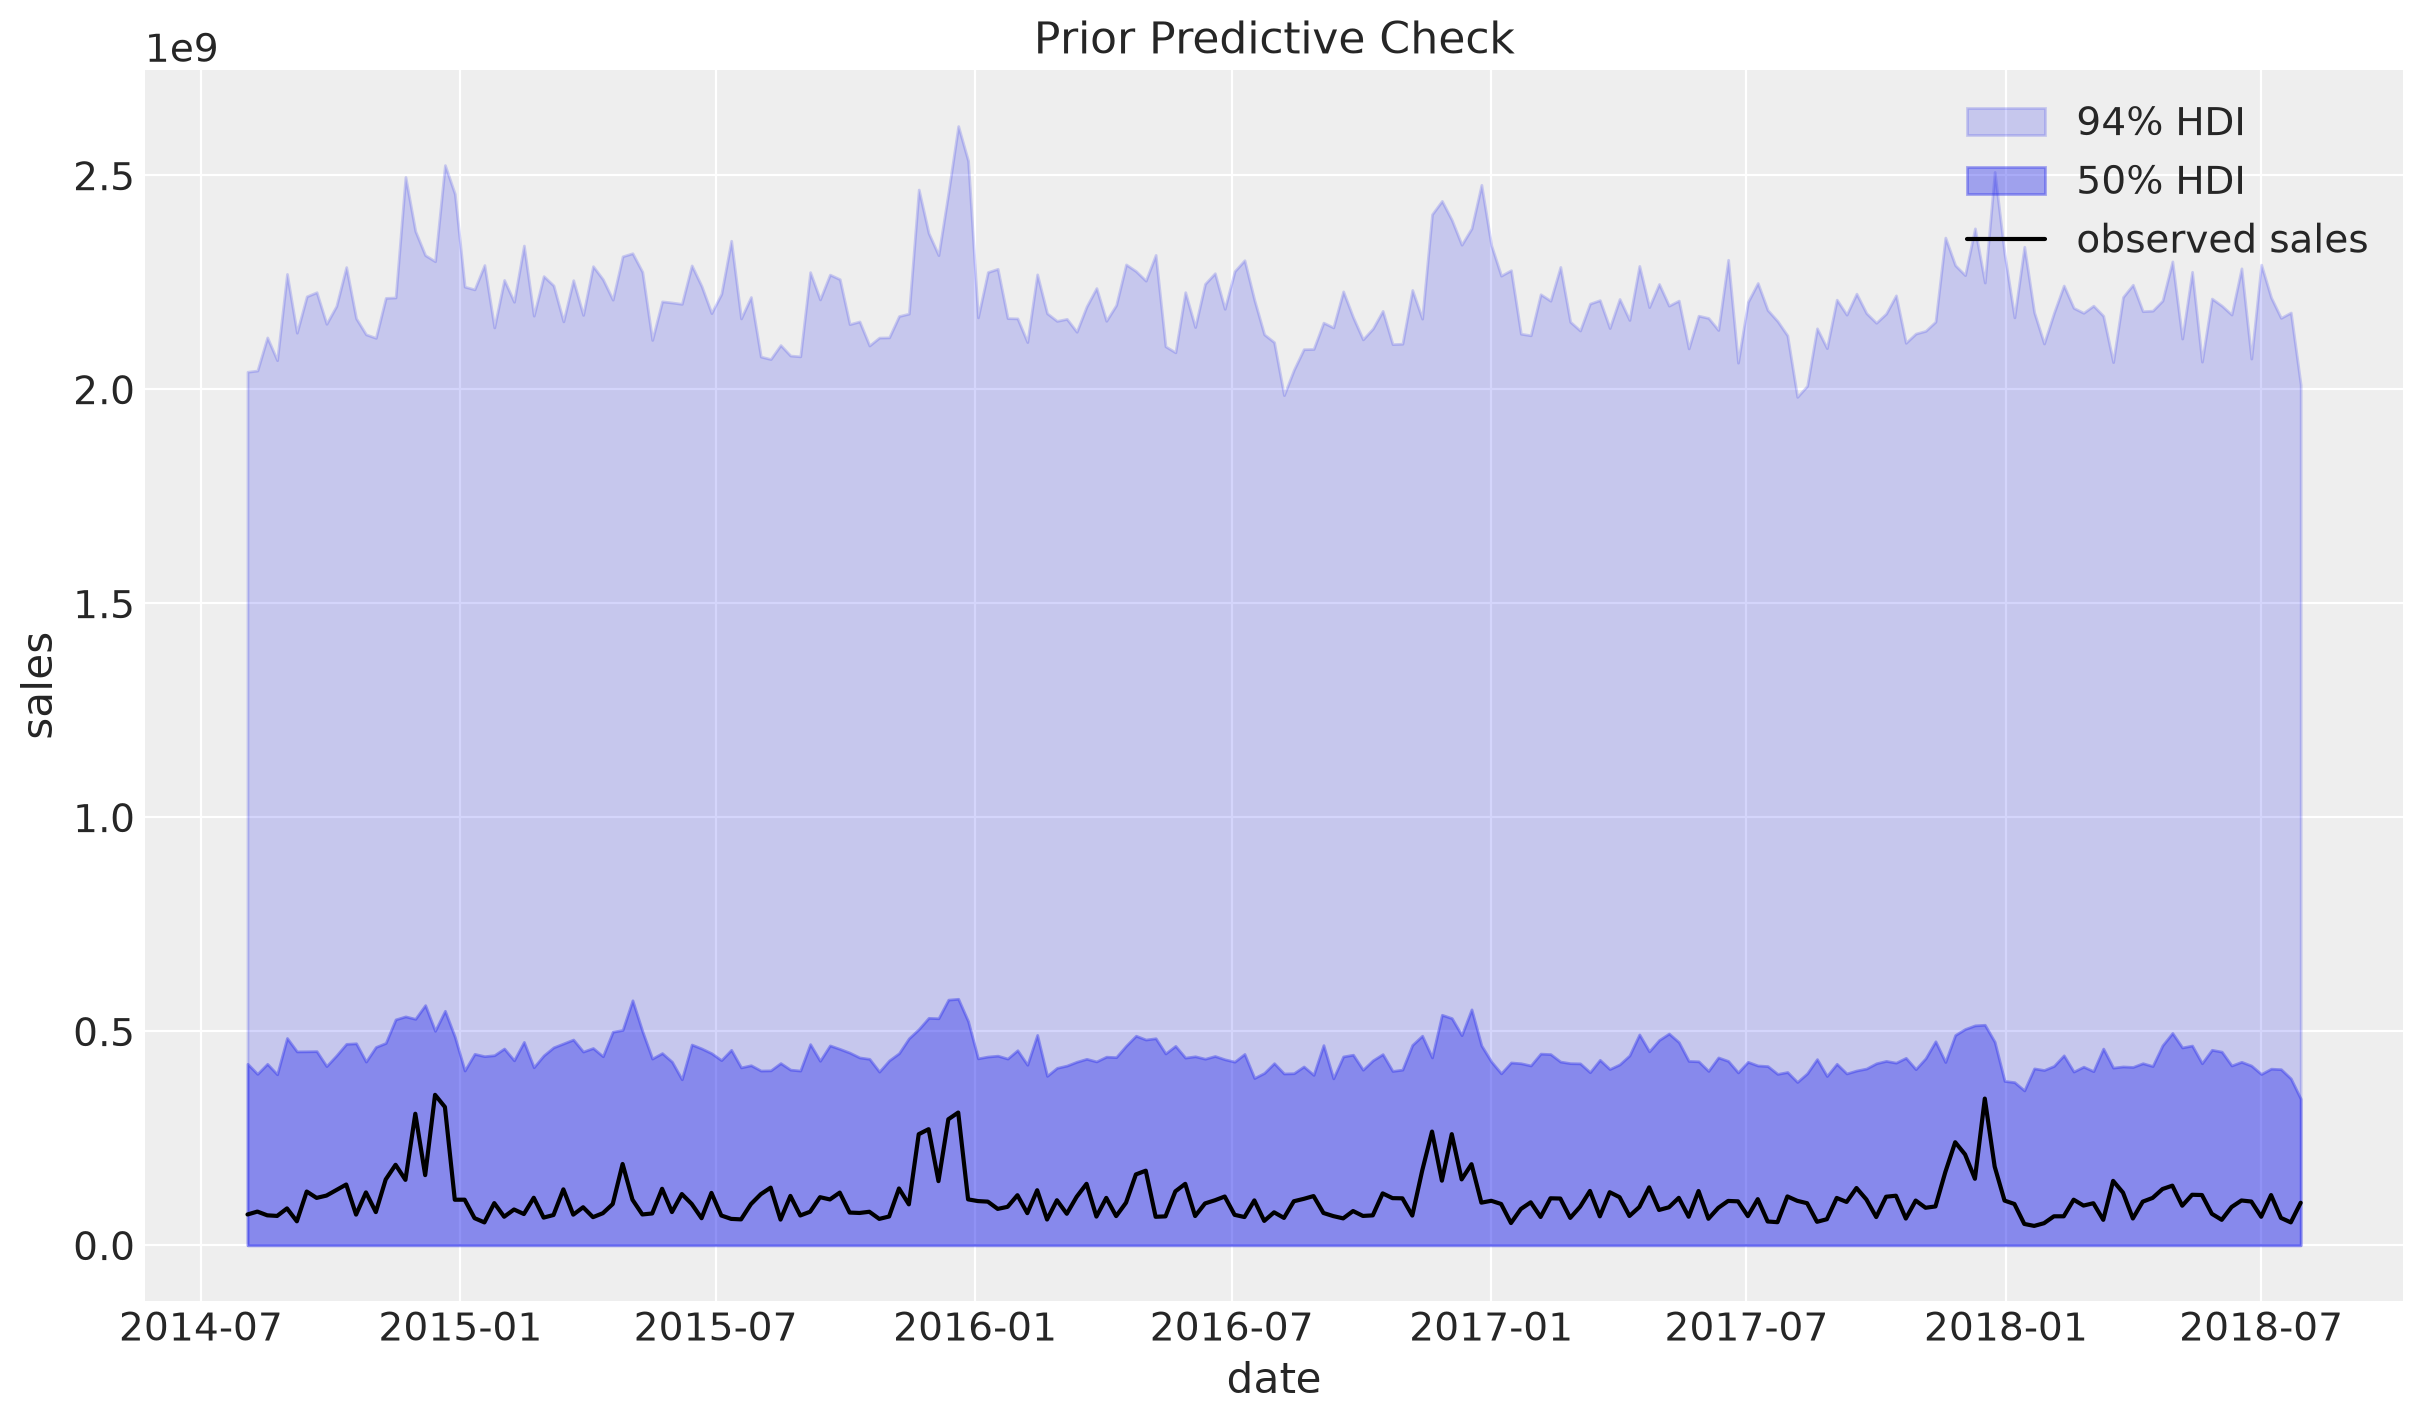

In [26]:
mmm.sample_prior_predictive(X, y, samples=2_000)

fig, ax = plt.subplots()
prior_y = mmm.idata["prior"]["y_original_scale"]
dates = X[date_column]
for prob, alpha in [(0.94, 0.2), (0.5, 0.4)]:
    hdi = az.hdi(prior_y, prob=prob)
    ax.fill_between(
        dates,
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        color="C0",
        alpha=alpha,
        label=f"{prob:.0%} HDI",
    )
ax.plot(dates, y, color="black", label="observed sales")
ax.legend(loc="upper right")
ax.set(title="Prior Predictive Check", xlabel="date", ylabel="sales");

### Fit

In [27]:
mmm.fit(
    X=X,
    y=y,
    target_accept=0.9,
    chains=4,
    cores=4,
    draws=1_000,
    tune=1_500,
    nuts_sampler="nutpie",
    random_seed=rng,
)

mmm.sample_posterior_predictive(X, random_seed=rng)
mmm.plot_suite = "new"

NUTS[nutpie]: [y_sigma, adstock_lf_alpha, funnel_lambda, adstock_uf_alpha, sat_uf_lam, sat_uf_beta, funnel_baseline, sat_lf_lam, sat_lf_beta, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, funnel_sigma_s]


Output()

Output()

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [funnel_sem_impressions_likelihood, roas_calibration, y]


Output()

## Model Diagnostics

Same bar as the first iteration: zero divergences, all $\hat{R}$ below 1.01, clean traces. The funnel block adds a handful of parameters to the checklist.

In [28]:
n_divergences = int(mmm.idata["sample_stats"]["diverging"].sum().item())
print(f"Number of divergences: {n_divergences}")
if n_divergences != 0:
    raise RuntimeError("the sampler reported divergences, do not proceed")

Number of divergences: 0


In [29]:
diagnostic_var_names = [
    "intercept_contribution",
    "y_sigma",
    "saturation_beta",
    "saturation_lam",
    "adstock_alpha",
    "gamma_control",
    "gamma_fourier",
    "funnel_baseline",
    "funnel_lambda",
    "funnel_sigma_s",
    "adstock_uf_alpha",
    "sat_uf_lam",
    "sat_uf_beta",
    "adstock_lf_alpha",
    "sat_lf_lam",
    "sat_lf_beta",
]
r_hat = az.summary(data=mmm.idata, var_names=diagnostic_var_names)["r_hat"].astype(
    float
)
print(f"max r_hat: {r_hat.max():.3f}")
r_hat.describe()

max r_hat: 1.010


count    70.000000
mean      1.000571
std       0.002338
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       1.010000
Name: r_hat, dtype: float64

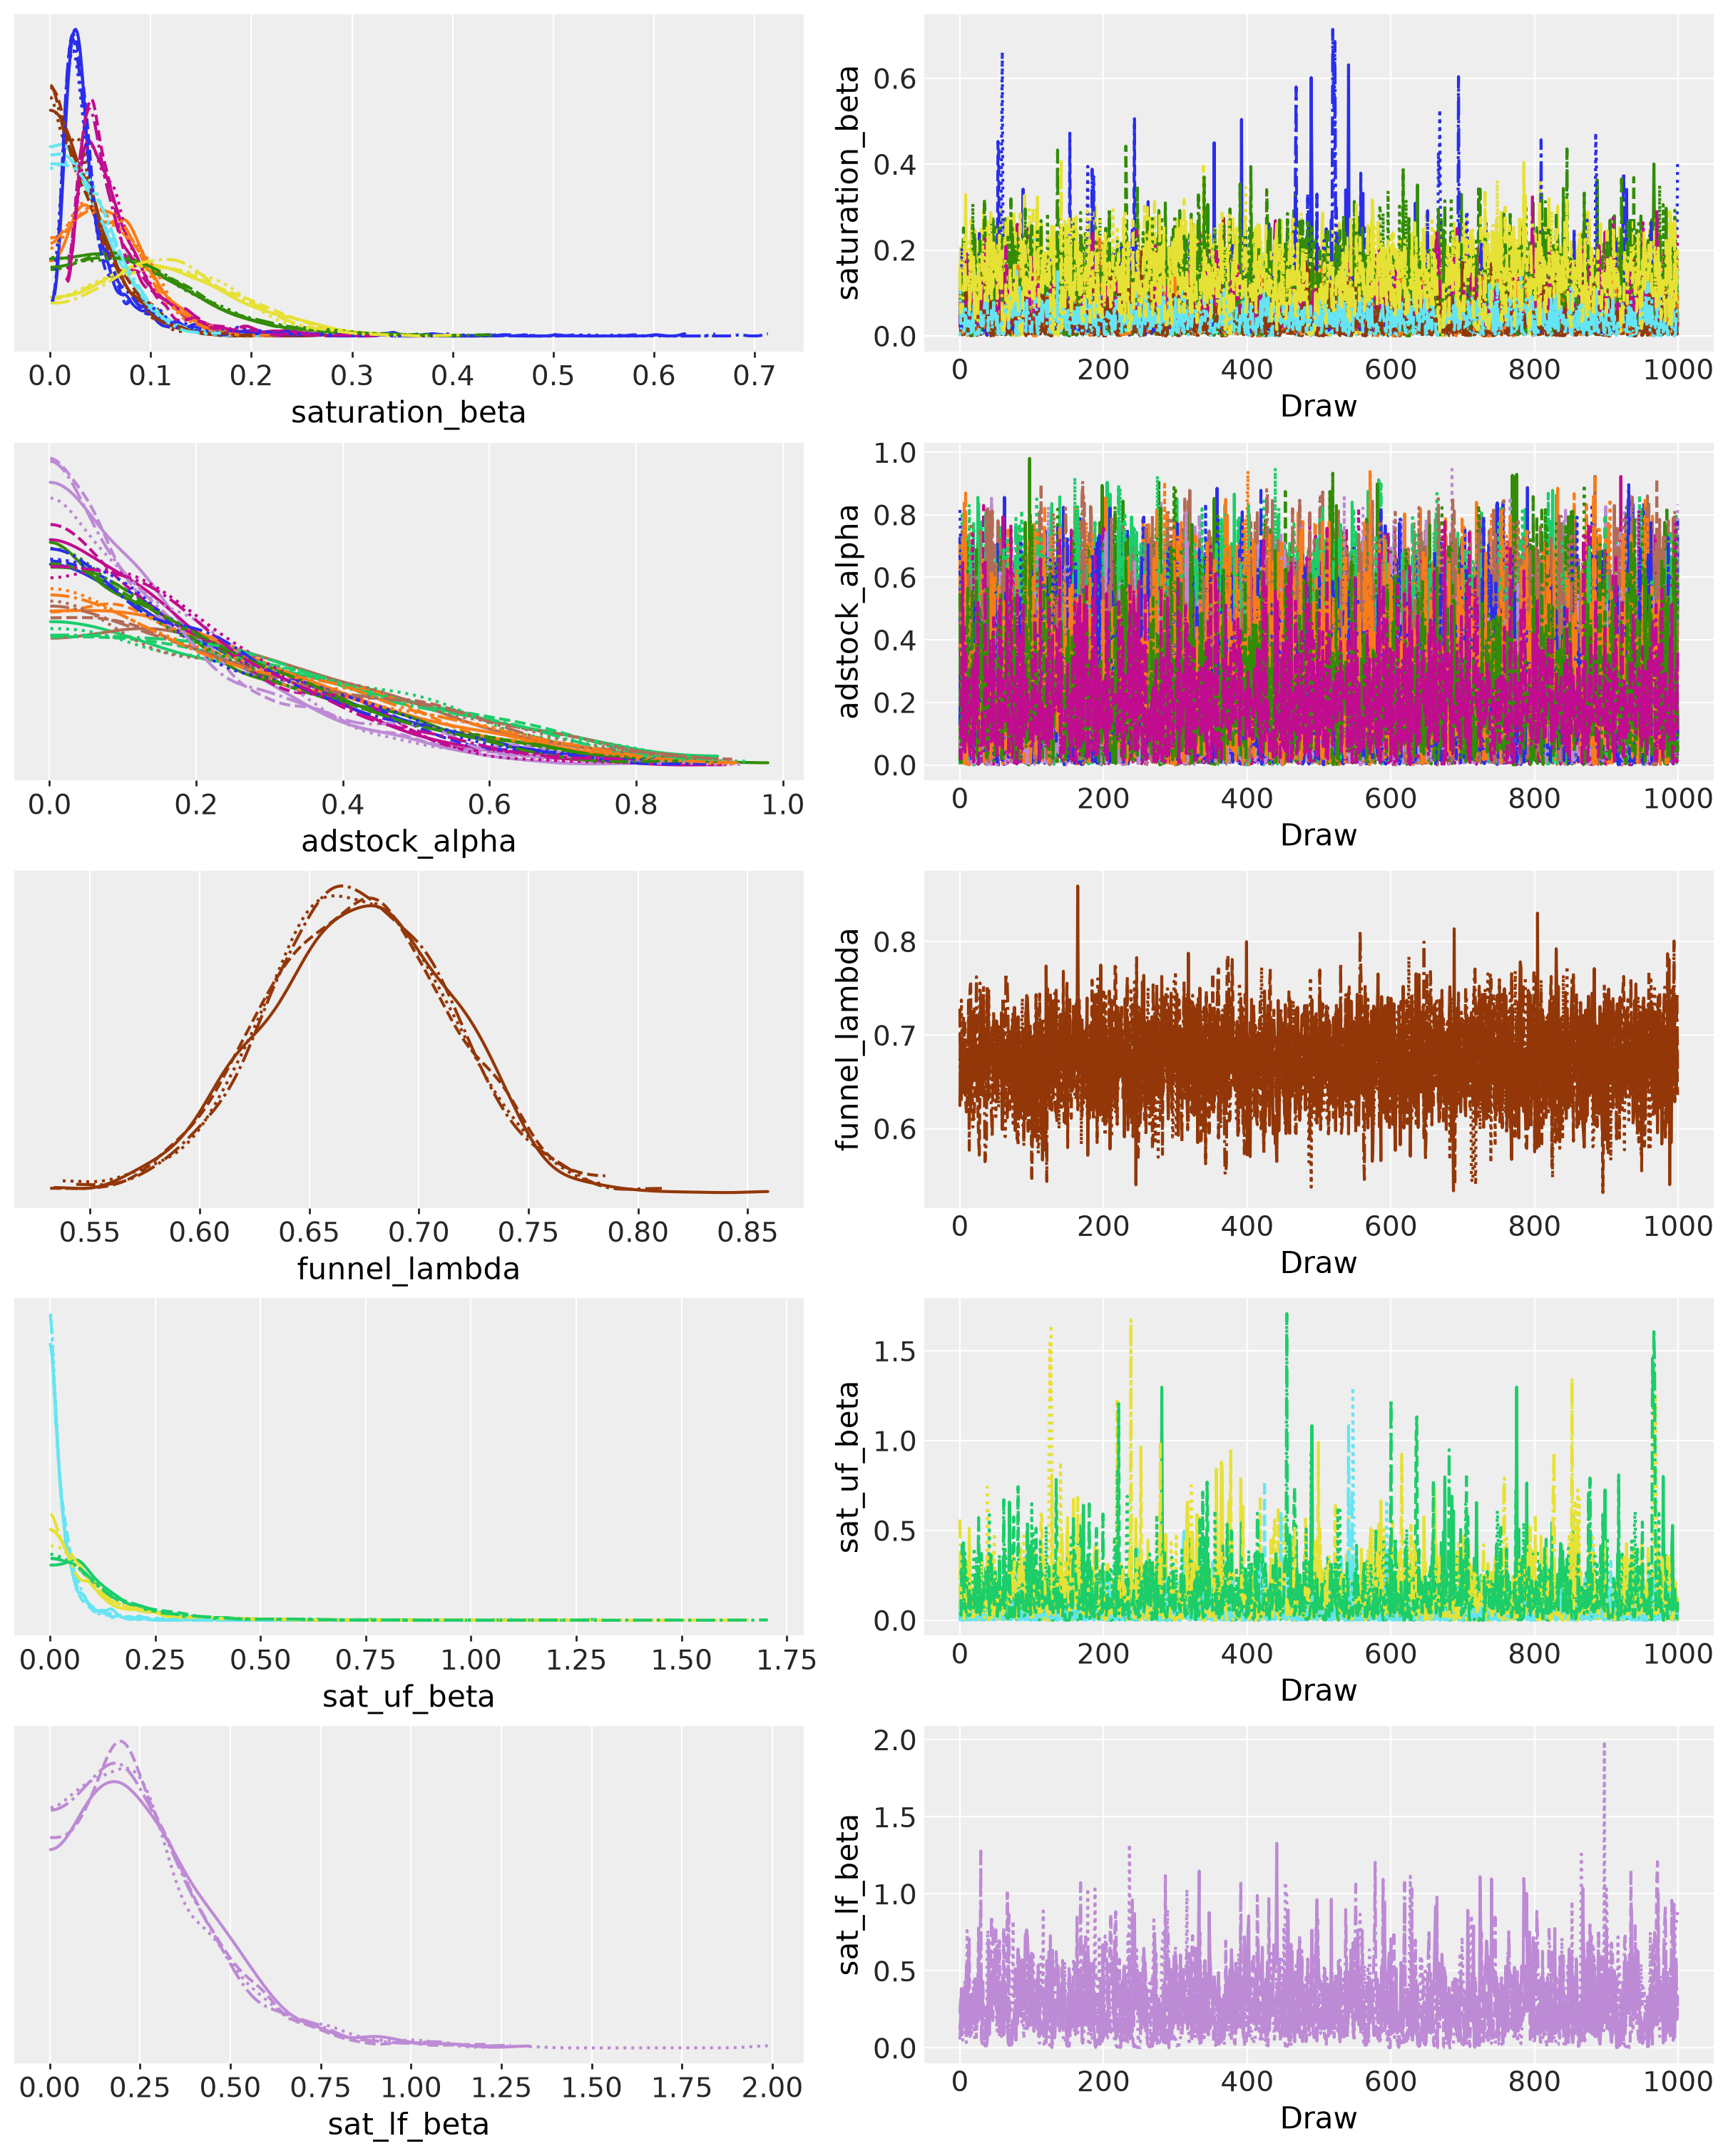

In [30]:
az.rcParams["plot.max_subplots"] = 100

azp.plot_trace_dist(
    mmm.fit_result,
    var_names=[
        "saturation_beta",
        "adstock_alpha",
        "funnel_lambda",
        "sat_uf_beta",
        "sat_lf_beta",
    ],
    figure_kwargs={"figsize": (12, 15)},
);

Chains mix well for the media and funnel blocks alike, consistent with the clean divergence and $\hat{R}$ summary above. The substantive finding sits in the `funnel_lambda` panel: the posterior concentrates around 0.68, clearly away from zero. The data support SEM budget moving the mediator.

## Posterior Predictive Checks

### Sales

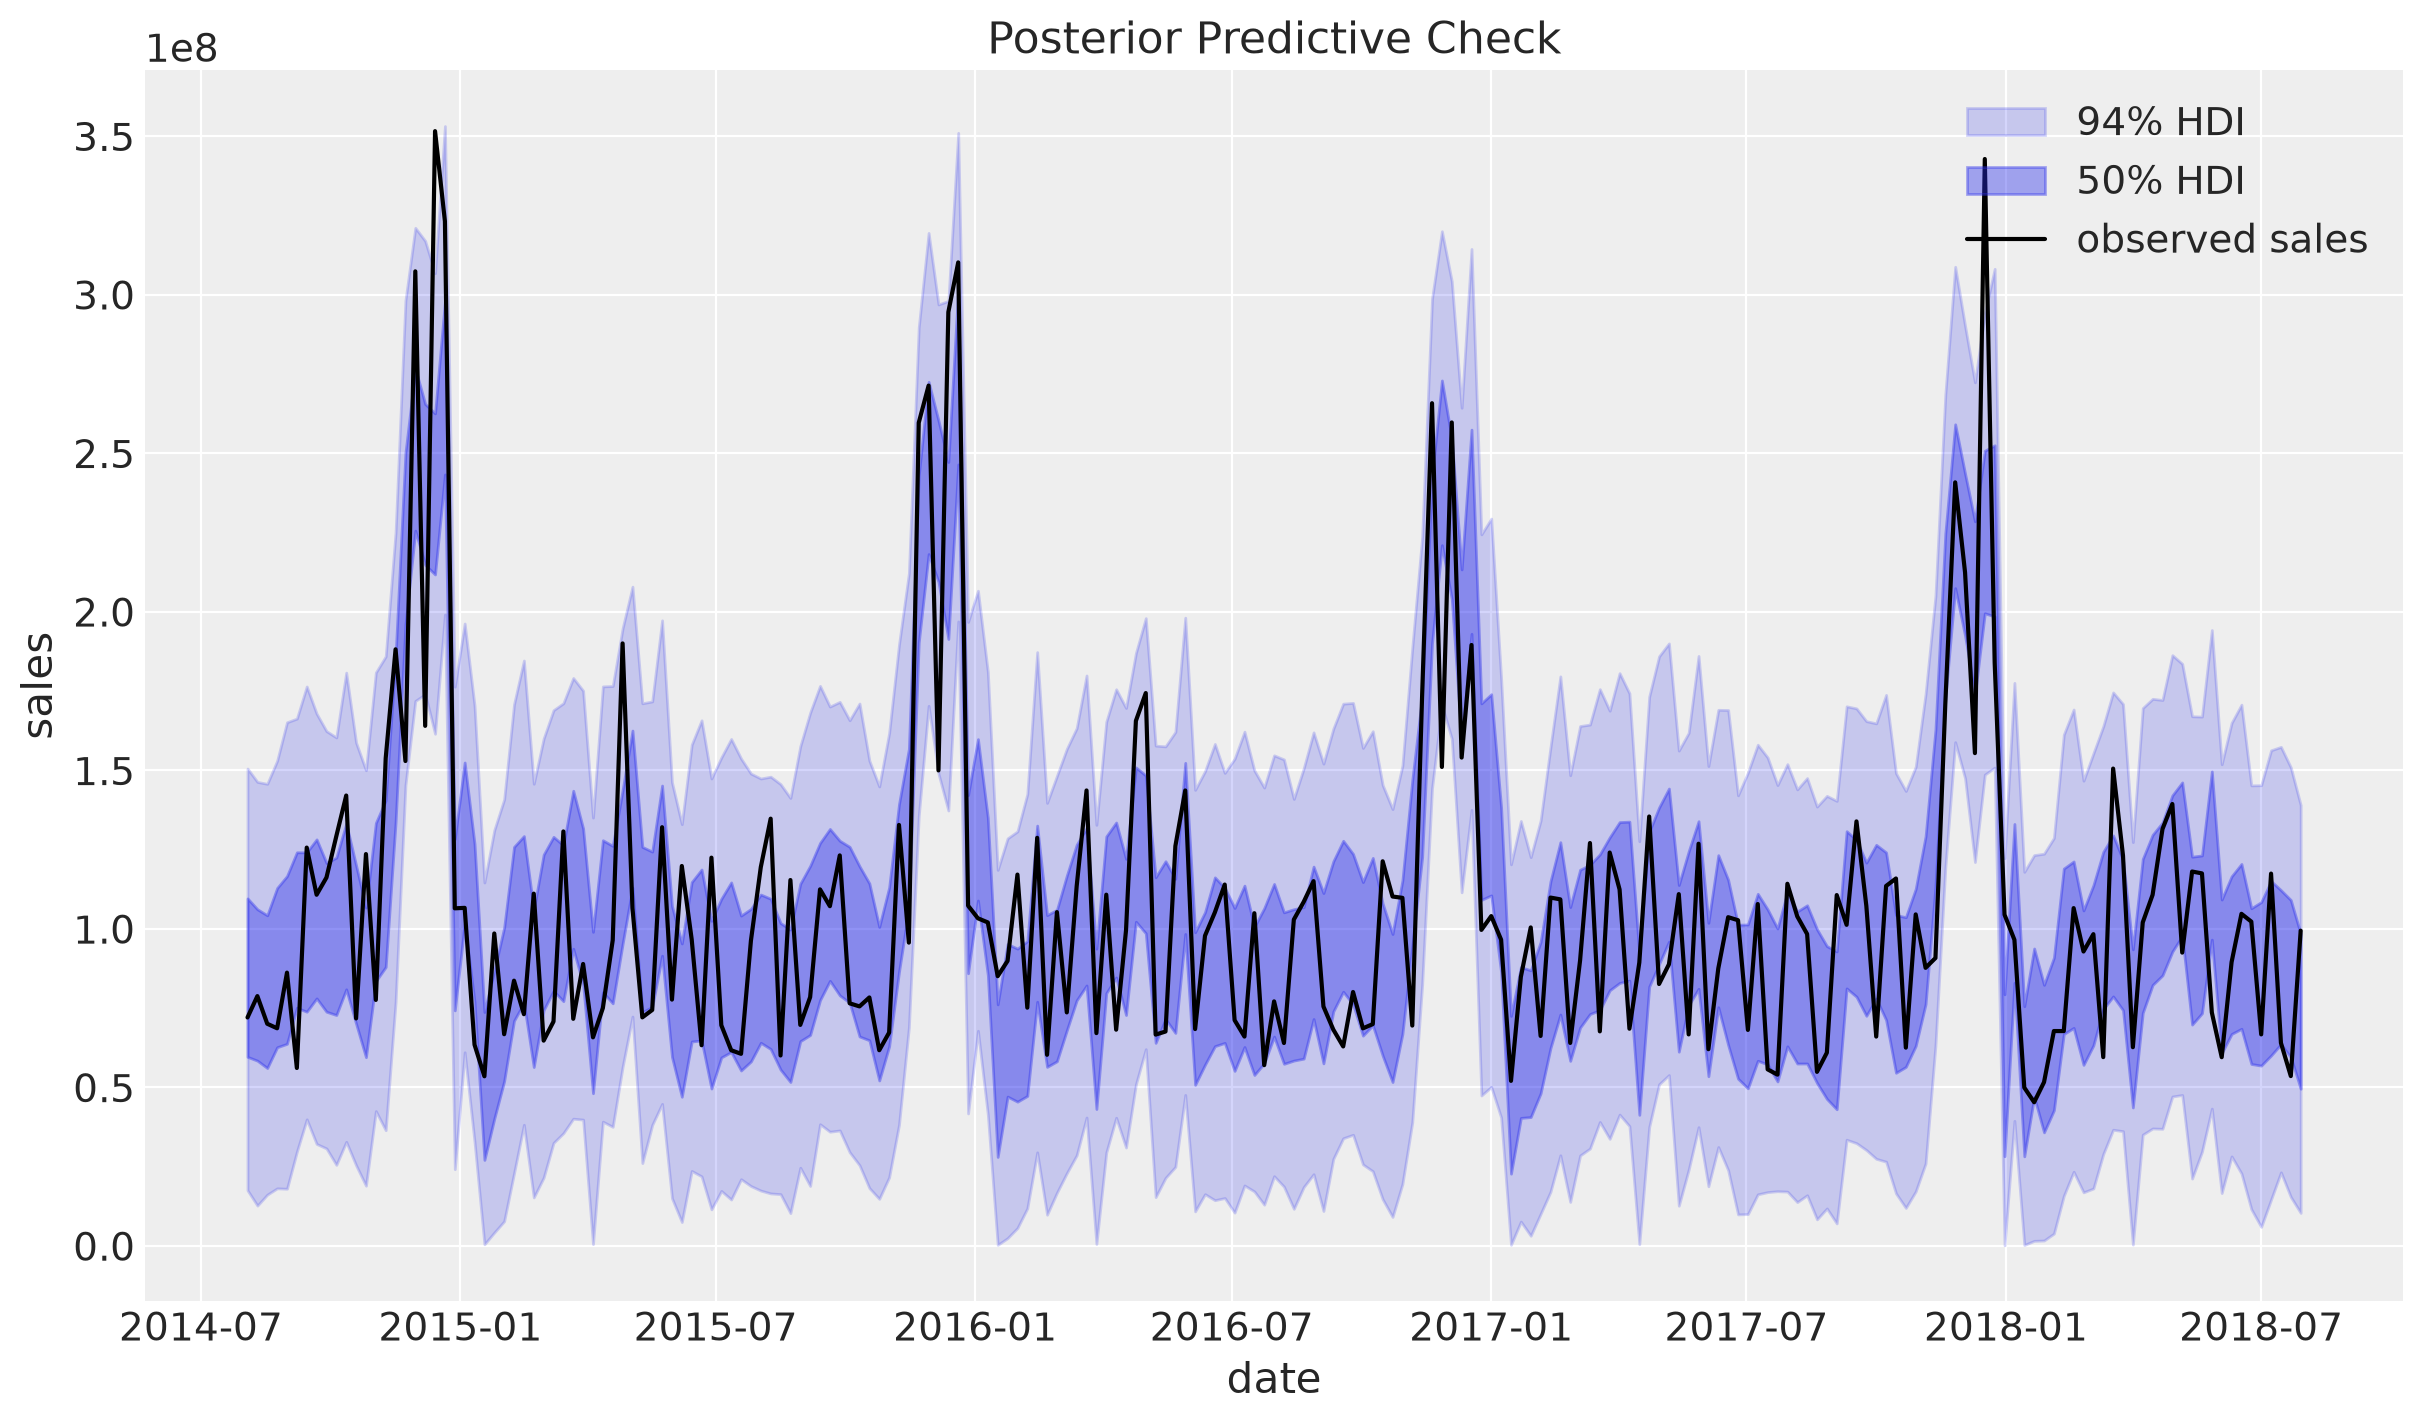

In [31]:
fig, ax = plt.subplots()
post_y = mmm.idata["posterior_predictive"]["y_original_scale"]
for prob, alpha in [(0.94, 0.2), (0.5, 0.4)]:
    hdi = az.hdi(post_y, prob=prob)
    ax.fill_between(
        dates,
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        color="C0",
        alpha=alpha,
        label=f"{prob:.0%} HDI",
    )
ax.plot(dates, y, color="black", label="observed sales")
ax.legend(loc="upper right")
ax.set(title="Posterior Predictive Check", xlabel="date", ylabel="sales");

### The Second Likelihood: SEM Impressions

This check does not exist in a flat model. The funnel model claims the latent mediator explains SEM impressions, so we can hold the model's implied impressions against the observed series.

**Business Value:** this is a check the search team can audit against their own dashboards. If the model's demand story disagreed with the impressions they see, the funnel would be wrong in a way a sales fit could never reveal.

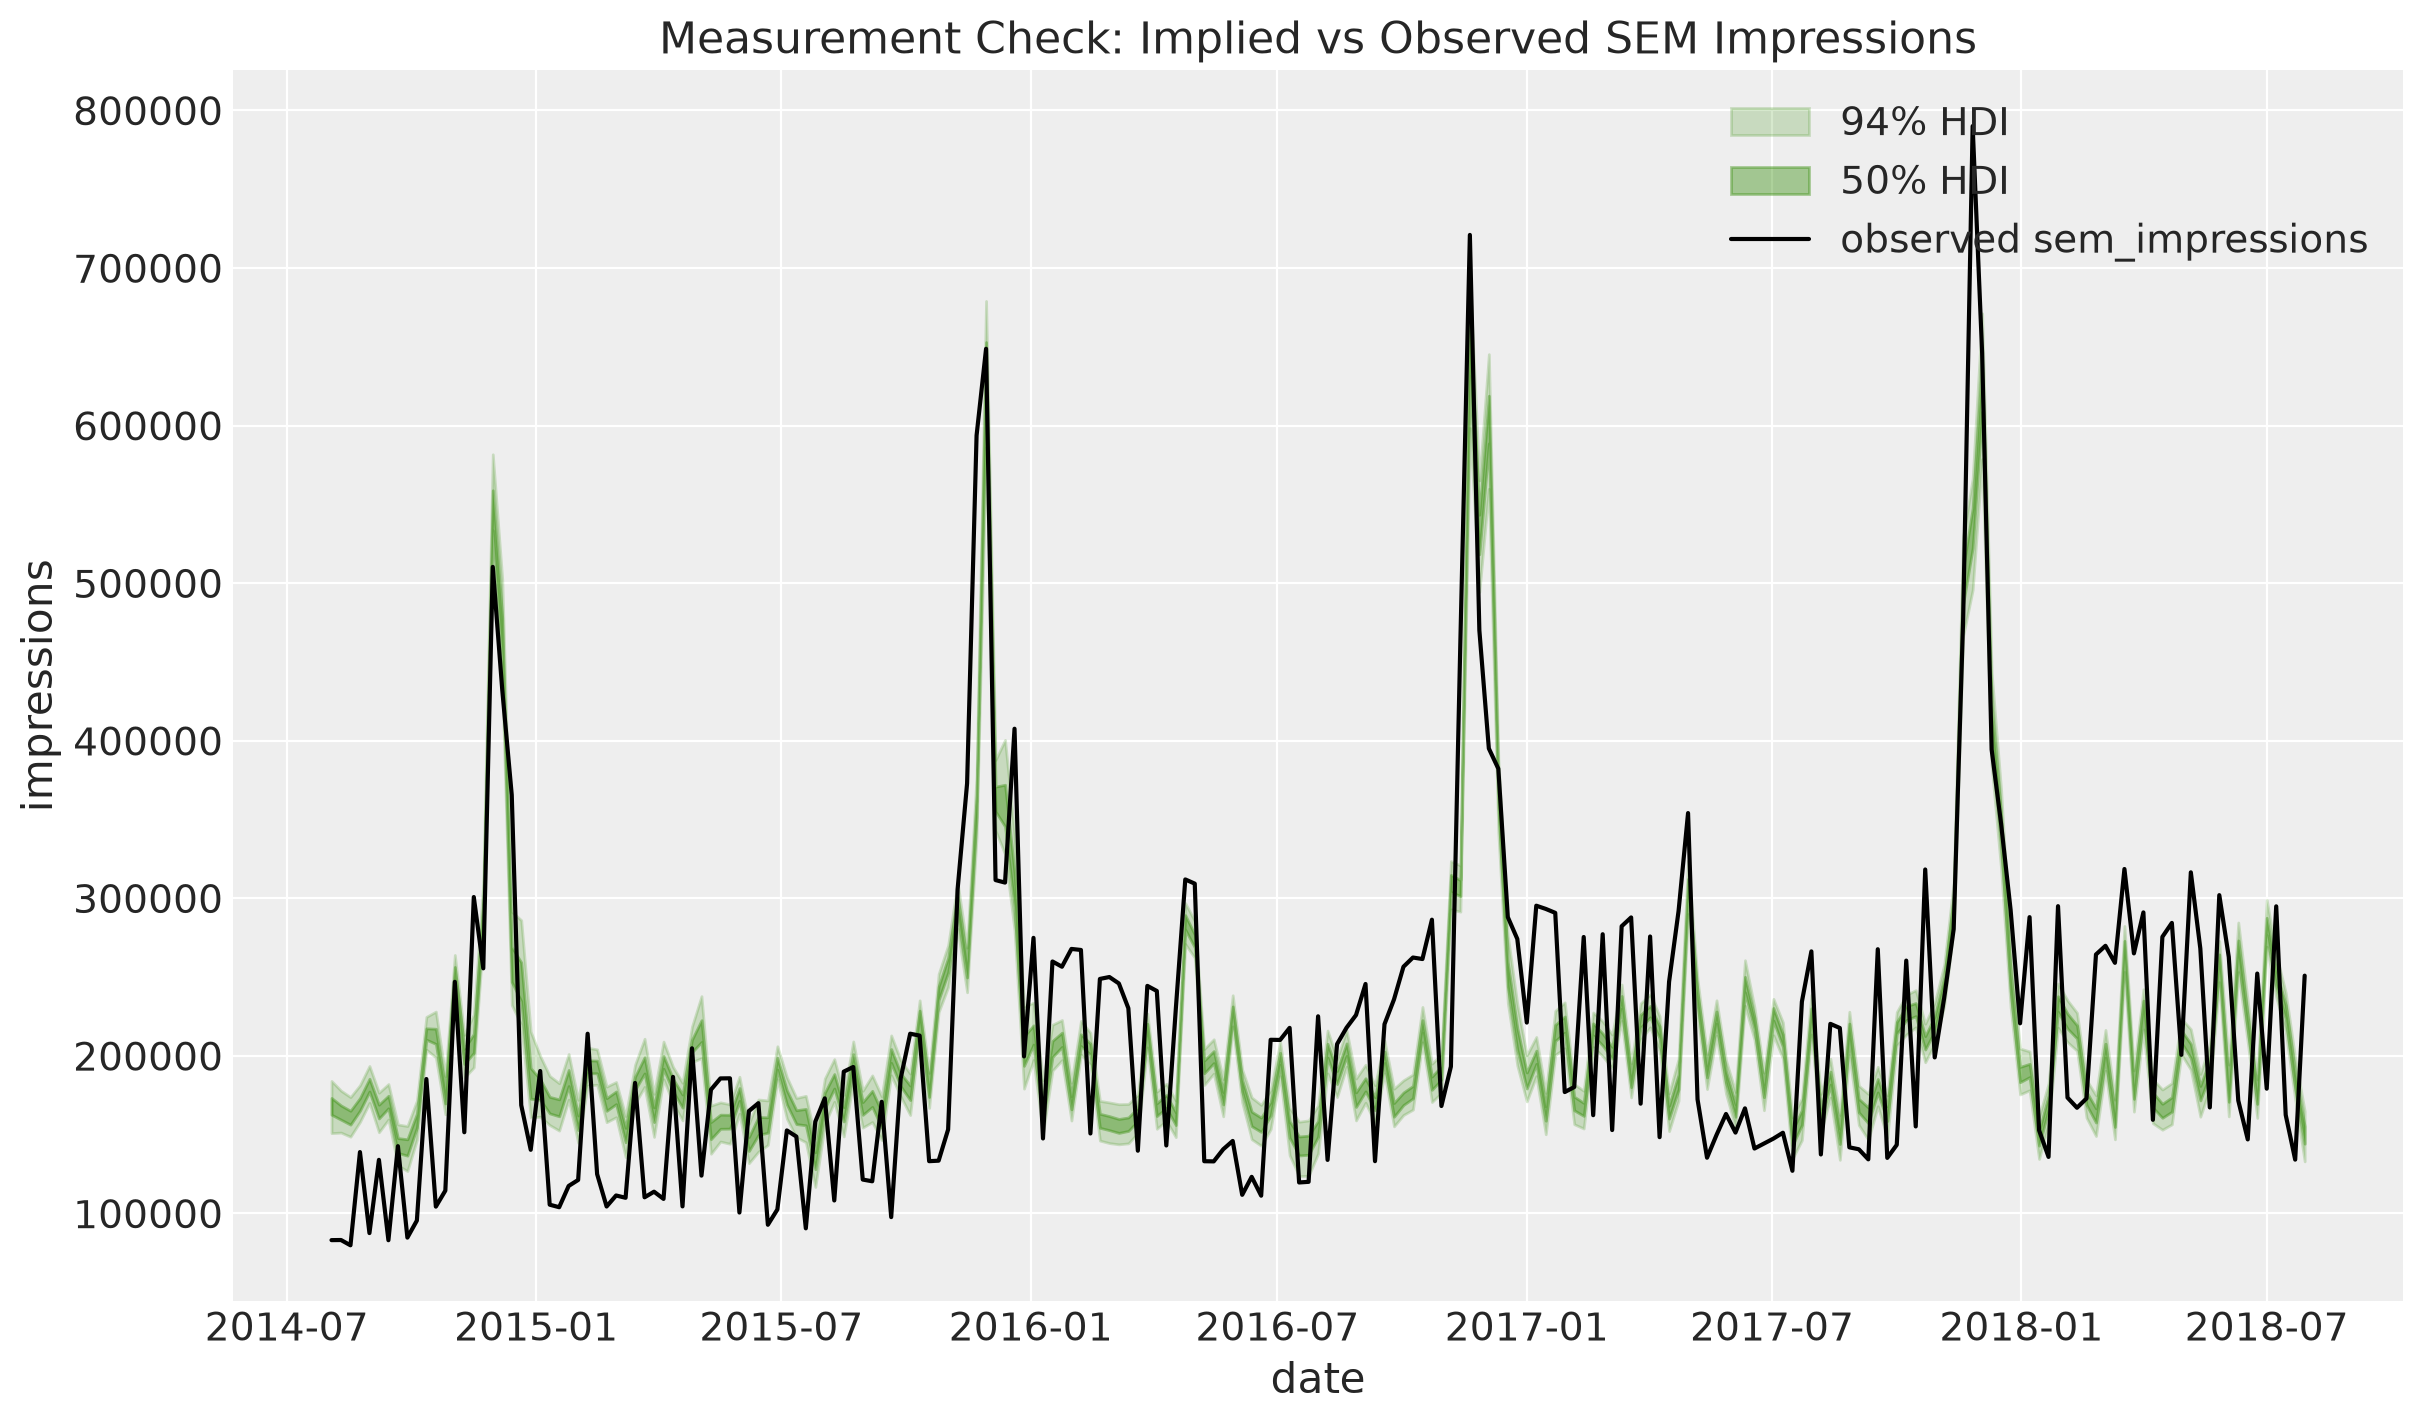

In [32]:
impressions_scale = mmm.mu_effects[0].impressions_scale
implied_impressions = impressions_scale * mmm.idata["posterior"]["funnel_mediator"]

fig, ax = plt.subplots()
for prob, alpha in [(0.94, 0.2), (0.5, 0.4)]:
    hdi = az.hdi(implied_impressions, prob=prob)
    ax.fill_between(
        dates,
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        color="C2",
        alpha=alpha,
        label=f"{prob:.0%} HDI",
    )
ax.plot(dates, X["sem_impressions"], color="black", label="observed sem_impressions")
ax.legend(loc="upper right")
ax.set(
    title="Measurement Check: Implied vs Observed SEM Impressions",
    xlabel="date",
    ylabel="impressions",
);

The implied impressions reproduce the level of the observed series and every seasonal demand peak, including their heights. The narrow bands show the implied mean of the measurement, not its noise, so the week-to-week wiggles of the observed line sit outside them by design. For an audit, the level and the peaks are what matter, and both match.

## Media Deep Dive

### Contribution Decomposition

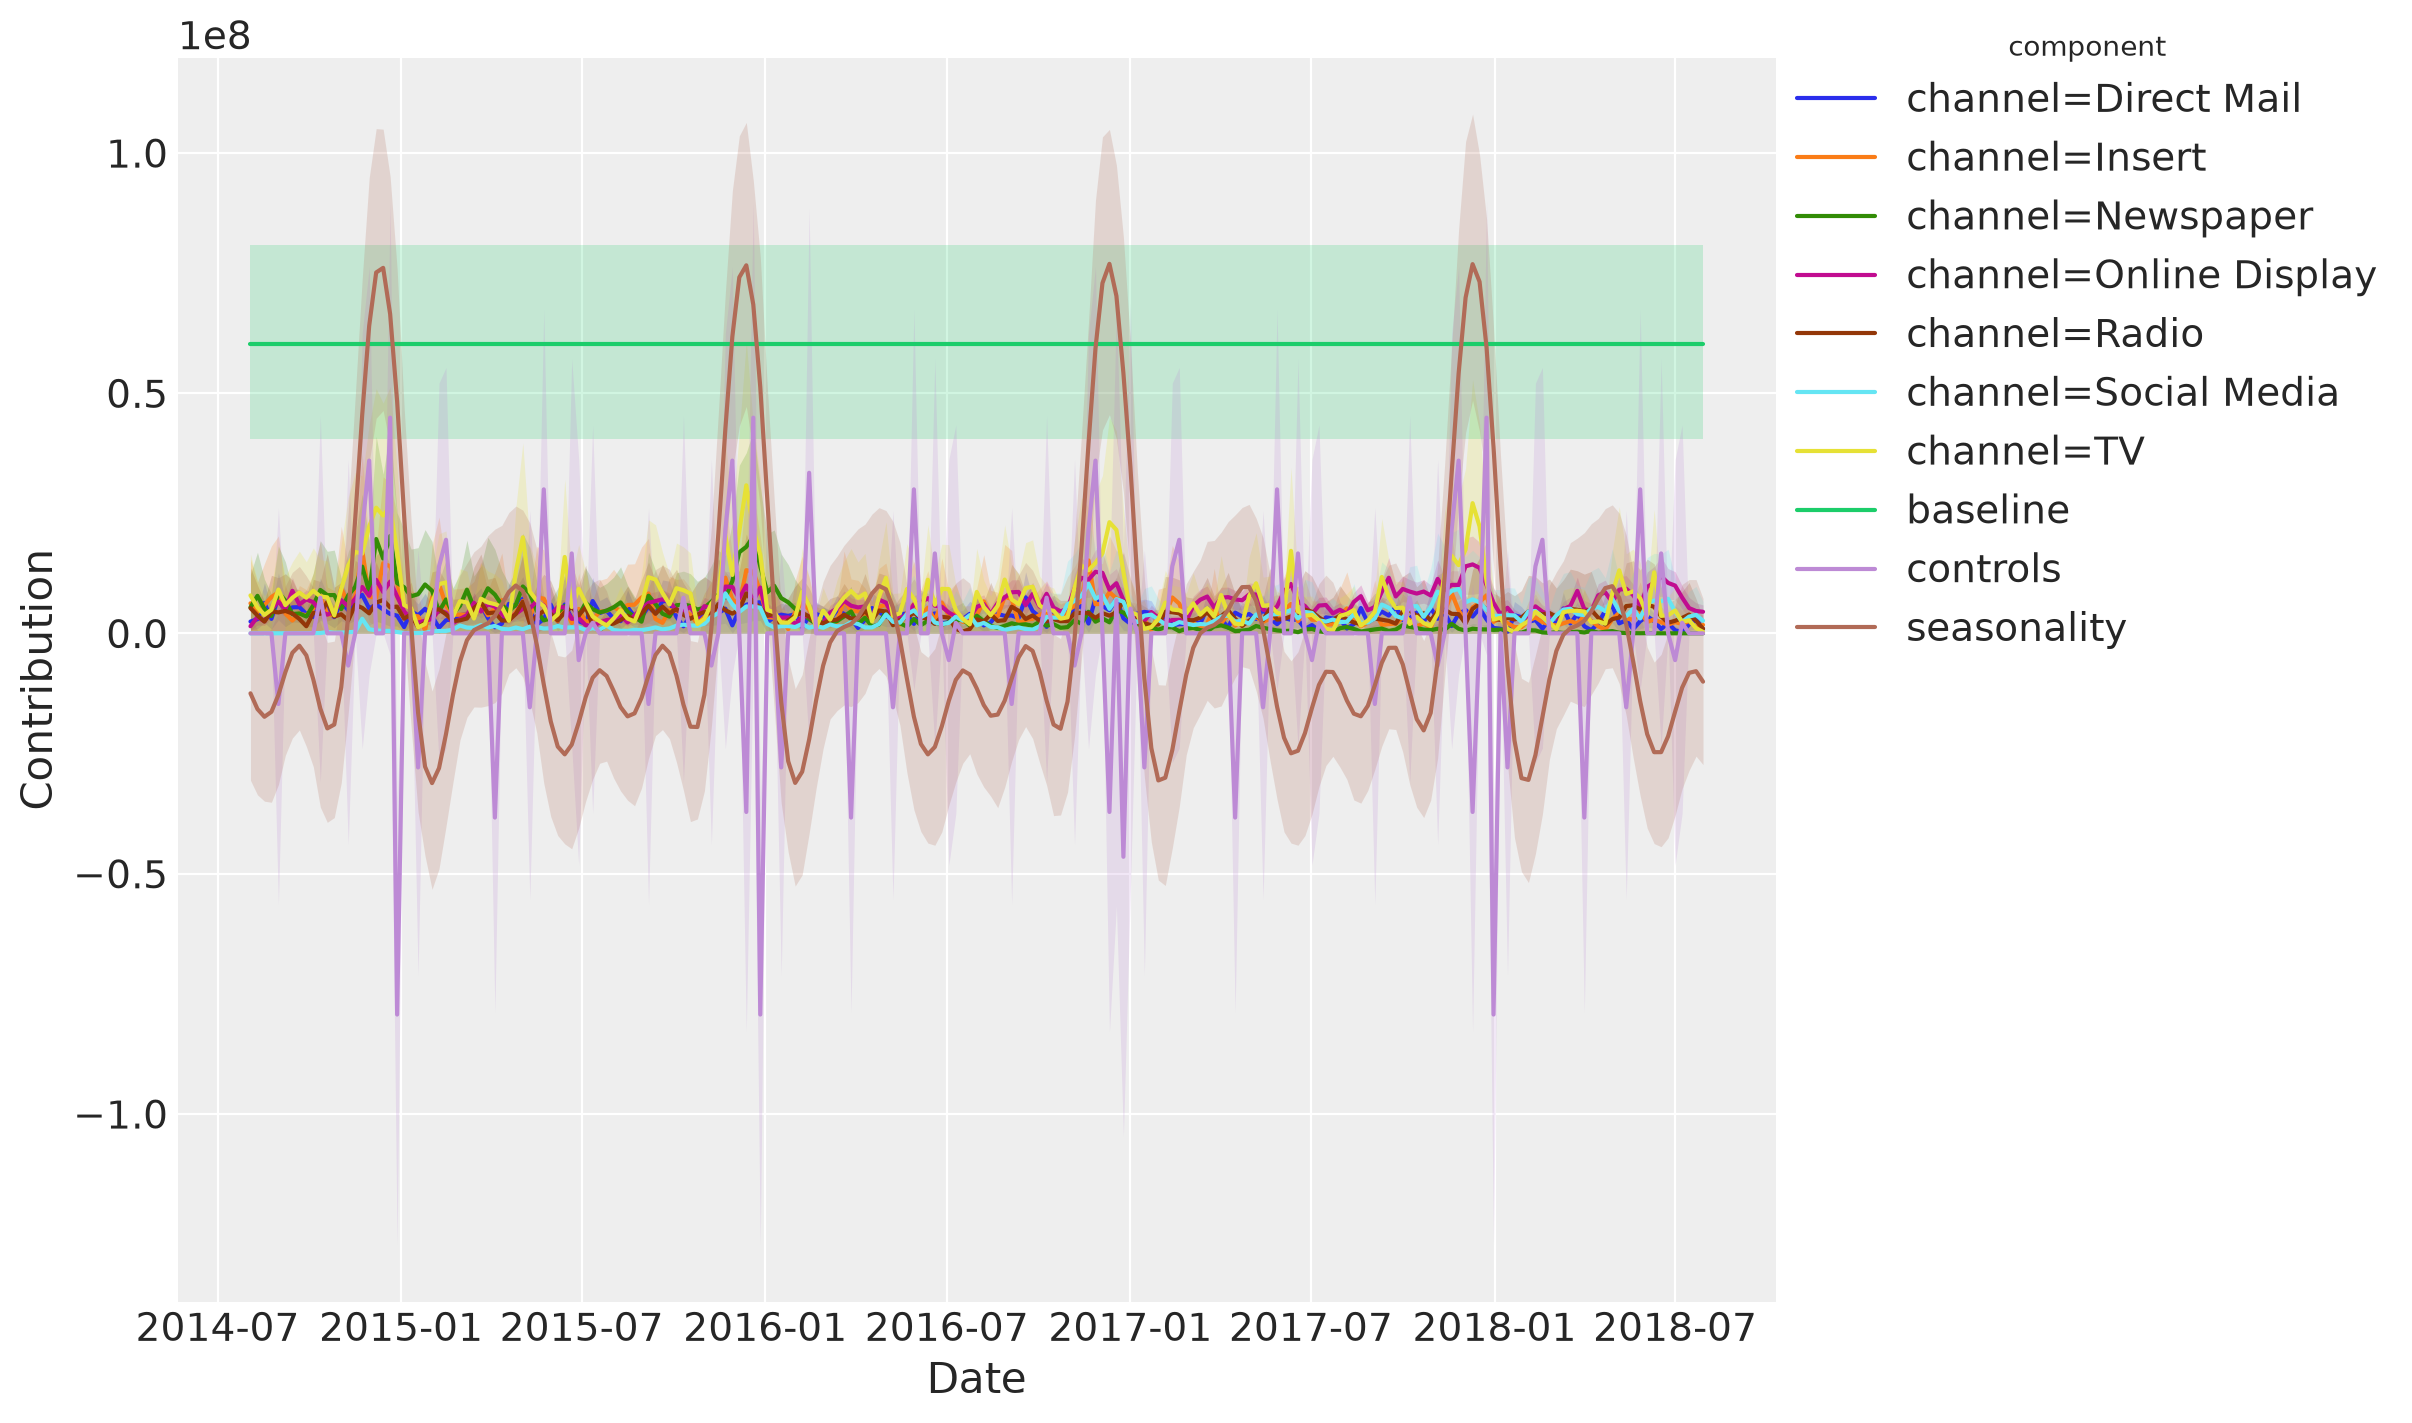

In [33]:
mmm.plot.decomposition.contributions_over_time(
    include=["channels", "controls", "baseline", "seasonality"],
    hdi_prob=0.94,
    figsize=(12, 7),
);

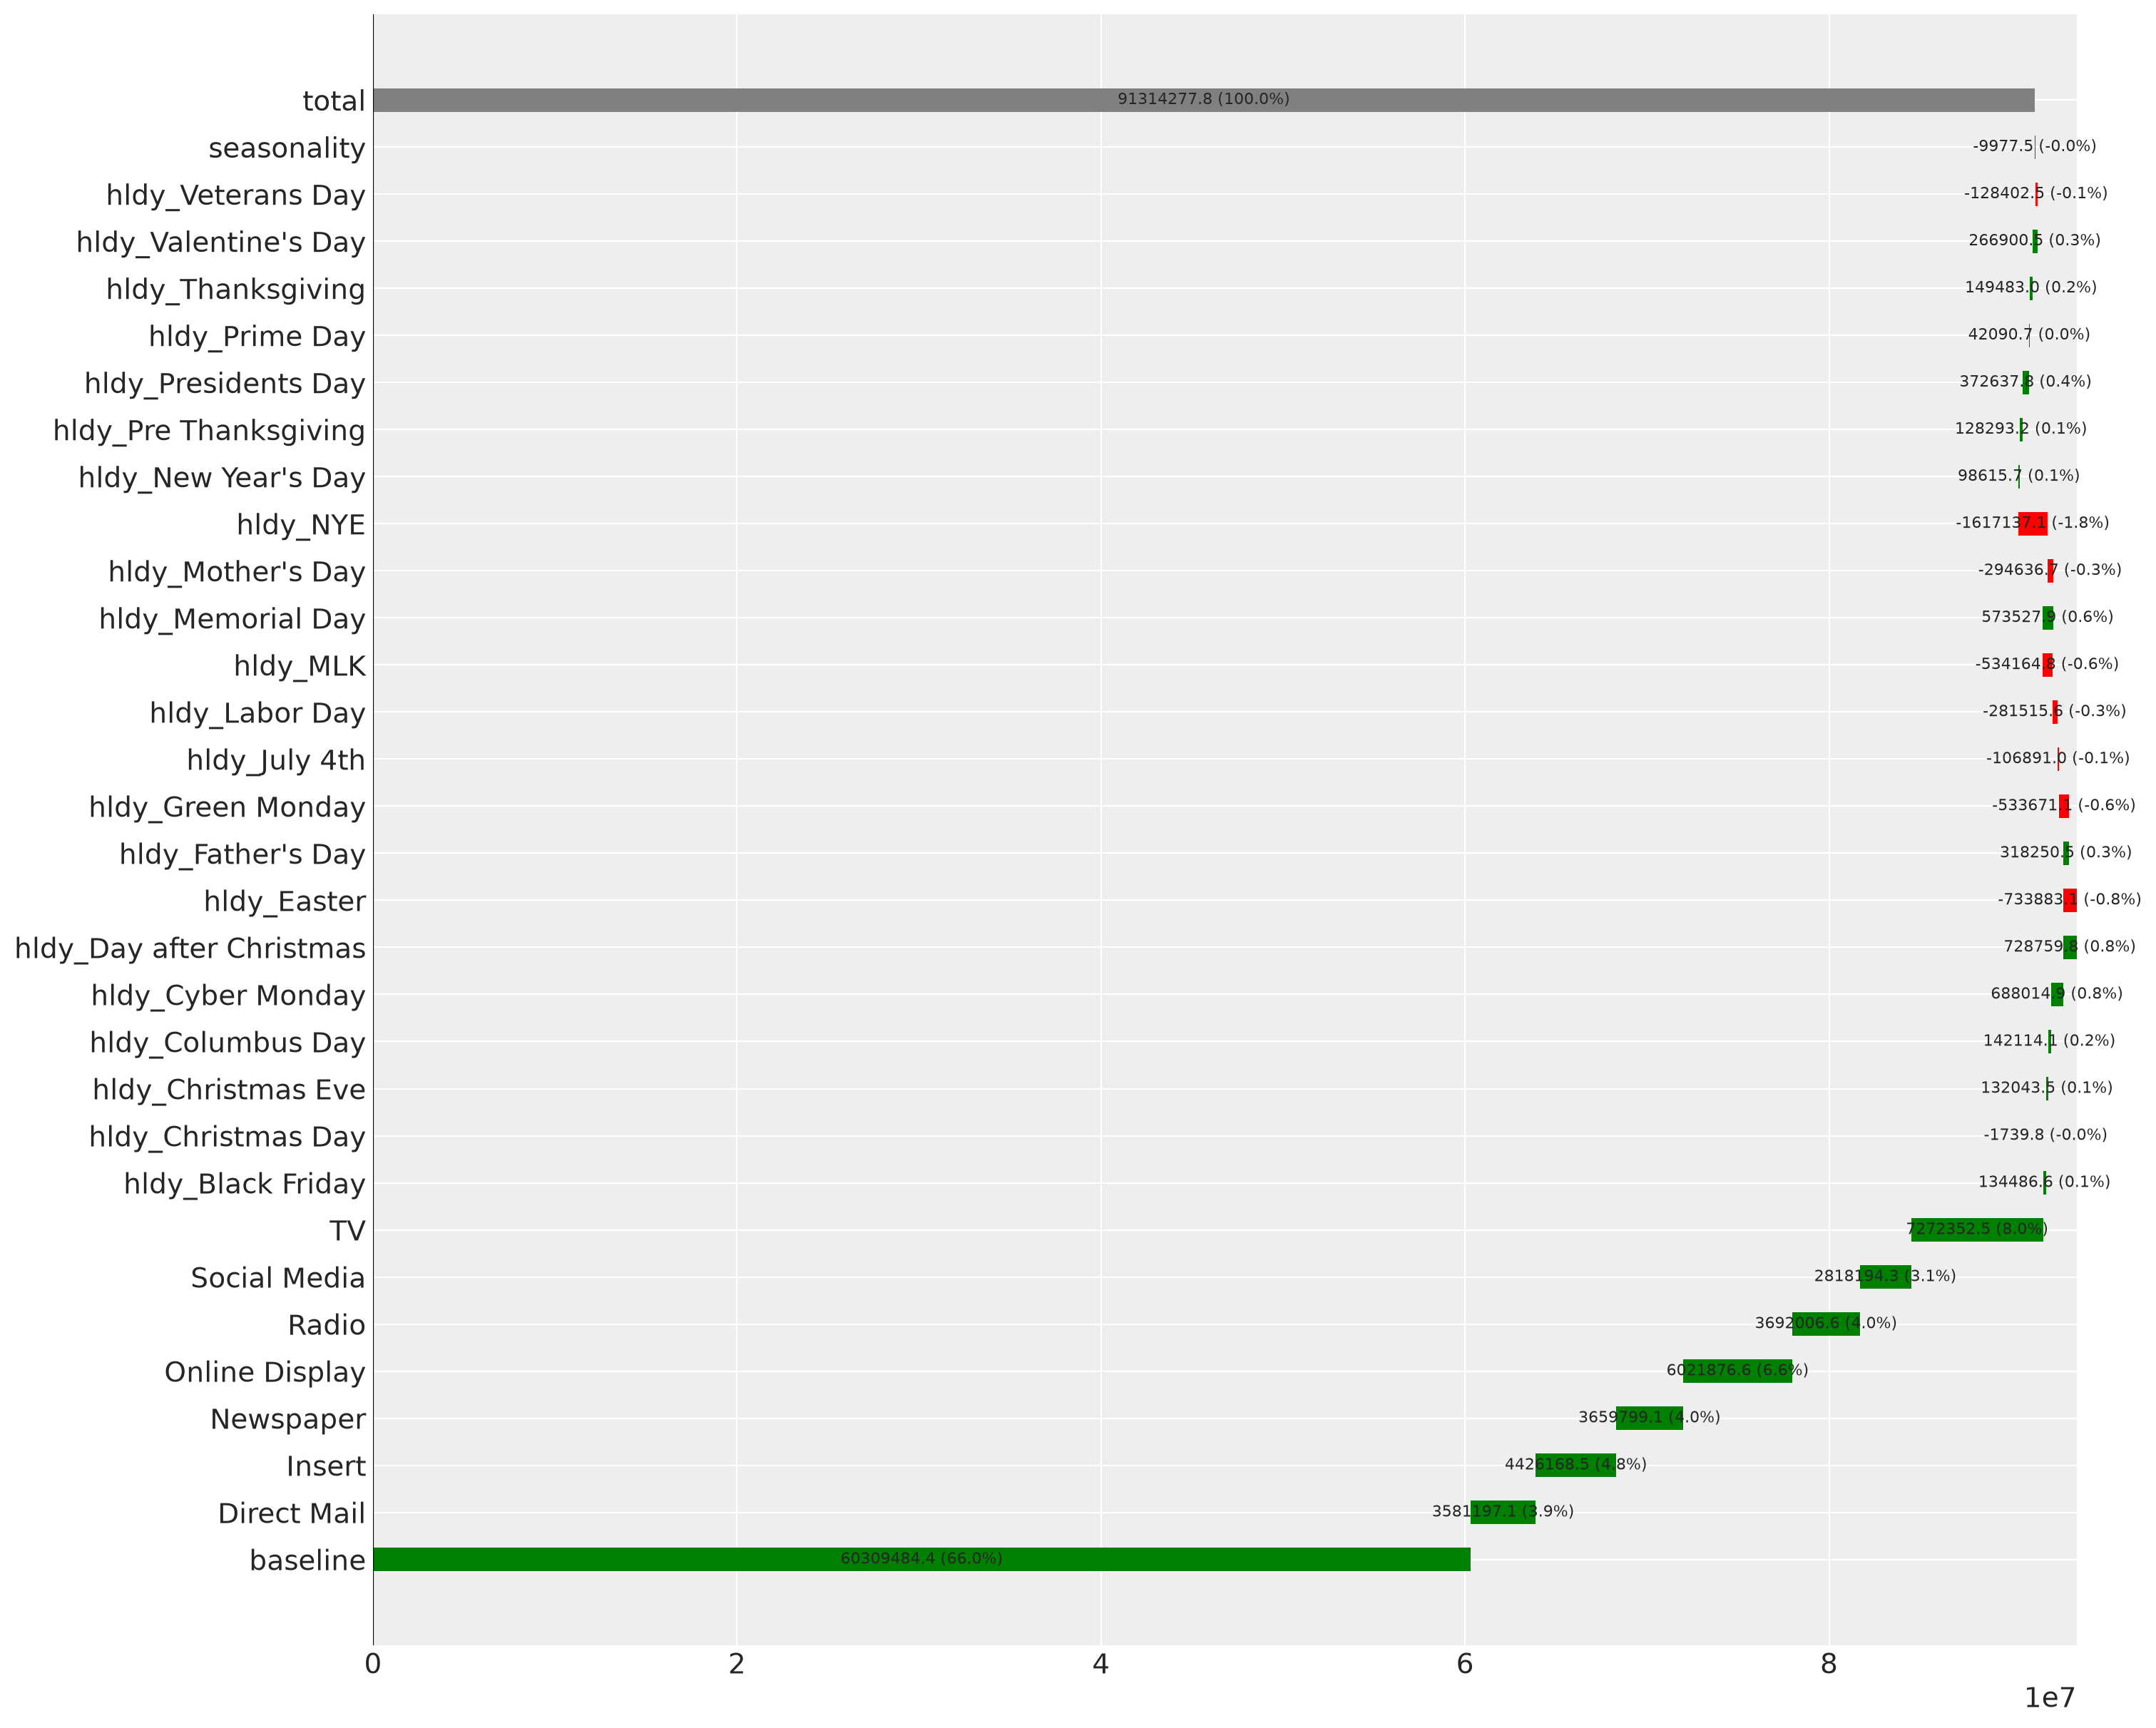

In [34]:
mmm.plot.decomposition.waterfall(figsize=(15, 12));

:::{warning}
The waterfall knows a fixed set of components and **does not show the funnel contribution**. The mediated SEM mass is missing from this chart, so the media share it displays understates the true media-driven share. The counterfactual decomposition below is the correct tool for the funnel part.
:::

The waterfall attributes 66% of sales to the baseline, against roughly 60% in the first iteration. The two charts are not comparable line by line: the mediated SEM contribution is missing from this one entirely, so part of what the first iteration would have counted as media mass is invisible here. The counterfactual decomposition below recovers it.

### Direct vs Mediated: What Do the Upper Funnel Channels Really Earn?

The stakeholder question behind the funnel: how much of the TV, Radio, and Newspaper effect arrives indirectly through SEM? The model answers it with a counterfactual: set one upper channel's spend to zero, push the data through the posterior, and read how much the mediated contribution falls. The difference is that channel's indirect effect.

In [35]:
uplift_var_names = [
    "y_original_scale",
    "channel_contribution_original_scale",
    "funnel_effect_contribution_original_scale",
]


def sample_plan(frame: pd.DataFrame) -> xr.Dataset:
    """Posterior predictive pass for a spend plan (DataFrame with funnel columns)."""
    return mmm.sample_posterior_predictive(
        frame,
        var_names=uplift_var_names,
        combined=False,
        extend_idata=False,
        progressbar=False,
        random_seed=rng,
    )


pp_base = sample_plan(X)

indirect_contributions = {}
direct_deltas = {}
for channel in upper_channels:
    X_zero = X.copy()
    X_zero[channel] = 0.0
    pp_zero = sample_plan(X_zero)
    indirect = (
        pp_base["funnel_effect_contribution_original_scale"]
        - pp_zero["funnel_effect_contribution_original_scale"]
    )
    if float(indirect.mean()) <= 0:
        raise RuntimeError(
            f"zeroing {channel} did not reduce the mediated contribution"
        )
    indirect_contributions[channel] = indirect
    direct_deltas[channel] = pp_base["channel_contribution_original_scale"].sel(
        channel=channel
    ).sum("date") - pp_zero["channel_contribution_original_scale"].sel(
        channel=channel
    ).sum("date")

indirect_da = xr.concat(
    list(indirect_contributions.values()),
    dim=pd.Index(upper_channels, name="channel"),
)

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [y]


/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/tensor/type.py:684: RuntimeWarning: invalid value encountered in divide
  f"numpy allclose failed for abs_err {np.max(abs(a - b))} and rel_err {np.max(abs(a - b) / (abs(a) + abs(b)))}"
/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [y]


/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/tensor/type.py:684: RuntimeWarning: invalid value encountered in divide
  f"numpy allclose failed for abs_err {np.max(abs(a - b))} and rel_err {np.max(abs(a - b) / (abs(a) + abs(b)))}"
/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [y]


/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/tensor/type.py:684: RuntimeWarning: invalid value encountered in divide
  f"numpy allclose failed for abs_err {np.max(abs(a - b))} and rel_err {np.max(abs(a - b) / (abs(a) + abs(b)))}"
/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [y]


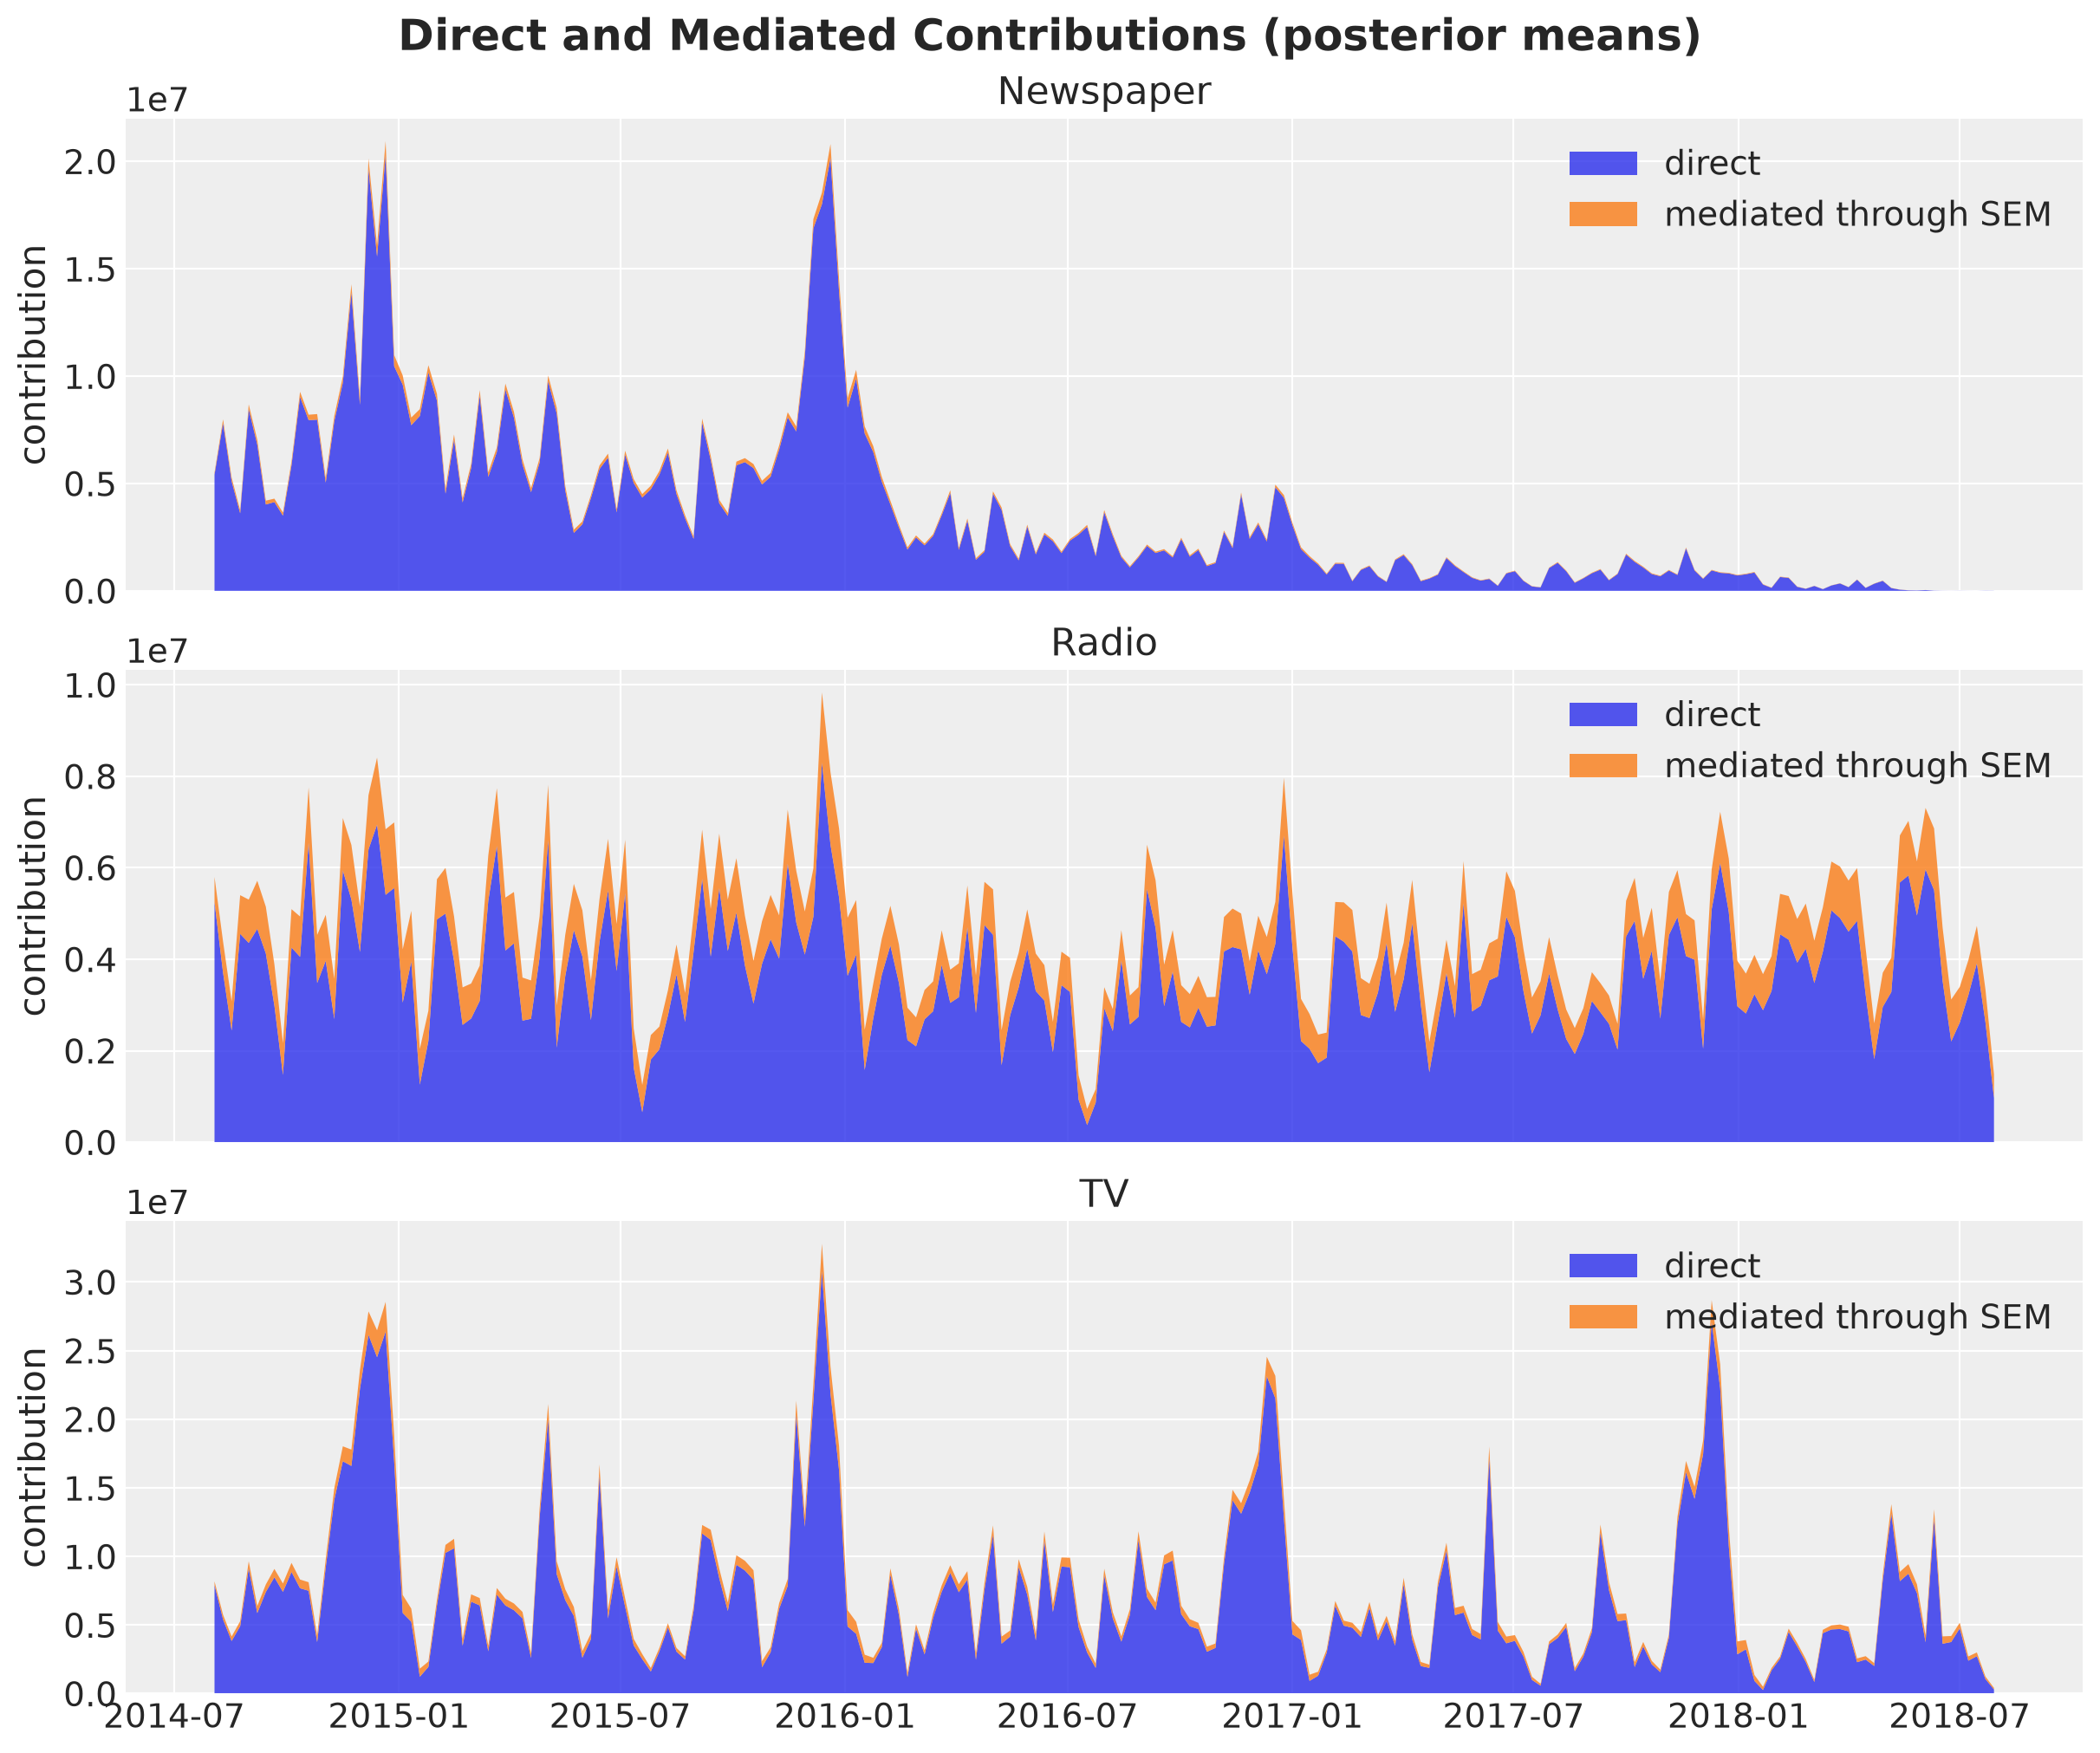

In [36]:
fig, axes = plt.subplots(
    nrows=len(upper_channels),
    ncols=1,
    figsize=(12, 10),
    sharex=True,
    layout="constrained",
)
for ax, channel in zip(axes, upper_channels, strict=True):
    direct_mean = (
        pp_base["channel_contribution_original_scale"]
        .sel(channel=channel)
        .mean(("chain", "draw"))
    )
    indirect_mean = indirect_da.sel(channel=channel).mean(("chain", "draw"))
    ax.stackplot(
        dates,
        direct_mean,
        indirect_mean,
        labels=["direct", "mediated through SEM"],
        colors=["C0", "C1"],
        alpha=0.8,
    )
    ax.legend(loc="upper right")
    ax.set(title=channel, ylabel="contribution")
fig.suptitle(
    "Direct and Mediated Contributions (posterior means)",
    fontsize=18,
    fontweight="bold",
);

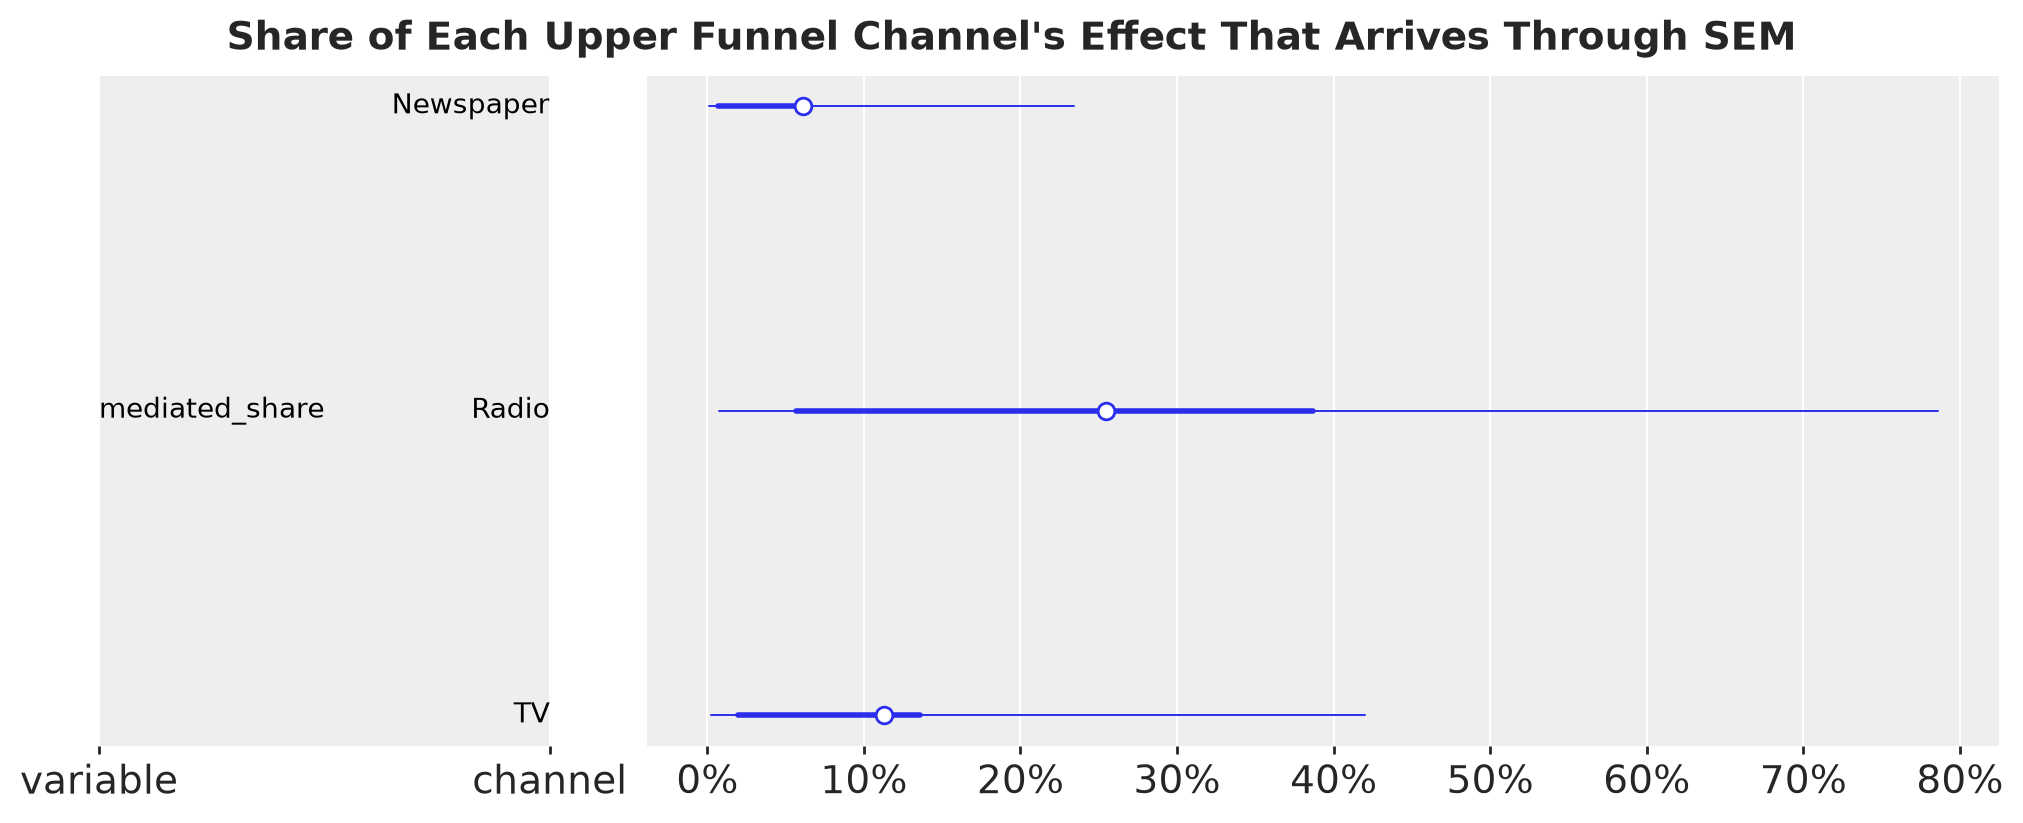

In [37]:
direct_total = (
    pp_base["channel_contribution_original_scale"]
    .sel(channel=upper_channels)
    .sum("date")
)
mediated_share = indirect_da.sum("date") / (direct_total + indirect_da.sum("date"))

pc = azp.plot_forest(
    xr.Dataset({"mediated_share": mediated_share}),
    combined=True,
    figure_kwargs={"figsize": (10, 4)},
)
fig = pc.viz["/"]["figure"].values.item()
value_ax = max(fig.axes, key=lambda a: len(a.lines) + len(a.collections))
value_ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
fig.suptitle(
    "Share of Each Upper Funnel Channel's Effect That Arrives Through SEM",
    fontsize=14,
    fontweight="bold",
);

In [38]:
mediated_share_hdi = az.hdi(mediated_share, prob=0.94)
mediated_share_summary = xr.Dataset(
    {
        "mean": mediated_share.mean(("chain", "draw")),
        "hdi_low": mediated_share_hdi.sel(ci_bound="lower", drop=True),
        "hdi_high": mediated_share_hdi.sel(ci_bound="upper", drop=True),
    }
).to_dataframe()
mediated_share_summary.round(2)

,mean,hdi_low,hdi_high
channel,,,
Newspaper,0.06,0.0,0.23
Radio,0.25,0.0,0.77
TV,0.11,0.0,0.40


The point estimates put the mediated share at 6% for Newspaper, 11% for TV, and 25% for Radio, with wide 94% intervals whose lower ends reach zero. Read this as direction rather than precision: the model sees a positive mediated path, but four years of observational data cannot pin down how much of each upper channel's effect travels through it. This is exactly the quantity a future upper funnel lift test should target. For the budget decision the direction is what matters: cutting an upper channel loses its direct sales plus a share of the demand SEM harvests.

### Return on Ad Spend, Funnel-Aware

{meth}`~pymc_marketing.mmm.incrementality.Incrementality.contribution_over_spend` runs the same counterfactual per channel, with two upgrades over the hand-rolled version: it widens the evaluation window so adstock carryover past the last observation is counted, and it does so for both paths because the funnel effect declared its reach through `incrementality_spec`. For the four direct-only channels this is the same quantity the first iteration reported. For TV, Radio, and Newspaper it is total ROAS: direct plus mediated.

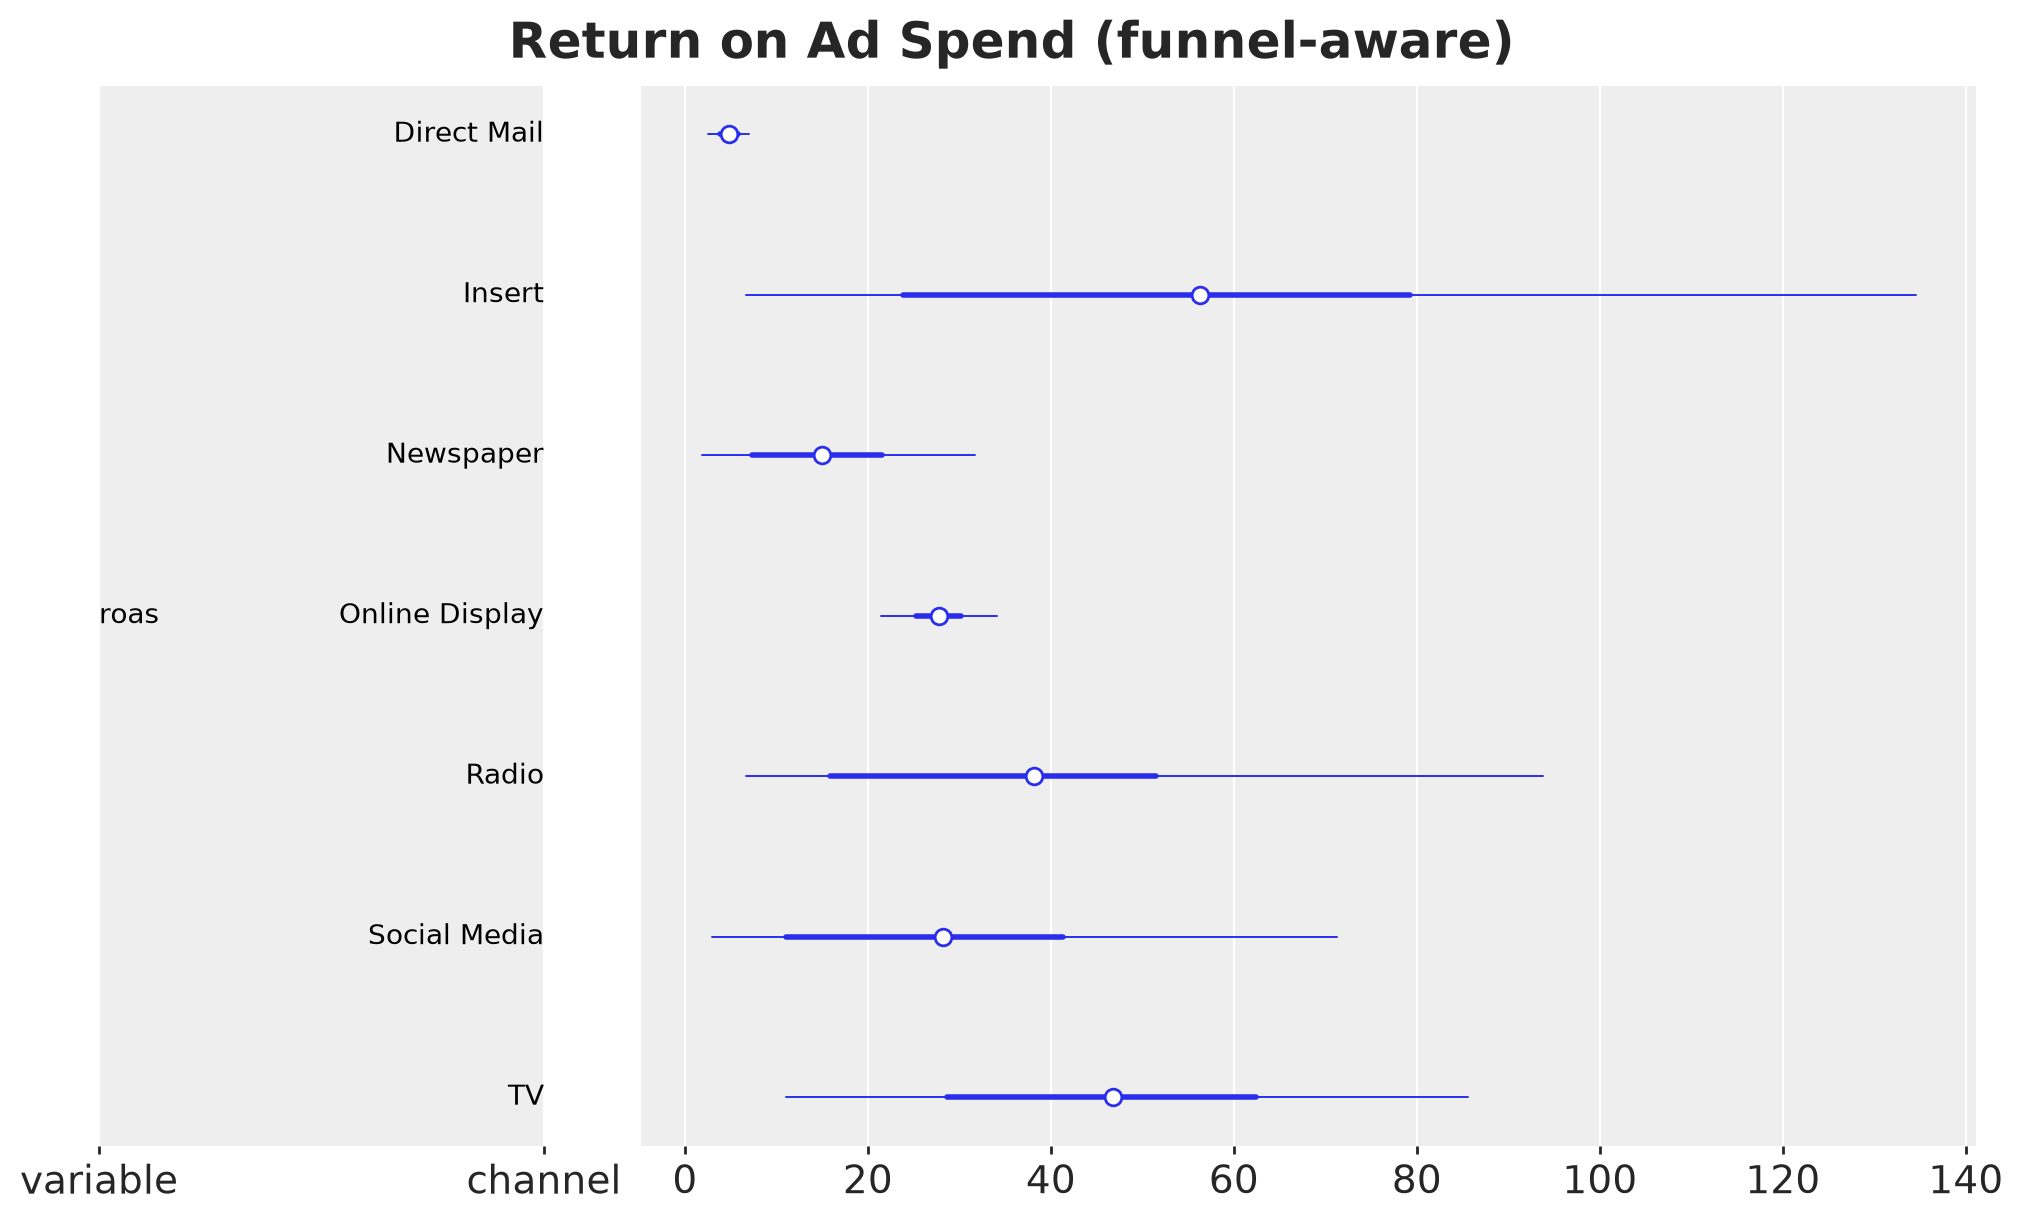

In [39]:
roas = mmm.incrementality.contribution_over_spend(
    frequency="all_time", num_samples=500, random_state=rng
).rename("roas")

pc = azp.plot_forest(
    xr.Dataset({"roas": roas}), combined=True, figure_kwargs={"figsize": (10, 6)}
)
fig = pc.viz["/"]["figure"].values.item()
fig.suptitle("Return on Ad Spend (funnel-aware)", fontsize=18, fontweight="bold");

In [40]:
roas_sample_dims = [dim for dim in roas.dims if dim != "channel"]
roas_summary = xr.Dataset(
    {
        "mean": roas.mean(roas_sample_dims),
        "q3%": roas.quantile(0.03, dim=roas_sample_dims).drop_vars("quantile"),
        "q97%": roas.quantile(0.97, dim=roas_sample_dims).drop_vars("quantile"),
    }
).to_dataframe()
roas_summary.round(2)

,mean,q3%,q97%
channel,,,
Direct Mail,4.82,2.23,7.43
Insert,56.32,4.86,148.60
Newspaper,15.02,0.97,35.33
Online Display,27.78,20.30,35.64
Radio,38.20,3.65,110.70
Social Media,28.21,1.89,76.54
TV,46.77,8.44,97.58


In [41]:
comparison_rows = []
for channel in upper_channels:
    hand_rolled = float(
        (
            (direct_deltas[channel] + indirect_da.sel(channel=channel).sum("date"))
            / X[channel].sum()
        ).mean(("chain", "draw"))
    )
    comparison_rows.append(
        {
            "channel": channel,
            "incrementality module": float(roas.sel(channel=channel).mean()),
            "hand-rolled counterfactual": hand_rolled,
        }
    )
pd.DataFrame(comparison_rows).round(2)

,channel,incrementality module,hand-rolled counterfactual
0,Newspaper,15.02,14.86
1,Radio,38.20,37.32
2,TV,46.77,46.77


The two computations agree closely; small differences come from the module's wider evaluation window (it counts the carryover tail past the last observation) and from posterior subsampling. This consistency check says the built-in ROAS is doing exactly what the explicit counterfactual does.

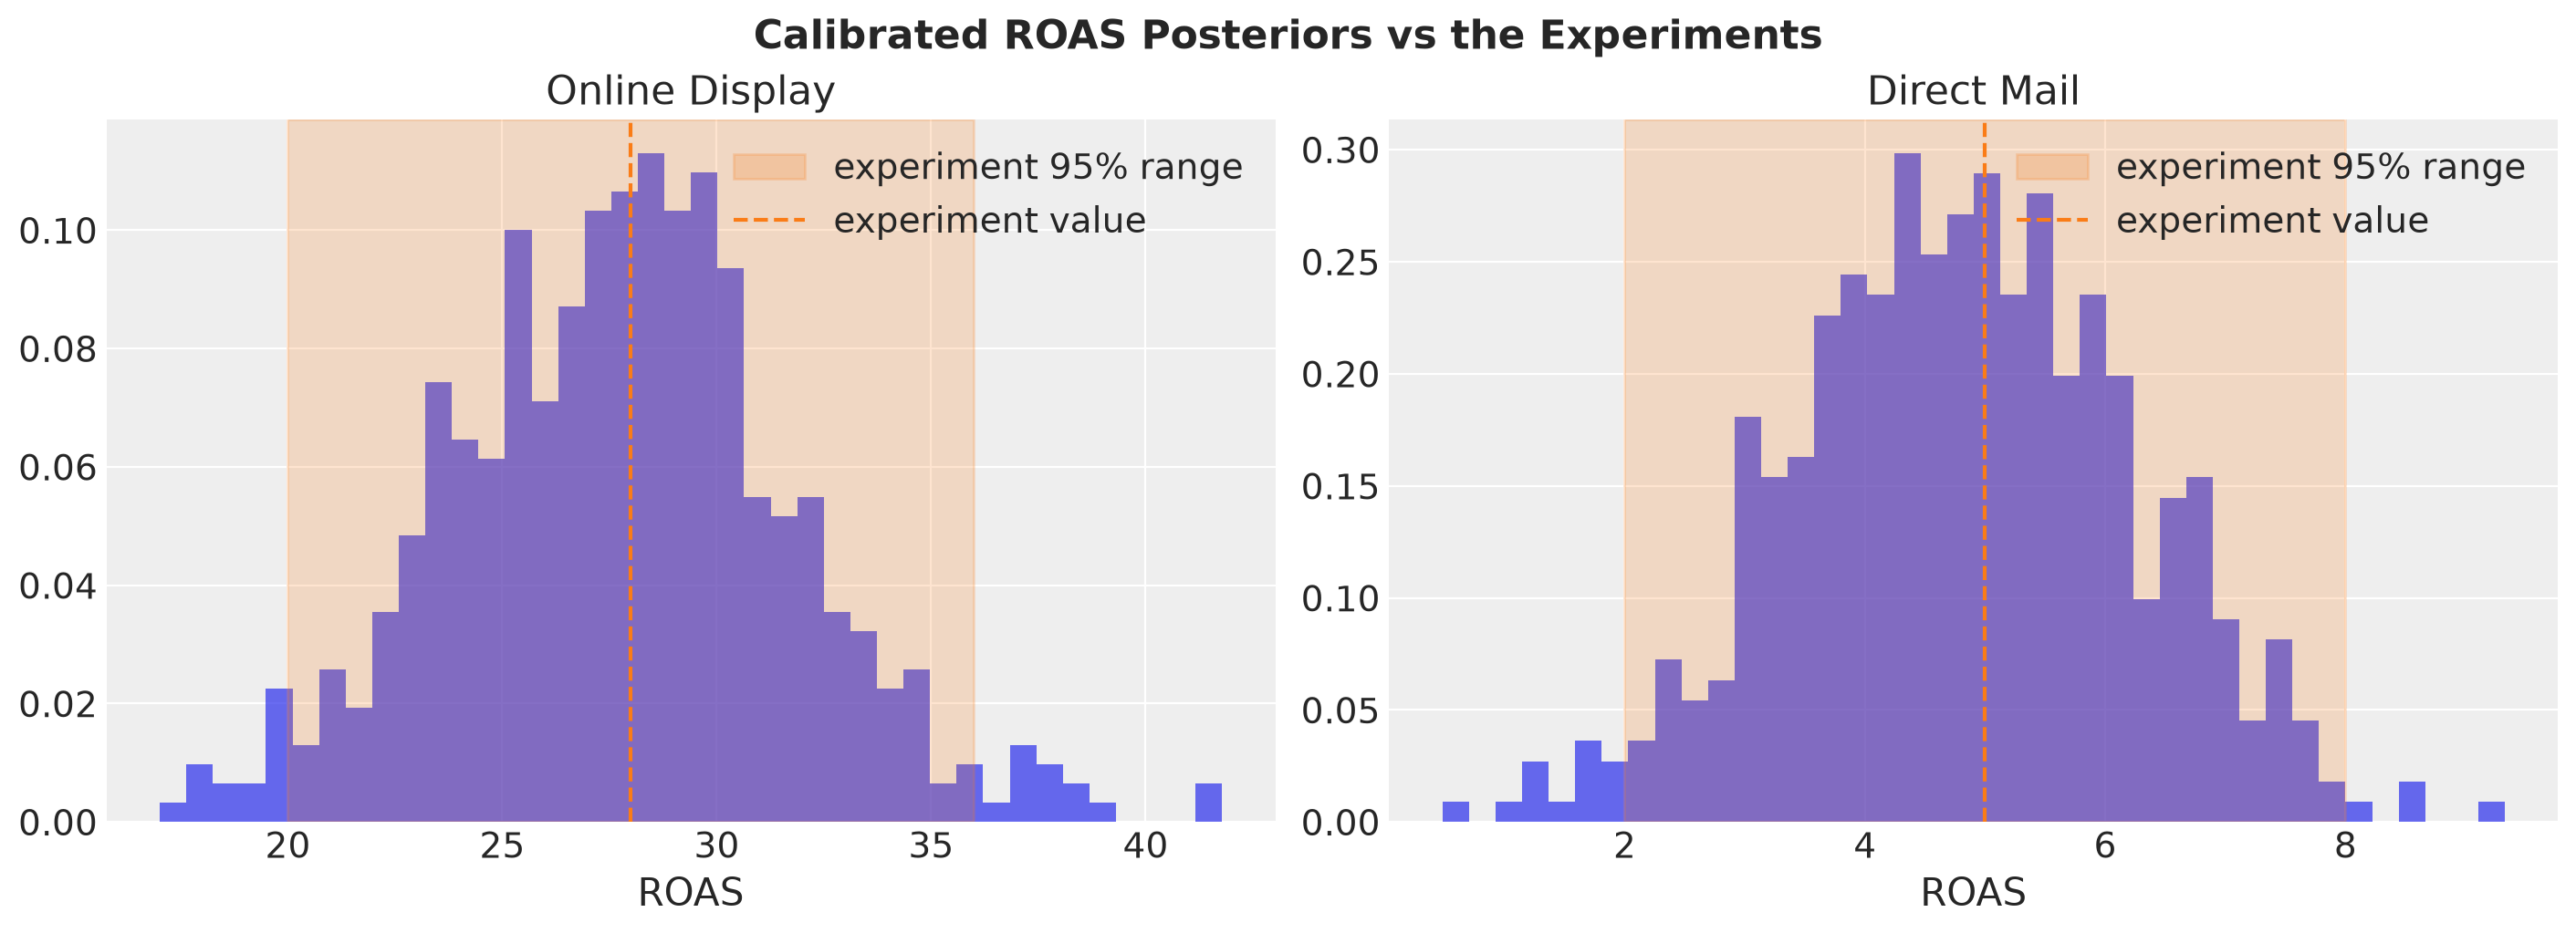

In [42]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), layout="constrained")
for ax, (channel, experiment) in zip(axes, roas_experiments.items(), strict=True):
    samples = roas.sel(channel=channel).values.ravel()
    ax.hist(samples, bins=40, color="C0", alpha=0.7, density=True)
    lower = experiment["roas"] - 1.96 * experiment["sigma"]
    upper = experiment["roas"] + 1.96 * experiment["sigma"]
    ax.axvspan(lower, upper, color="C1", alpha=0.2, label="experiment 95% range")
    ax.axvline(experiment["roas"], color="C1", linestyle="--", label="experiment value")
    ax.legend(loc="upper right")
    ax.set(title=channel, xlabel="ROAS")
fig.suptitle(
    "Calibrated ROAS Posteriors vs the Experiments", fontsize=16, fontweight="bold"
);

Both calibrated posteriors sit inside their experiment ranges: Online Display has a mean of 27.8 with a 94% interval of 20.3 to 35.6, matching the reported range of 20 to 36, and Direct Mail sits at 4.8 inside its 2 to 8 range. Compare that with the uncalibrated channels, where Insert spans 4.9 to 148.6 and Radio 3.7 to 110.7. Calibration turned the two decision-critical ROAS numbers from wide bands into commitments.

**Business Value:** uncertainty reduction is what converts a recommendation into an approved budget line. The first iteration could say "Online Display looks great, but the band is wide"; this iteration can commit to a number.

## Budget Optimization for the Next Quarter

No test set exists any more, so we do what a marketing team actually does: plan the next quarter. The window is the 13 weeks after the last observation, 2018-08-05 to 2018-10-28.

Three planning choices, each stated so they can be challenged:

1. **Budget anchor.** We anchor the weekly pot and the starting plan on the **last 52 weeks** of spend. The last quarter alone would freeze Newspaper at under 400 per week (its spend collapsed recently), which is not a real decision space; the full four years would resurrect a spend regime that no longer exists.
2. **One pot, SEM included.** SEM is money, so it competes with the seven channels for the same total. The optimizer handles this through `spend_vars`: the SEM budget joins the budget sum constraint and gets optimized as a single weekly level.
3. **The objective is a choice.** The default objective prices the **direct** path only. Our model routes part of the media response through the funnel, so the correct objective is `total_response_original_scale`. We run both on the same posterior to show the choice matters; this funnel-aware optimization is a recent addition to PyMC-Marketing.

:::{note}
Requirements for optimizing a funnel model, from {ref}`mmm_funnel_mueffect_advanced`: the effect must read the model's own channel data (ours does), the objective must be named explicitly (`total_response_original_scale`), and the optimization window arithmetic must respect the effect's extra carryover (handled automatically by {meth}`~pymc_marketing.mmm.mmm.MMM.budget_optimizer` via `effective_carryover_lags`). We compile with the C linker because the default backend cannot compile the gradient of the chained adstock.
:::

In [43]:
pot_columns = [*channel_columns, "sem_spend"]
weekly_hist = X[pot_columns].tail(52).mean()
media_hist = weekly_hist[channel_columns]
sem_hist = float(weekly_hist["sem_spend"])
total_weekly_budget = float(weekly_hist.sum())
media_pot = float(media_hist.sum())

print(
    f"weekly budget pot: {total_weekly_budget:,.0f} (media {media_pot:,.0f} + SEM {sem_hist:,.0f})"
)
weekly_hist.round(0).to_frame(name="weekly spend, last 52 weeks")

weekly budget pot: 2,086,890 (media 1,364,471 + SEM 722,419)


,"weekly spend, last 52 weeks"
Direct Mail,566469.0
Insert,49379.0
Newspaper,32624.0
Online Display,281534.0
Radio,121969.0
Social Media,175997.0
TV,136500.0
sem_spend,722419.0


In [44]:
start_date, end_date = "2018-08-05", "2018-10-28"  # 13 weeks after the last observation

percentage_change = 0.5
budget_bounds = xr.DataArray(
    np.stack(
        [
            (1 - percentage_change) * media_hist.to_numpy(),
            (1 + percentage_change) * media_hist.to_numpy(),
        ],
        axis=1,
    ),
    dims=["channel", "bound"],
    coords={"channel": channel_columns, "bound": ["lower", "upper"]},
)

# The bounds above reach the media cells only. The SEM budget needs its own
# band, expressed as two scalar inequality constraints; passing any custom
# constraint replaces the default budget-sum constraint, so we re-add it.
sem_lo = (1 - percentage_change) * sem_hist
sem_hi = (1 + percentage_change) * sem_hist

sem_lower = Constraint(
    key="sem_lower",
    constraint_type="ineq",
    constraint_fun=lambda budgets, total, opt: (
        opt.optimization_variables.variable_slice("sem_spend").sum() - sem_lo
    ),
)
sem_upper = Constraint(
    key="sem_upper",
    constraint_type="ineq",
    constraint_fun=lambda budgets, total, opt: (
        sem_hi - opt.optimization_variables.variable_slice("sem_spend").sum()
    ),
)

In [45]:
CVM = {"mode": Mode(linker="cvm")}

optimizer = mmm.budget_optimizer(
    start_date=start_date,
    end_date=end_date,
    response_variable="total_response_original_scale",
    spend_vars=["sem_spend"],
    constraints=[build_default_sum_constraint("default"), sem_lower, sem_upper],
    compile_kwargs=CVM,
)

# The decision vector must reach the mediated path, or the funnel objective
# would silently price the direct path alone.
mediated_response = optimizer.extract_response_distribution(
    "funnel_effect_contribution"
)
if optimizer.optimization_variables.flat not in set(ancestors([mediated_response])):
    raise RuntimeError("the decision vector does not reach the mediated path")

x0 = {
    "channel_data": xr.DataArray(
        media_hist.to_numpy(), dims=["channel"], coords={"channel": channel_columns}
    ),
    "sem_spend": xr.DataArray(sem_hist),
}
objective_at_x0, _ = optimizer._objective_and_grad(
    optimizer.optimization_variables.pack(x0)
)

# SLSQP's ftol is an absolute precision target. Anchor it to the objective scale,
# and anchor it tightly: the response total is dominated by the baseline, so even
# large reallocation gains are a small relative change of the objective.
ftol = 1e-9 * abs(objective_at_x0)
minimize_kwargs = {"method": "SLSQP", "options": {"ftol": ftol, "maxiter": 2_000}}

result = optimizer.allocate_budget(
    total_budget=total_weekly_budget,
    budget_bounds=budget_bounds,
    x0=x0,
    minimize_kwargs=minimize_kwargs,
)

print(
    f"solver: {result.scipy_result.message} after {result.scipy_result.nit} iterations"
)
sem_allocation = float(result.spend_var_allocations["sem_spend"].sum())
np.testing.assert_allclose(
    float(result.budgets.sum()) + sem_allocation, total_weekly_budget, rtol=1e-6
)
print(
    f"funnel-aware optimum: media {float(result.budgets.sum()):,.0f} + SEM {sem_allocation:,.0f}"
)

solver: Optimization terminated successfully after 32 iterations
funnel-aware optimum: media 1,480,238 + SEM 606,652


### The Direct-Only Comparison

The same posterior, the default objective. This optimizer cannot see the mediated path, so it must not be given the SEM lever (the library refuses a spend variable the objective cannot see). It re-allocates the media pot while SEM stays at its historical level, so both plans spend the same total.

In [46]:
direct_optimizer = mmm.budget_optimizer(
    start_date=start_date,
    end_date=end_date,
    response_variable="total_media_contribution_original_scale",
    compile_kwargs=CVM,
)

x0_media = x0["channel_data"]
direct_objective_at_x0, _ = direct_optimizer._objective_and_grad(
    direct_optimizer.optimization_variables.pack(x0_media)
)

result_direct = direct_optimizer.allocate_budget(
    total_budget=media_pot,
    budget_bounds=budget_bounds,
    x0=x0_media,
    minimize_kwargs={
        "method": "SLSQP",
        "options": {"ftol": 1e-9 * abs(direct_objective_at_x0), "maxiter": 2_000},
    },
)
print(
    f"solver: {result_direct.scipy_result.message} after {result_direct.scipy_result.nit} iterations"
)
np.testing.assert_allclose(float(result_direct.budgets.sum()), media_pot, rtol=1e-6)

solver: Optimization terminated successfully after 32 iterations


Before comparing the plans, one structural check. At the historical plan, the gradient difference between the two objectives is exactly the marginal mediated response: negative (more response) for the three upper funnel channels, zero for the four direct-only channels.

In [47]:
_, grad_joint = optimizer._objective_and_grad(optimizer.optimization_variables.pack(x0))
_, grad_direct = direct_optimizer._objective_and_grad(
    direct_optimizer.optimization_variables.pack(x0_media)
)
grad_diff = grad_joint[: len(channel_columns)] - grad_direct

upper_index = [channel_columns.index(c) for c in upper_channels]
direct_index = [i for i in range(len(channel_columns)) if i not in upper_index]

if not (grad_diff[upper_index] < 0).all():
    raise RuntimeError(
        "expected a positive mediated marginal on every upper funnel cell"
    )
np.testing.assert_allclose(
    grad_diff[direct_index], 0.0, atol=np.abs(grad_joint).max() * 1e-9
)
print(
    "gradient decomposition holds: the mediated marginal sits on the upper funnel channels only"
)

gradient decomposition holds: the mediated marginal sits on the upper funnel channels only


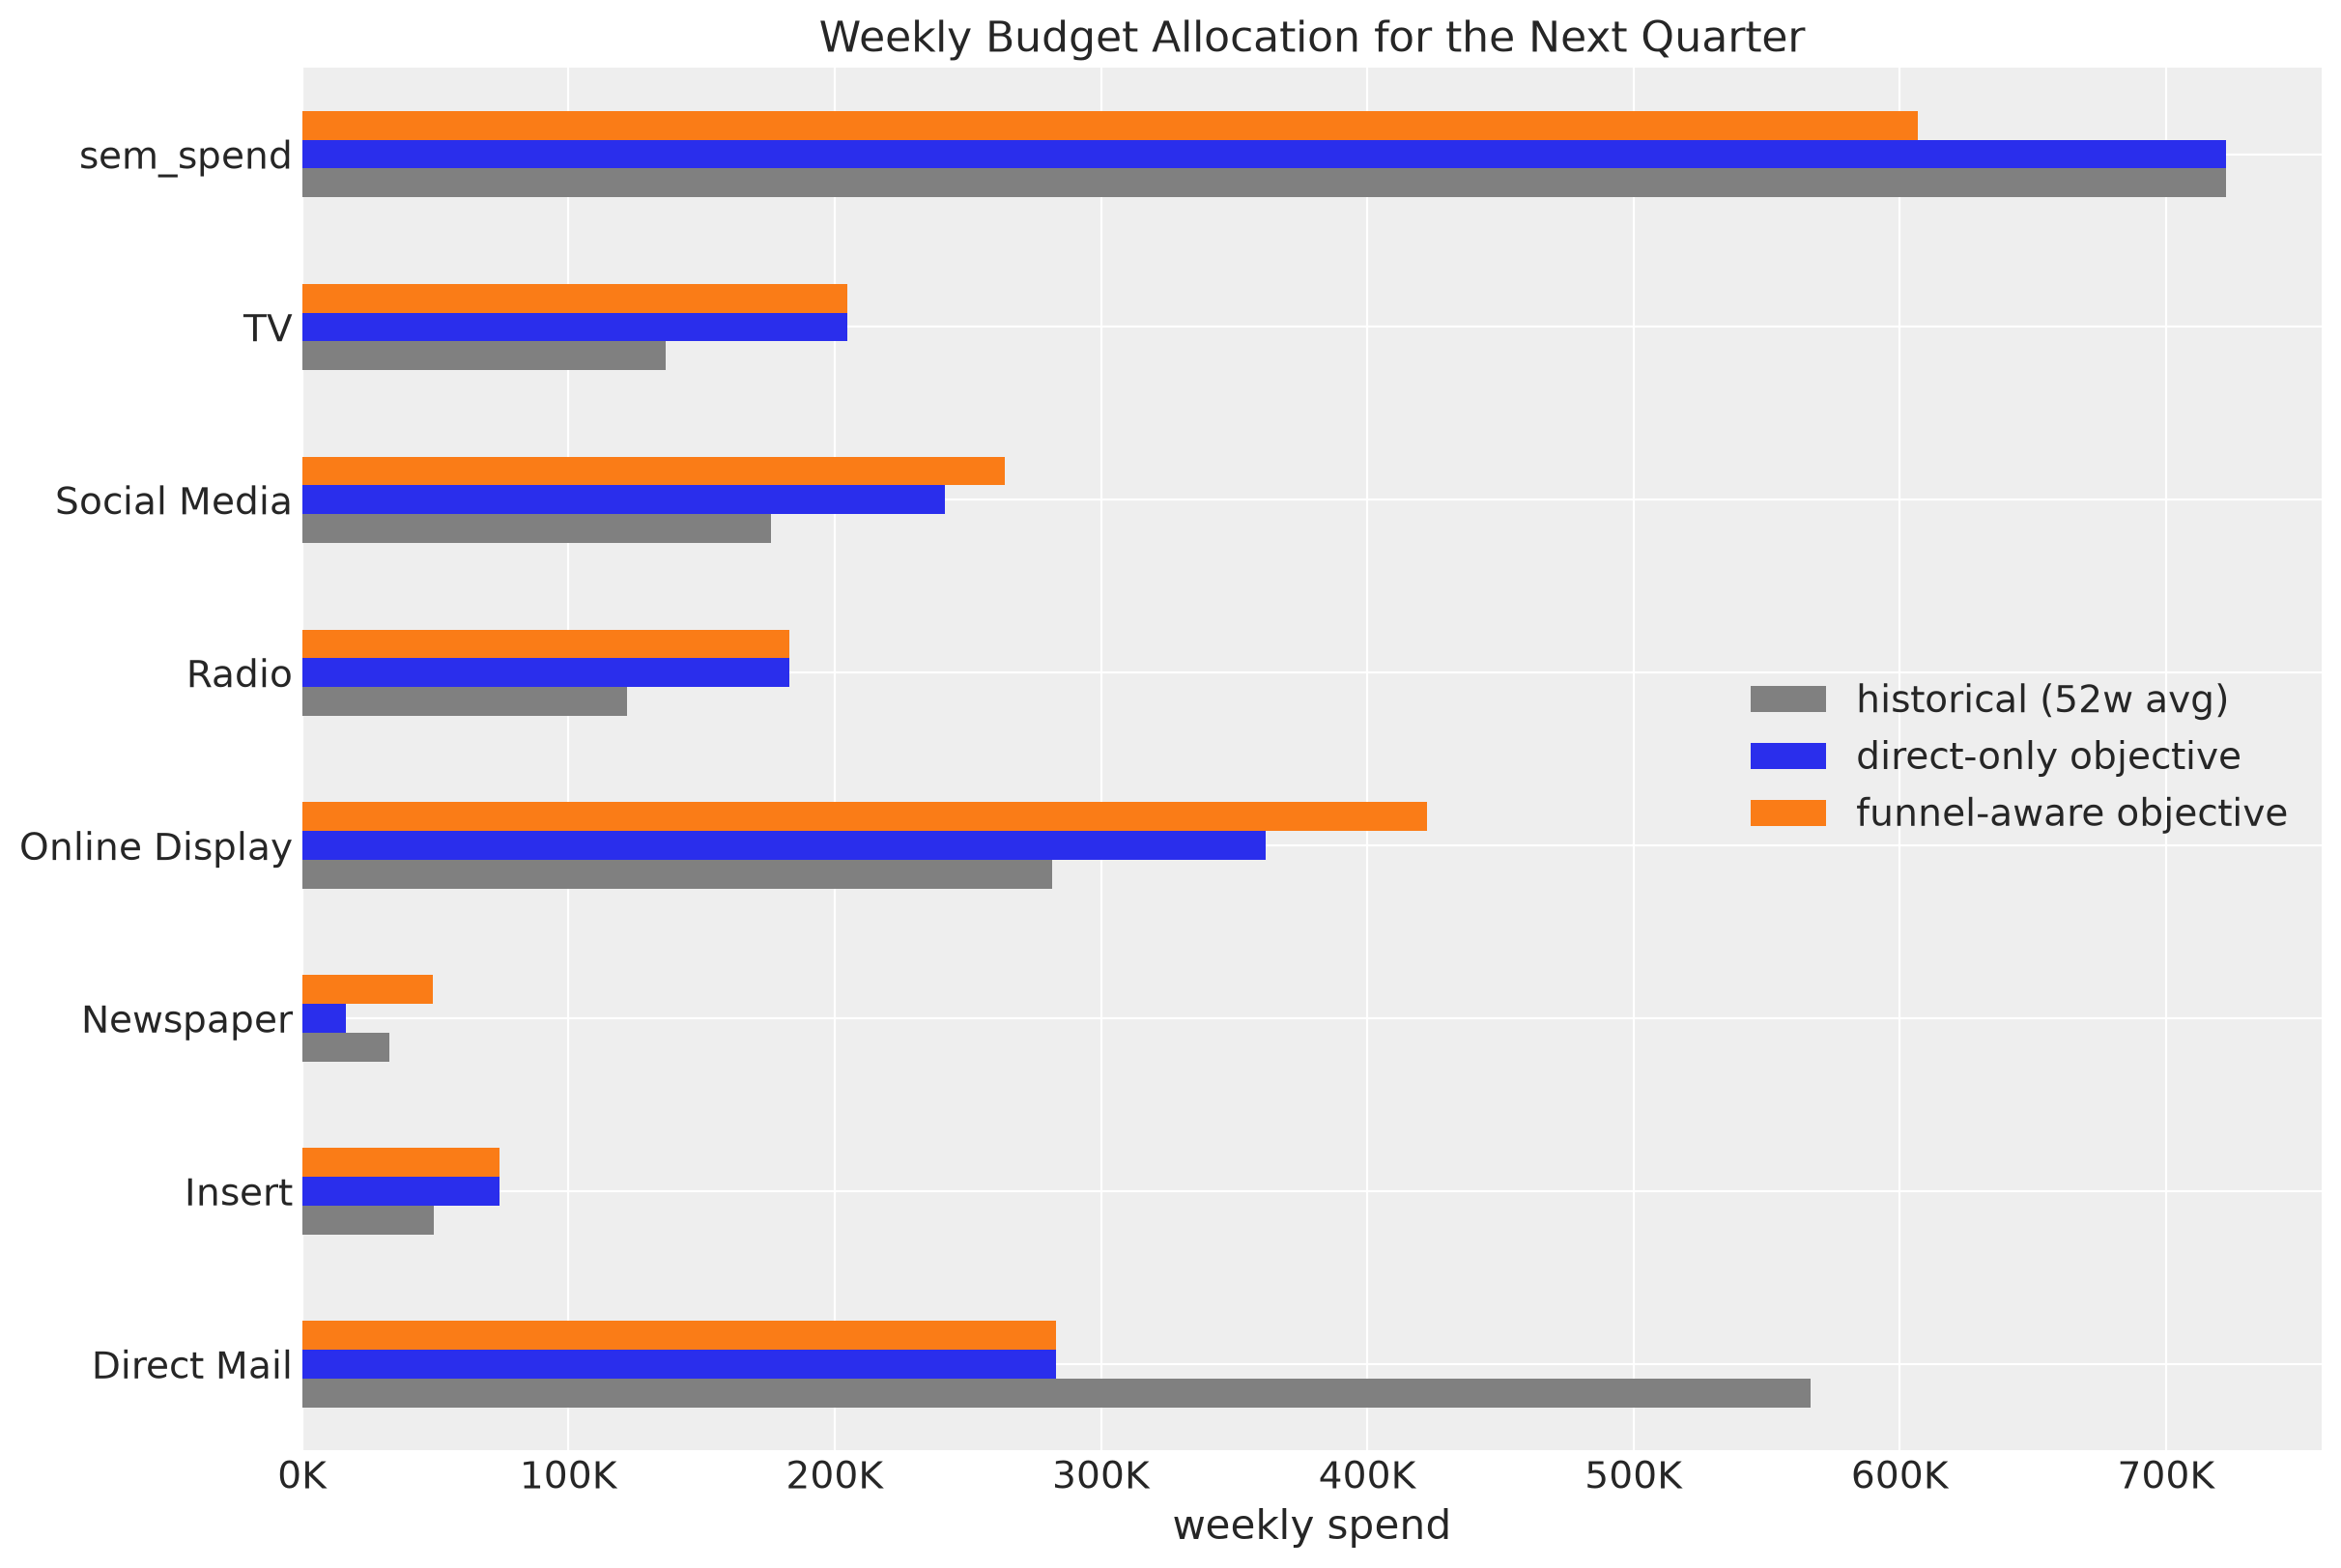

In [48]:
allocation_df = pd.DataFrame(
    {
        "historical (52w avg)": weekly_hist,
        "direct-only objective": pd.concat(
            [result_direct.budgets.to_series(), pd.Series({"sem_spend": sem_hist})]
        ),
        "funnel-aware objective": pd.concat(
            [result.budgets.to_series(), pd.Series({"sem_spend": sem_allocation})]
        ),
    }
).loc[[*channel_columns, "sem_spend"]]

fig, ax = plt.subplots(figsize=(12, 8))
allocation_df.plot.barh(color=["gray", "C0", "C1"], ax=ax)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v / 1e3:,.0f}K"))
ax.set(title="Weekly Budget Allocation for the Next Quarter", xlabel="weekly spend");

In [49]:
allocation_df.assign(
    **{
        "funnel-aware vs historical": allocation_df["funnel-aware objective"]
        / allocation_df["historical (52w avg)"]
        - 1
    }
).round(2)

,historical (52w avg),direct-only objective,funnel-aware objective,funnel-aware vs historical
Direct Mail,566468.87,283234.44,283234.44,-0.50
Insert,49378.59,74067.88,74067.88,0.50
Newspaper,32623.57,16311.79,48935.36,0.50
Online Display,281533.89,361759.14,422300.83,0.50
Radio,121968.93,182953.39,182953.39,0.50
Social Media,175997.19,241394.42,263995.79,0.50
TV,136499.97,204749.96,204749.96,0.50
sem_spend,722418.76,722418.76,606652.12,-0.16


The two objectives agree on the broad strokes and disagree exactly where the funnel is. Both cut Direct Mail to its lower bound and push Insert, Radio, and TV to their upper bounds. The disagreements: the direct-only plan cuts Newspaper to its floor while the funnel-aware plan raises it to its ceiling, because part of Newspaper's marginal value arrives through SEM and is invisible to the direct-only objective. And only the funnel-aware plan can touch SEM: it trims the SEM budget by 16% to an interior optimum of about 607K per week and reinvests that money in media, which also lifts Online Display and Social Media to their ceilings. A direct-only view treats the SEM budget as untouchable; the funnel view prices it like every other line.

### Expected Response Under the Plan

The optimizer's own graph gives the posterior response distribution under any plan, including the carryover into and out of the window. We use it to answer the planning question directly: how much more response should the funnel-aware plan produce than the direct-only plan, when both are scored by the full (funnel-aware) objective?

expected gain: 9,954,859 (94% interval [-18,532,583, 36,711,483])
P(funnel-aware plan beats direct-only plan) = 75.4%


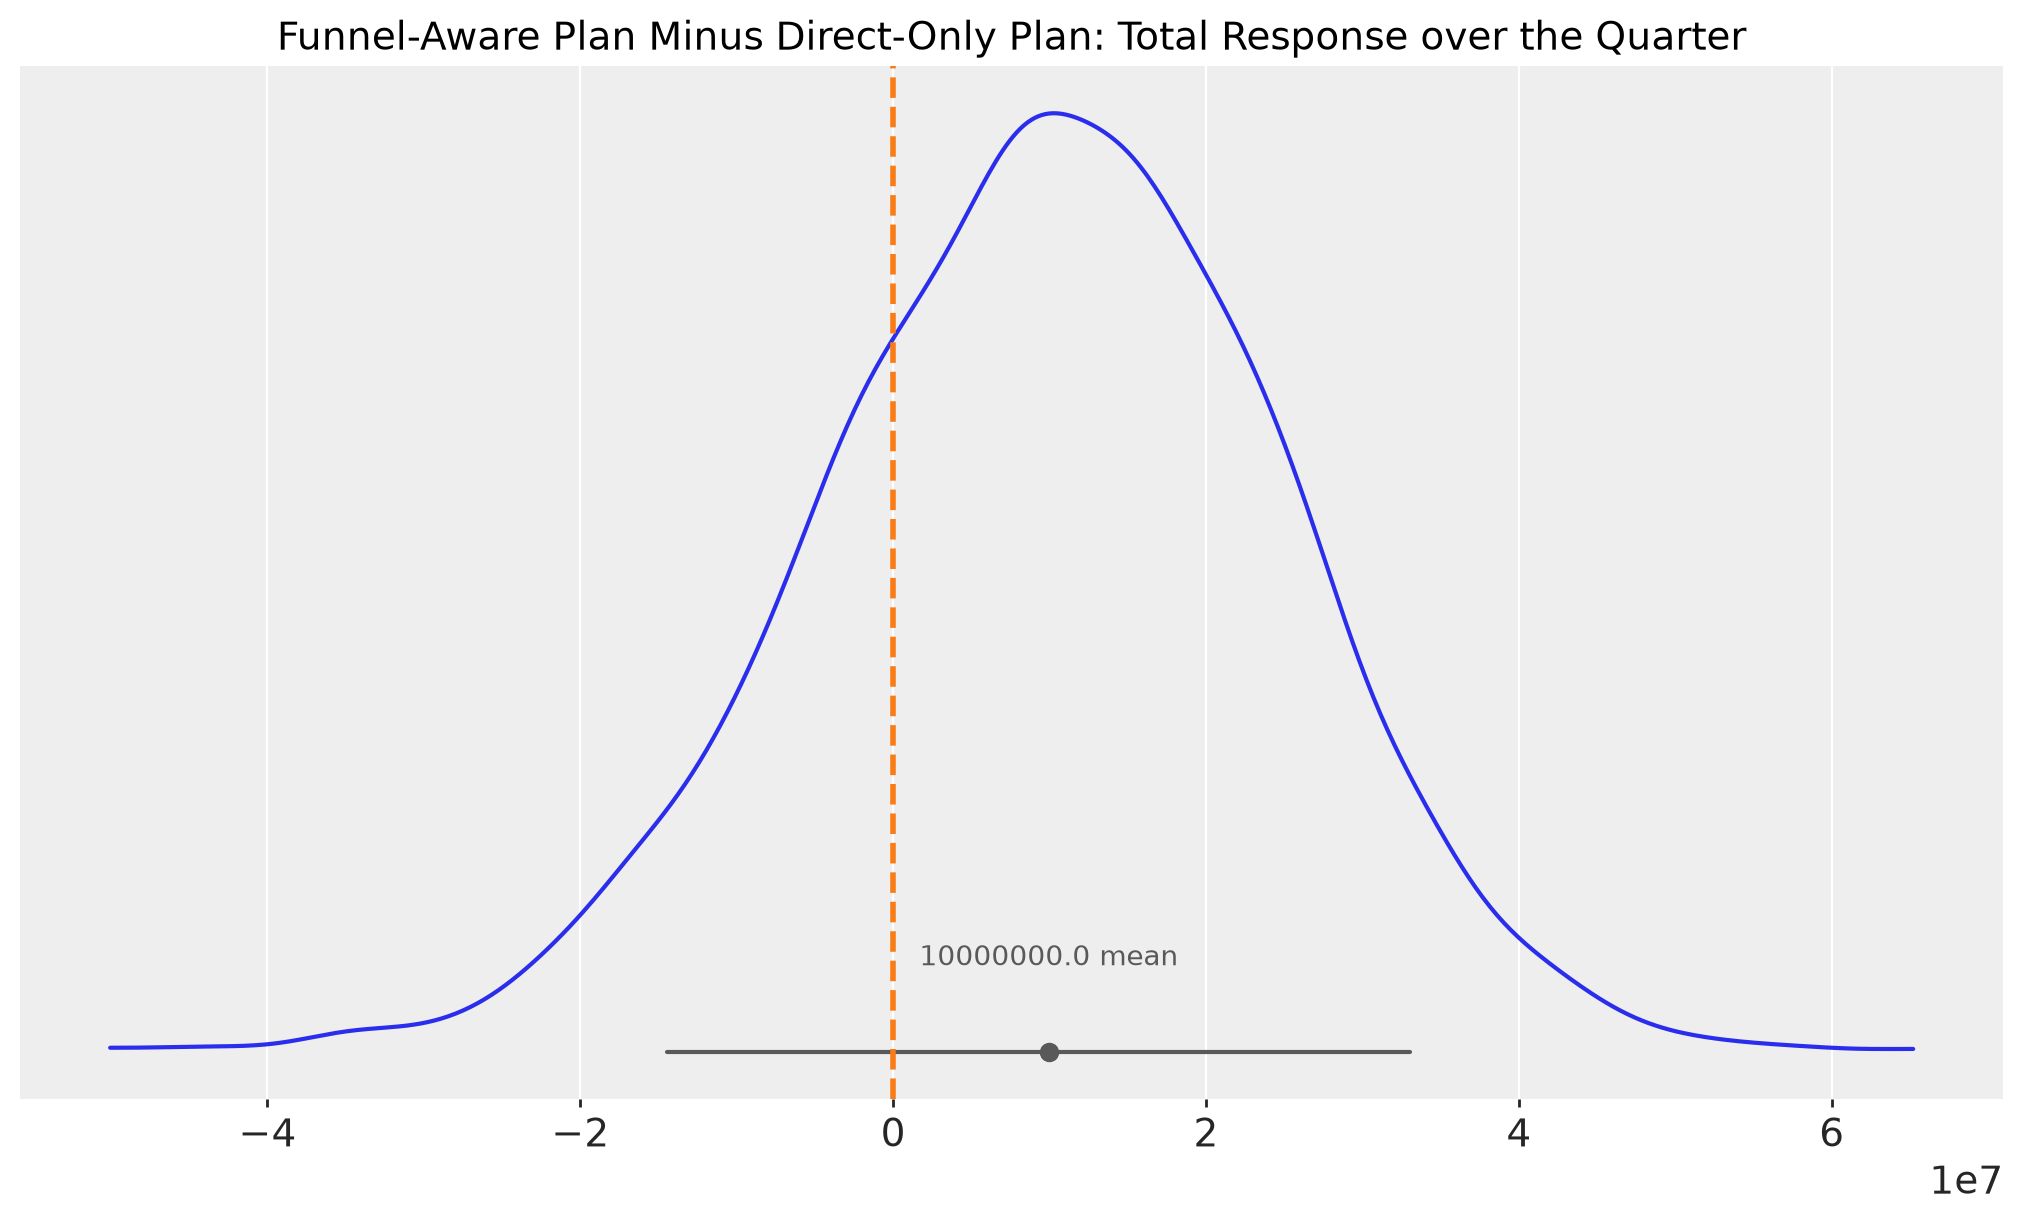

In [50]:
total_response_graph = optimizer.extract_response_distribution(
    "total_response_original_scale"
)
response_fn = pytensor.function(
    [optimizer.optimization_variables.flat],
    total_response_graph.values,
    mode=Mode(linker="cvm"),
)

x_funnel_aware = optimizer.optimization_variables.pack(
    {
        "channel_data": result.budgets,
        "sem_spend": result.spend_var_allocations["sem_spend"],
    }
)
x_direct_plan = optimizer.optimization_variables.pack(
    {"channel_data": result_direct.budgets, "sem_spend": xr.DataArray(sem_hist)}
)

response_gain = response_fn(x_funnel_aware) - response_fn(x_direct_plan)

pc = azp.plot_dist(
    xr.Dataset({"x": xr.DataArray(response_gain, dims=["sample"])}),
    sample_dims=["sample"],
    figure_kwargs={"figsize": (10, 6)},
)
fig = pc.viz["/"]["figure"].values.item()
ax = fig.axes[0]
ax.axvline(x=0, color="C1", linestyle="--", linewidth=2)
ax.set_title(
    "Funnel-Aware Plan Minus Direct-Only Plan: Total Response over the Quarter",
    fontsize=14,
)
gain_low, gain_high = np.quantile(response_gain, [0.03, 0.97])
print(
    f"expected gain: {response_gain.mean():,.0f} (94% interval [{gain_low:,.0f}, {gain_high:,.0f}])"
)
print(f"P(funnel-aware plan beats direct-only plan) = {(response_gain > 0).mean():.1%}")

The expected gain of the funnel-aware plan over the direct-only plan is about 10 million in total response over the quarter, with a 94% interval of minus 19 to plus 37 million and a 75% probability of being the better plan. Same posterior, same total budget, same guardrails: the difference is purely which response paths the objective is allowed to count.

## Expected In-Sample Uplift of the Optimal Mix

The first iteration closed by re-weighting the training spend with the optimized allocation and reading the counterfactual uplift. We repeat that exercise with one improvement. The first iteration scaled each channel by an optimal-to-historical multiplier, which entangles the answer with how spend drifted over the years. Here we re-weight in **share space**: every week keeps its observed total media pot, and that pot is redistributed across the eight lines (seven channels plus SEM) according to the optimal shares. The question becomes clean: same money, same weeks, different mix; what changes?

In [51]:
optimal_allocation = pd.concat(
    [result.budgets.to_series(), pd.Series({"sem_spend": sem_allocation})]
).loc[pot_columns]
optimal_shares = optimal_allocation / optimal_allocation.sum()

weekly_pot = X[pot_columns].sum(axis=1)
X_weighted = X.copy()
for column in pot_columns:
    X_weighted[column] = weekly_pot * optimal_shares[column]

np.testing.assert_allclose(
    X_weighted[pot_columns].sum(axis=1).to_numpy(), weekly_pot.to_numpy()
)
np.testing.assert_allclose(
    X_weighted[pot_columns].to_numpy().sum(), X[pot_columns].to_numpy().sum()
)
optimal_shares.round(3).to_frame(name="optimal share of the weekly pot")

,optimal share of the weekly pot
Direct Mail,0.136
Insert,0.035
Newspaper,0.023
Online Display,0.202
Radio,0.088
Social Media,0.127
TV,0.098
sem_spend,0.291


/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [y]


mean uplift: 23.0%
P(uplift > 0) = 99.8%


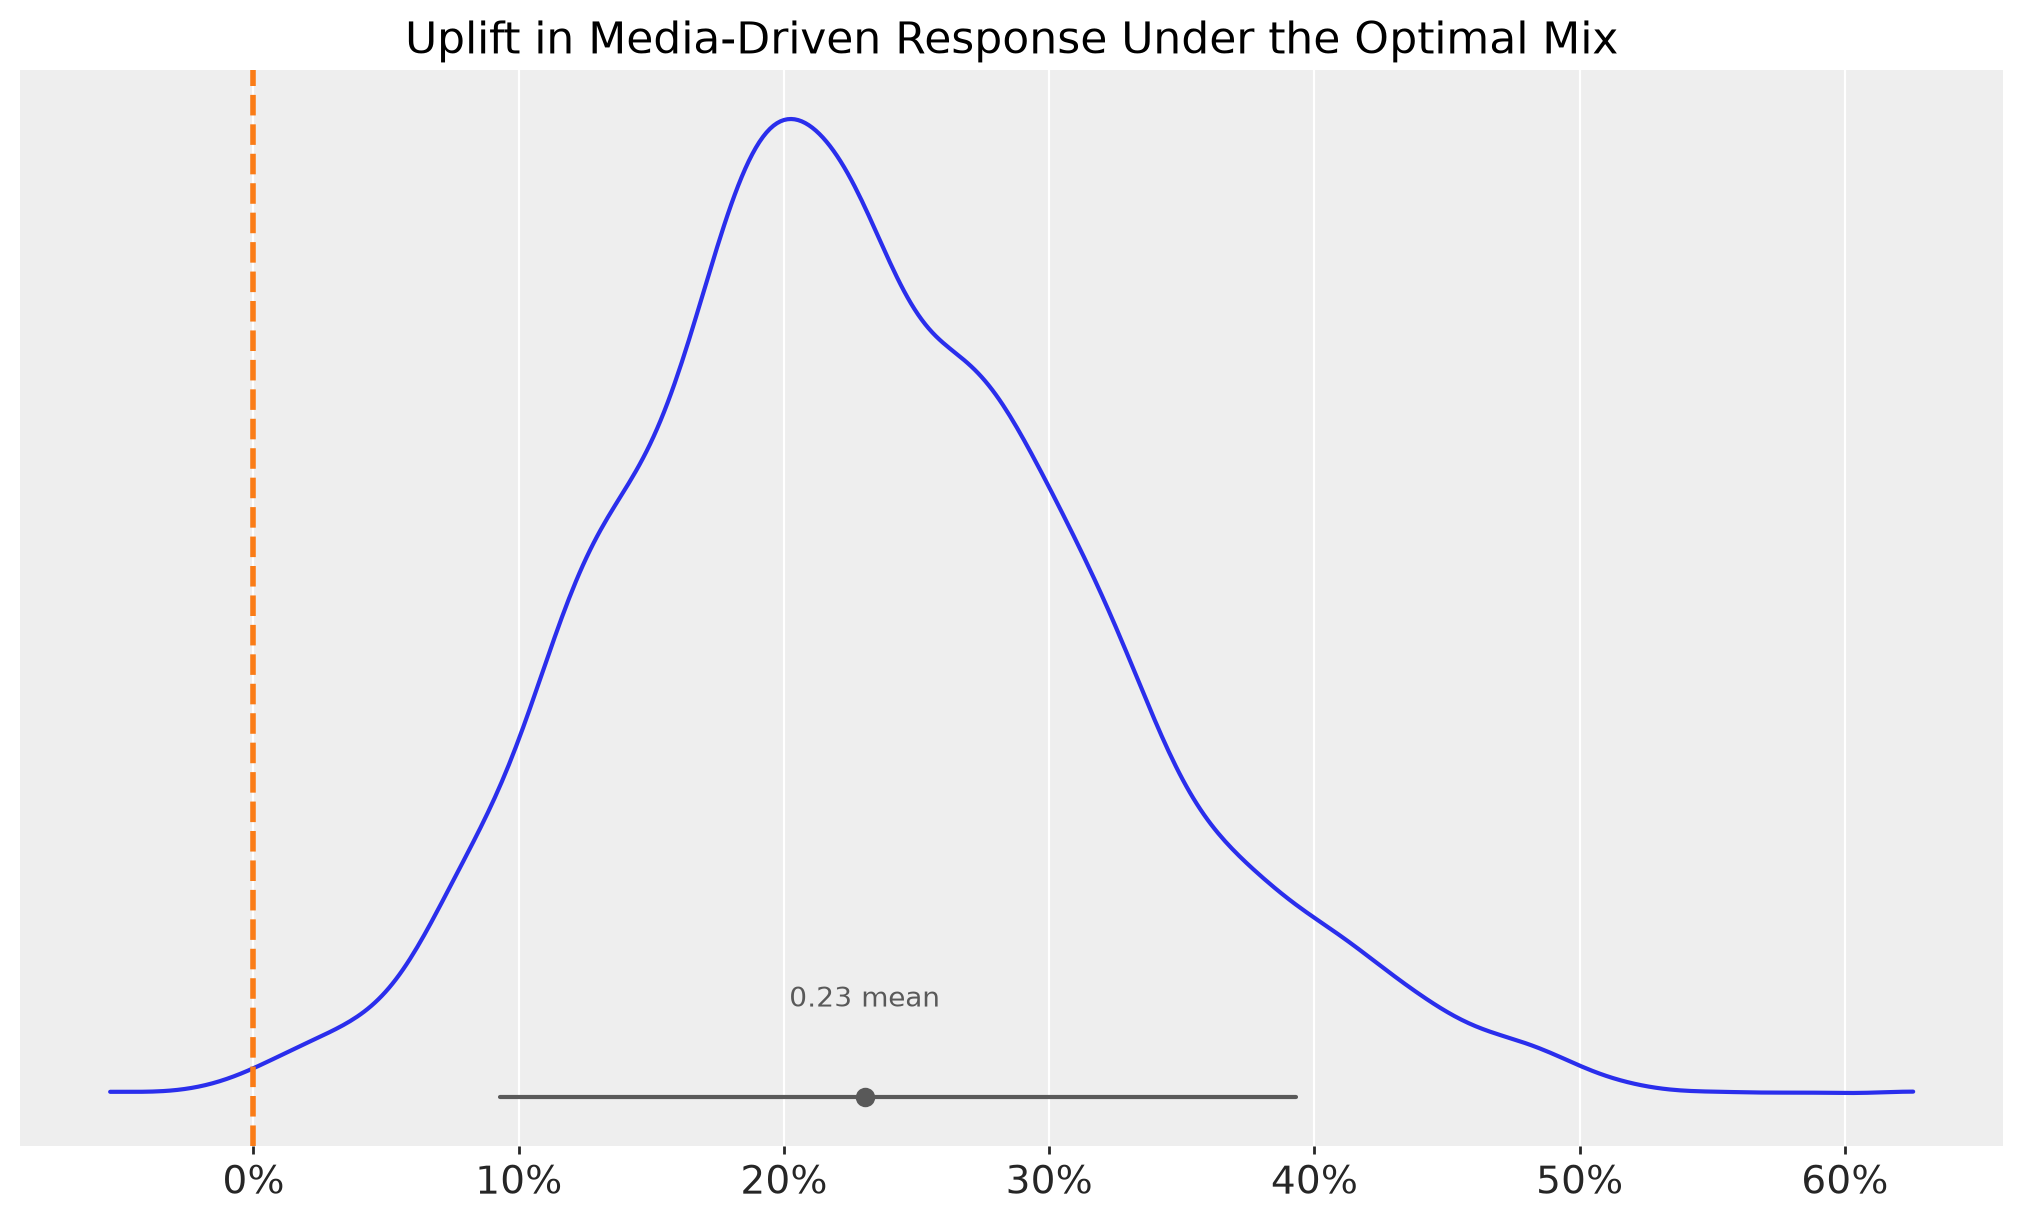

In [52]:
pp_weighted = sample_plan(X_weighted)


def media_driven_response(pp: xr.Dataset) -> xr.DataArray:
    """Total media-driven response: direct channel contributions plus the mediated path."""
    return pp["channel_contribution_original_scale"].sum(("date", "channel")) + pp[
        "funnel_effect_contribution_original_scale"
    ].sum("date")


media_uplift = media_driven_response(pp_weighted) / media_driven_response(pp_base) - 1

pc = azp.plot_dist(xr.Dataset({"x": media_uplift}), figure_kwargs={"figsize": (10, 6)})
fig = pc.viz["/"]["figure"].values.item()
ax = fig.axes[0]
ax.axvline(x=0, color="C1", linestyle="--", linewidth=2)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title("Uplift in Media-Driven Response Under the Optimal Mix", fontsize=16)
print(f"mean uplift: {float(media_uplift.mean()):.1%}")
print(f"P(uplift > 0) = {float((media_uplift > 0).mean()):.1%}")

Note the numerator: direct channel contributions **plus** the mediated contribution. The first iteration summed the channel contributions only; in a funnel model that undercounts, because part of what the upper channels earn arrives through SEM.

mean sales uplift: 9.5%


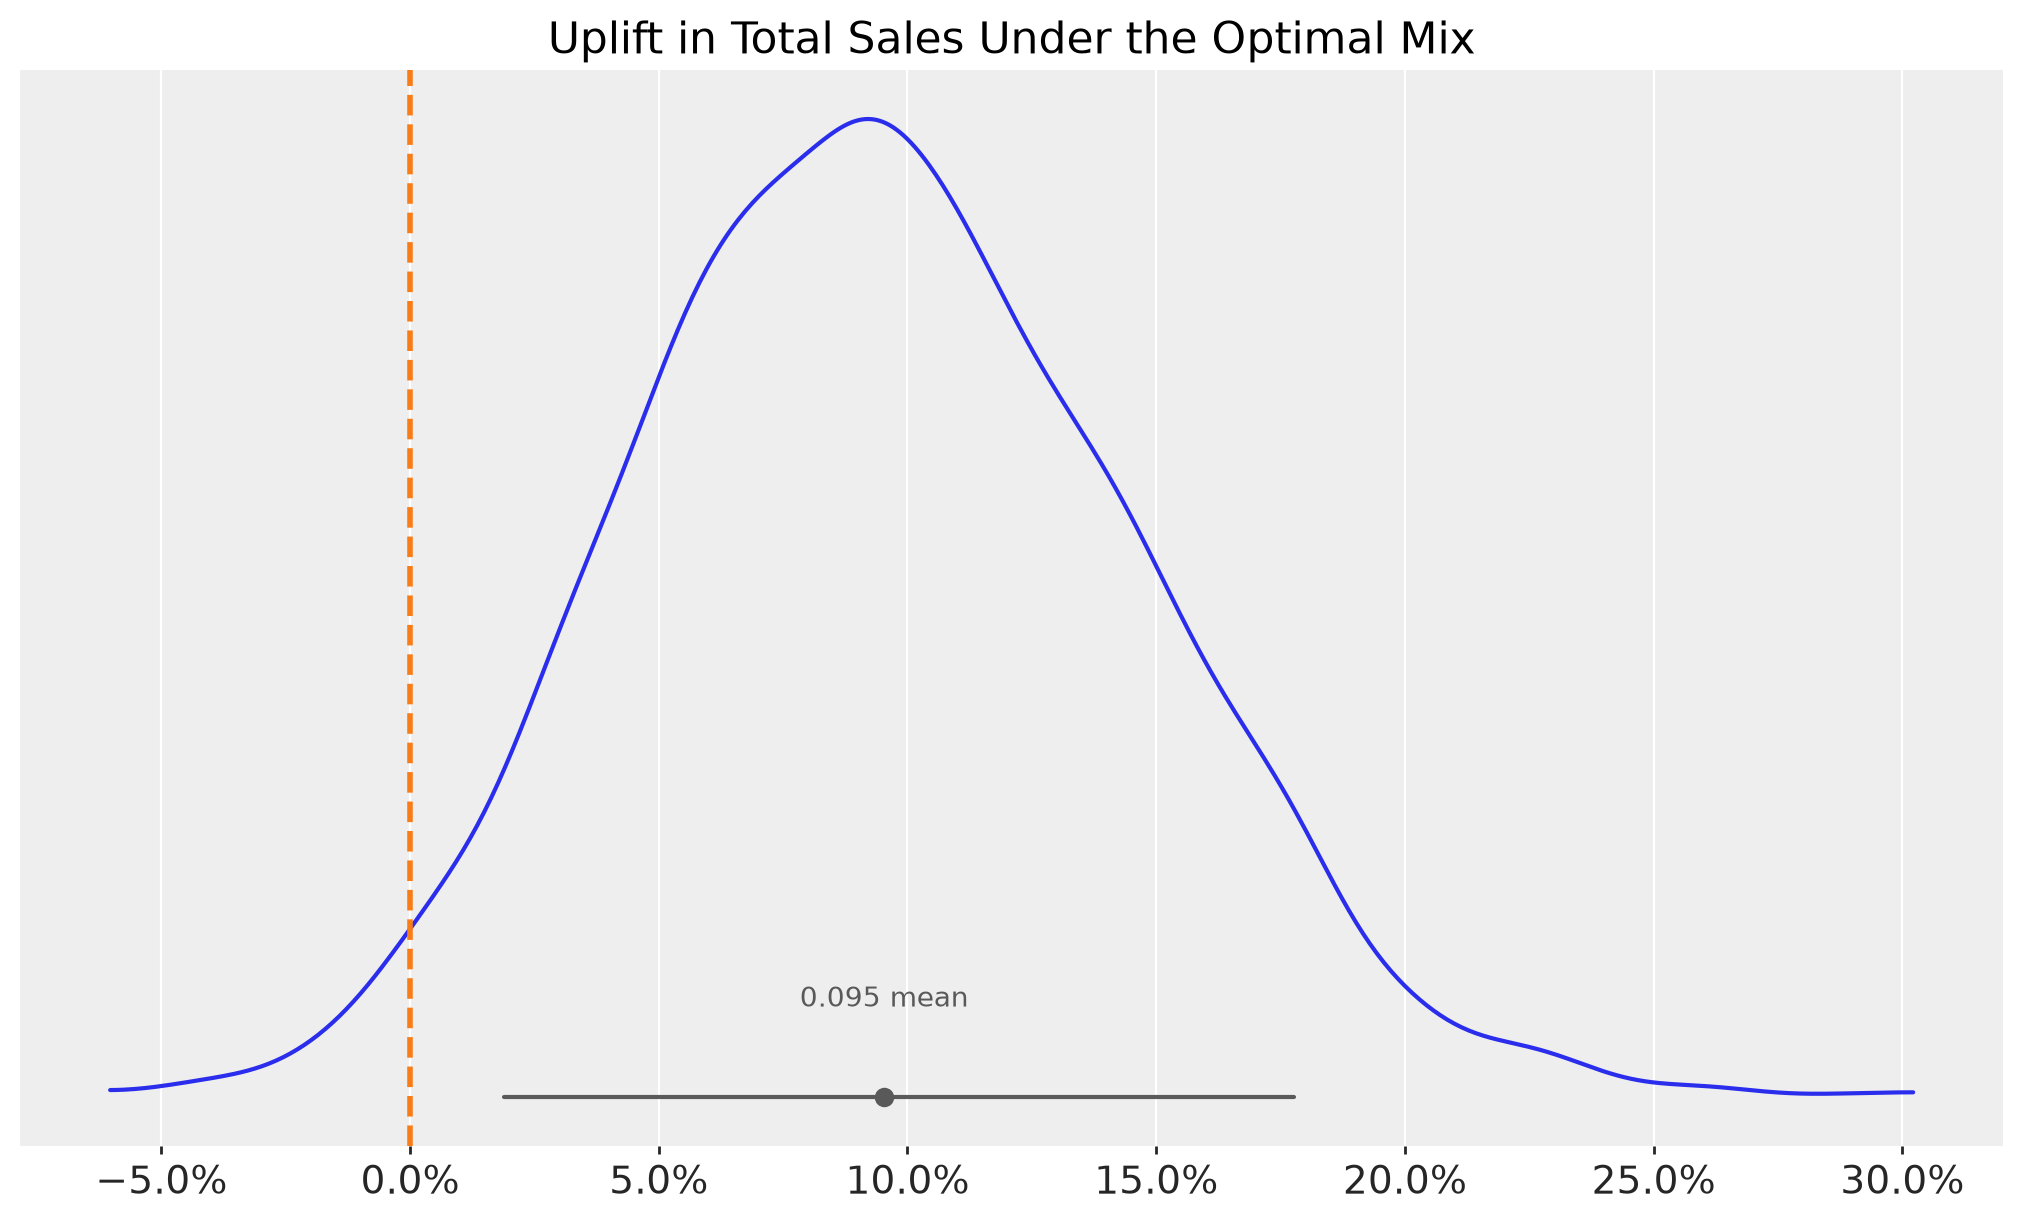

In [53]:
sales_uplift = (
    pp_weighted["y_original_scale"].sum("date")
    / pp_base["y_original_scale"].sum("date")
    - 1
)

pc = azp.plot_dist(xr.Dataset({"x": sales_uplift}), figure_kwargs={"figsize": (10, 6)})
fig = pc.viz["/"]["figure"].values.item()
ax = fig.axes[0]
ax.axvline(x=0, color="C1", linestyle="--", linewidth=2)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.set_title("Uplift in Total Sales Under the Optimal Mix", fontsize=16)
print(f"mean sales uplift: {float(sales_uplift.mean()):.1%}")

The sales-level uplift is diluted by everything media do not control: baseline, seasonality, and observation noise all sit in the denominator. The media-driven number above is the decision metric; this one shows what would be visible in the top line.

The optimal mix would have produced a 23% higher media-driven response on the same historical spend, with a 99.8% probability of a positive uplift. At the sales line the expected uplift is 9.5%, diluted by the baseline and seasonality that media do not control. The first iteration reported 26% and 10% on a different channel set and a different re-weighting recipe, so treat the agreement in magnitude as reassuring, not as a like-for-like comparison.

:::{warning}
**Critical Assessment:** this is an in-sample counterfactual, not a forecast. The optimal shares push some channels beyond spend levels the model has seen, where the saturation curves are extrapolations. The SEM impressions series stays at its observed values because it is an outcome of the plan, not an input. And the model does not net out the extra SEM spend the new demand would induce; pricing that feedback is a candidate for the next iteration.
:::

## Conclusion

**What this iteration changed.** SEM entered the model as a demand harvester rather than a flat channel; two experiments calibrated the ROAS of Online Display and Direct Mail; four quarterly cross-validation folds replaced the single split; the final model used all 209 weeks; and the next quarter's budget was planned with a funnel-aware objective that co-optimizes the SEM budget.

**Key findings.** SEM budget moves the mediator: `funnel_lambda` concentrates around 0.68, clearly away from zero, and is stable across all four validation folds. The mediated share of the upper funnel channels is positive but imprecise (point estimates of 6% to 25% with intervals reaching zero). Calibration pinned the two decision-critical ROAS values, Online Display at 27.8 (94% interval 20.3 to 35.6) and Direct Mail at 4.8 (2.2 to 7.4), while uncalibrated channels still span order-of-magnitude ranges. The funnel-aware quarter plan cuts Direct Mail by 50%, raises every other media channel to its guardrail, trims SEM by 16%, and beats the direct-only plan with 75% probability (an expected gain of about 10 million in response over the quarter). Re-weighting the whole history to the optimal mix would have lifted the media-driven response by 23% (99.8% probability positive) and sales by 9.5%.

**Model limitations.** One shared demand pool for three upper channels; a single measurement series (SEM impressions) anchors the mediator; the calibration constrains direct paths only; the in-sample uplift extrapolates saturation curves beyond observed spend; comparisons with the first iteration are not like-for-like because the decomposition changed.

**Recommendations.** Fund the funnel-aware plan for one quarter with the 50% guardrails in place; log realized SEM impressions against the model's implied mediator as a live check the search team can own; hold out a region for the Direct Mail reduction if operations allow it.

## Next Steps

1. Price the induced SEM spend: demand created by upper funnel media pulls SEM spend with it; report ROAS per incremental dollar including that feedback, as {ref}`mmm_funnel_mueffect_advanced` does.
2. Replace the imagined experiment ranges with the real studies they stand in for, and extend the calibration to a saturation-curve lift test for one upper funnel channel (see {ref}`mmm_lift_test`).
3. After the quarter, score the realized 13 weeks against the plan's response distribution (CRPS) and roll the cross-validation forward one fold.
4. Structural extensions: a time-varying demand baseline, separate branded and non-branded demand pools, and geo-level disaggregation if regional data become available.
5. Operationalize: move the model specification to a YAML registry (see {ref}`mmm_funnel_from_yml`) and track iterations with MLflow.

In [54]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor,nutpie

Last updated: Mon, 31 Aug 2026

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.16.1

pymc_marketing: 1.1.0
pytensor      : 3.2.4
nutpie        : 0.16.11

arviz         : 1.2.0
arviz_plots   : 1.2.0
graphviz      : 0.21
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 2.3.3
pydantic      : 2.13.4
pymc          : 6.2.0
pymc_extras   : 0.14.0
pymc_marketing: 1.1.0
pytensor      : 3.2.4
seaborn       : 0.13.2
xarray        : 2026.4.0

Watermark: 2.6.0

